# Fingerprint-based set-vs-set similarity for compound matrices (Molecular palmprints)

*Reproducible computational workflow accompanying the manuscript:*

> **Molecular palmprints: extending molecular fingerprint-based similarity to database similarity**
>
> Corresponding author: [Edgar López-López] · [edgar.lopez@uu.se ]
> [DOI: XXXX]

**License:** [e.g. MIT for the code / CC-BY 4.0 for the text] — see the repository `LICENSE` file.

Compatible with Jupyter Lab, Jupyter Notebook, VS Code, and Google Colab.

---

## How to run

1. Open this `.ipynb` file in Jupyter Lab / Notebook (locally) or upload it to Colab.
2. Choose *Run → Run All Cells* (Jupyter) or *Runtime → Run all* (Colab).
3. The setup cell checks the dependencies and installs anything missing into an
   isolated, per-session directory; no other manual configuration is required.

To install the dependencies manually before launching Jupyter:

```bash
pip install rdkit numpy pandas matplotlib seaborn scikit-learn umap-learn "networkx>=3.0" scipy
```

## What this notebook does

Given several pharmacology-style compound tables, the workflow:

1. Builds three illustrative datasets of SMILES — with fabricated pIC50 activities for the scaffold series (Dataset 1) only — each representing a
   different real-world situation (a scaffold series, plant-extract fractions, and
   arbitrary mixtures).
2. Generates two complementary molecular fingerprints — **MACCS keys** (167-bit
   structural keys) and **ECFP4** (Morgan radius 2, 2048-bit circular fingerprint).
3. Groups the compounds into *matrices* (rows = molecules, columns = fingerprint
   bits), using a grouping criterion appropriate to each dataset.
4. Computes the *similarity between two whole groups of compounds* — not merely
   pairwise. Because the matrices may have **different numbers of rows**, this is a
   non-trivial problem; we define **five complementary metrics**, justify each one
   mathematically, and discuss when each is appropriate.
5. Performs an exploratory data analysis of each dataset individually — activity
   distributions, diversity heatmaps, hierarchical clustering, scaffold / procedence
   breakdowns, intra- vs inter-group similarity diagnostics, and (for the
   activity-bearing Dataset 1) pIC50 / structure associations.
6. Embeds all compounds into a 2-D **chemical-space map** (UMAP with the Jaccard
   metric — choice justified in §13) and overlays a multi-panel **chemical-space
   network** whose edges are coloured by pairwise Tanimoto on a white-to-black scale.
7. Packages the complete pipeline into a single **`analyze_dataset(df)`** function
   that accepts any user-supplied SMILES dataframe and reproduces all of the above.

## Reproducibility notes

* Runs end-to-end on a clean Python 3.10+ environment.
* All random sources are seeded (`RANDOM_SEED = 42`).
* Key computations are checked by dedicated unit-test cells; if any check fails, the
  notebook stops with a clear error.
* All SMILES are canonicalised with RDKit, so the analysis is invariant to how each
  input structure was written.

## Figures

All figures are styled for publication: black text and axes on a white background,
and a 300-dpi raster export alongside a vector PDF. The exact figure files used in
the manuscript and its supplement are produced by the companion script
`export_publication_figures.py`; the figure naming and the main-text vs supplementary
split are documented in the accompanying figure list.


## 0. Environment setup

The notebook needs RDKit, NumPy, pandas, matplotlib, seaborn,
scikit-learn, umap-learn, networkx, and scipy.  The cell below
checks each dependency, attempts a normal import, and — only when
that fails or returns a too-old version — installs a fresh copy
into a **per-notebook sandbox directory** that is prepended to
`sys.path`.

### Why sandbox instead of `pip install --upgrade`?

Scientific JupyterHub images often ship with packages that pin
old versions of common libraries — for example `tmap` and `mordred`
both pin `networkx==2.x`.  A global `pip install --upgrade networkx`
would silently break those packages for *other* notebooks the user
has been running.

The sandbox approach installs the upgraded library only for this
notebook's process, leaving the user's broader environment intact.
The sandbox is a temporary directory under `/tmp`; once you close
Jupyter, all sandboxed installs disappear.

### What if my system blocks pip?

Set `OFFLINE = True` at the top of the setup cell and pre-install
the libraries manually before launching Jupyter:

```bash
pip install --user rdkit matplotlib seaborn scikit-learn umap-learn 'networkx>=3.0' scipy
```

### Note about molecule drawing on Linux

`rdkit.Chem.Draw` depends on a few X11 / Cairo *system libraries*
that `pip` cannot install for you.  If you see an error like

```
ImportError: libXrender.so.1: cannot open shared object file
```

install the missing libs once (Debian / Ubuntu):

```bash
sudo apt-get install -y libxrender1 libxext6 libsm6 libxcb1
```

The notebook works **without** these libraries — the drawing cell at
the end will simply skip itself with a clear message, and every
fingerprint / similarity calculation runs normally.

In [1]:
# === Auto-install dependencies if missing, broken, or too old ===
# Works in Jupyter Lab/Notebook, VS Code, and Colab.  In offline
# environments, install everything beforehand with
#   `pip install rdkit matplotlib seaborn scikit-learn umap-learn networkx scipy`.
#
# Notes:
# * Some scientific JupyterHub images ship with old NetworkX (2.x) and
#   refuse to upgrade because other packages (tmap, mordred) pin it.
#   We deal with that by installing fresh copies into a temp directory
#   that we PREPEND to sys.path -- so the rest of the user's stack
#   keeps the versions it expects.
# * If your system needs an offline / locked-down install path, set
#   `OFFLINE = True` below and `pip` will not be called.
import importlib, subprocess, sys, os, tempfile, shutil

OFFLINE = False                                     # set True to skip ALL pip calls
_NB_DEP_PREFIX = None                               # lazily created temp dir

def _ensure_sandbox():
    """Create a per-notebook temp directory and prepend it to sys.path."""
    global _NB_DEP_PREFIX
    if _NB_DEP_PREFIX is None:
        _NB_DEP_PREFIX = tempfile.mkdtemp(prefix="nb_deps_")
        sys.path.insert(0, _NB_DEP_PREFIX)
    return _NB_DEP_PREFIX

def _pip_install_into_sandbox(spec):
    """Install *spec* into the per-notebook sandbox so we don't disturb
    the global / user site-packages.  Uses --no-deps to avoid pulling
    in transitive packages we did not ask for."""
    target = _ensure_sandbox()
    print(f"Installing {spec} into isolated sandbox ...")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "--quiet",
        "--target", target, "--upgrade", spec
    ])

def _purge(name):
    """Forget any cached copy of *name* so the next import re-loads it."""
    for k in list(sys.modules):
        if k == name or k.startswith(name + "."):
            del sys.modules[k]

def _version_lt(a, b):
    """True iff version string *a* is older than version string *b*."""
    try:
        from packaging.version import Version
        return Version(a) < Version(b)
    except Exception:
        def _t(s):
            parts = []
            for chunk in str(s).split("."):
                d = ""
                for ch in chunk:
                    if ch.isdigit(): d += ch
                    else: break
                parts.append(int(d) if d else 0)
            return tuple(parts)
        return _t(a) < _t(b)

def _ensure(pkg, import_name=None, min_version=None):
    """Make sure *pkg* is installed AND actually importable.

    Strategy:
      1. Try to import.
      2. If import fails OR version is too old, install a fresh copy
         into a per-notebook sandbox (which is prepended to sys.path),
         purge sys.modules, and retry.
    """
    name = import_name or pkg.replace("-", "_")
    spec_str = f"{pkg}>={min_version}" if min_version else pkg

    # 1) Try the import as-is.
    try:
        mod = importlib.import_module(name)
        version_ok = (min_version is None or
                      not _version_lt(getattr(mod, "__version__", "0"),
                                       min_version))
        if version_ok:
            return mod
    except Exception:
        mod = None

    if OFFLINE:
        raise RuntimeError(
            f"{pkg!r} is missing / broken / outdated and OFFLINE=True. "
            f"Install it manually: pip install {spec_str!r}"
        )

    # 2) Install fresh into the sandbox, purge, retry.
    _pip_install_into_sandbox(spec_str)
    _purge(name)
    importlib.invalidate_caches()
    try:
        return importlib.import_module(name)
    except Exception as e:
        raise RuntimeError(
            f"Could not load {pkg!r} after installing it into "
            f"{_NB_DEP_PREFIX!r}.  Last import error: {e}"
        ) from e

# --- Core: fingerprinting + plotting ---
_ensure("rdkit")
_ensure("matplotlib")

# --- Section 12+: extended data-science analysis ---
# Pin minimum versions so we avoid known-broken legacy releases.
_ensure("seaborn",      min_version="0.13")
_ensure("scikit-learn", import_name="sklearn", min_version="1.0")
# umap-learn optionally loads deep-learning backends (ParametricUMAP)
# at import time. None of them are used in this notebook, and a broken
# torch/torchvision or tensorflow install in the environment can make
# that optional import crash `import umap` entirely. Hide those backends
# during the import (forcing a clean ImportError that umap catches), so
# umap always falls back to its core implementation, then restore them.
def _import_umap_safely():
    _hidden = {}
    for _m in ("torchvision", "tensorflow"):
        _hidden[_m] = sys.modules.get(_m, "absent")
        sys.modules[_m] = None
    try:
        return _ensure("umap-learn", import_name="umap", min_version="0.5")
    finally:
        for _m, _v in _hidden.items():
            if _v == "absent":
                sys.modules.pop(_m, None)
            else:
                sys.modules[_m] = _v

_import_umap_safely()
_ensure("networkx",                            min_version="3.0")  # 2.x broken on py>=3.10
_ensure("scipy",                               min_version="1.10")

print("Dependency check OK")


Dependency check OK


In [2]:
# === Imports and global configuration ===
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from IPython.display import display          # explicit import for non-IPython safety

from rdkit import Chem, RDLogger, DataStructs
from rdkit.Chem import AllChem, MACCSkeys
from rdkit.Chem.Scaffolds import MurckoScaffold

# Render figures inline in Jupyter / Lab.
%matplotlib inline

# Silence RDKit's verbose parsing warnings; invalid SMILES are still raised below.
RDLogger.DisableLog("rdApp.*")

# Fix all random sources for full reproducibility.
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ---------------------------------------------------------------
# Publication figure style.
# Black text and axes on a white background, with a 300-dpi raster
# export.  Defined as a function and called again after any seaborn
# `set_theme` (which would otherwise reset text colours to grey), so
# every figure in the notebook keeps pure-black lettering.
# ---------------------------------------------------------------
def apply_publication_style():
    sns.set_theme(style="white", context="notebook")
    mpl.rcParams.update({
        "figure.dpi":        110,     # inline preview resolution
        "savefig.dpi":       300,     # raster export resolution (>= 300 dpi)
        "savefig.bbox":      "tight",
        "savefig.pad_inches": 0.08,
        "figure.facecolor":  "white",
        "axes.facecolor":    "white",
        "savefig.facecolor": "white",
        "savefig.edgecolor": "white",
        "text.color":        "black",
        "axes.labelcolor":   "black",
        "axes.titlecolor":   "black",
        "axes.edgecolor":    "black",
        "xtick.color":       "black",
        "ytick.color":       "black",
        "xtick.labelcolor":  "black",
        "ytick.labelcolor":  "black",
        "axes.titleweight":  "bold",
        "figure.titleweight": "bold",
        "font.size":         12,
        "axes.titlesize":    12,
        "axes.labelsize":    12,
        "xtick.labelsize":   11,
        "ytick.labelsize":   11,
        "legend.fontsize":   11,
        "figure.titlesize":  14,
        "axes.grid":         False,   # reviewer: no background grid lines
        "pdf.fonttype":      42,       # keep PDF text selectable / editable
        "ps.fonttype":       42,
        "svg.fonttype":      "none",
    })

apply_publication_style()

# ---------------------------------------------------------------
# Automatic high-resolution figure export.
# A folder is created automatically in the current working directory
# (where the notebook is being run) and EVERY matplotlib figure shown
# with plt.show() is written there at high resolution (300-dpi PNG +
# vector PDF).  The RDKit structure panels save themselves as SVG/PNG
# into the same folder.  Change FIG_DIR / FIG_DPI / FIG_FORMATS below
# to customise the location, resolution or output formats.
# ---------------------------------------------------------------
from pathlib import Path as _Path
import re as _re

FIG_DIR = _Path.cwd() / "figures"          # auto-created next to the notebook
FIG_DIR.mkdir(parents=True, exist_ok=True)
FIG_DPI = 300                              # raster export resolution (>= 300 dpi)
FIG_FORMATS = ("png", "pdf")               # PNG (raster) + PDF (vector); edit as needed
_FIG_EXPORT_COUNTER = {"n": 0}

def _fig_slug(text, fallback="figura"):
    text = (text or "").strip()
    text = _re.sub(r"\s+", "_", text)
    text = _re.sub(r"[^0-9A-Za-z_\-]", "", text)
    return text[:80].strip("_") or fallback

def _fig_title(fig):
    """Best-effort human-readable title for naming the exported file."""
    try:
        t = fig.get_suptitle()             # matplotlib >= 3.8
        if t:
            return t
    except Exception:
        pass
    sup = getattr(fig, "_suptitle", None)
    if sup is not None and sup.get_text():
        return sup.get_text()
    for ax in fig.axes:
        if ax.get_title():
            return ax.get_title()
    return ""

def export_figure(fig, name=None):
    """Save *fig* into FIG_DIR in every FIG_FORMATS at high resolution."""
    _FIG_EXPORT_COUNTER["n"] += 1
    stem = f"{_FIG_EXPORT_COUNTER['n']:02d}_{_fig_slug(name or _fig_title(fig))}"
    for ext in FIG_FORMATS:
        try:
            fig.savefig(FIG_DIR / f"{stem}.{ext}", dpi=FIG_DPI, bbox_inches="tight")
        except Exception as _err:
            print(f"[export] could not save {stem}.{ext}: {_err}")
    fig._hr_exported = True
    return stem

# Patch plt.show so every open figure is exported in high resolution
# *before* it is displayed.  Figures already saved by a cell (flagged
# with fig._hr_exported) are skipped to avoid duplicates.
if not getattr(plt, "_hr_export_patched", False):
    _orig_plt_show = plt.show
    def _show_and_export(*args, **kwargs):
        for _num in plt.get_fignums():
            _f = plt.figure(_num)
            if not getattr(_f, "_hr_exported", False):
                export_figure(_f)
        return _orig_plt_show(*args, **kwargs)
    plt.show = _show_and_export
    plt._hr_export_patched = True

print("High-resolution figures will be exported to:", FIG_DIR.resolve())

# ---------------------------------------------------------------
# Optional molecule drawing.
# `rdkit.Chem.Draw` pulls in Cairo / libXrender at import time on
# Linux.  If those system libraries are missing we still want the rest
# of the notebook (fingerprints, similarities, plots) to run, so Draw
# is imported lazily and we remember whether it succeeded.
# ---------------------------------------------------------------
_DRAW_OK, _DRAW_ERROR = False, None
try:
    from rdkit.Chem import Draw as _Draw           # noqa: F401
    _DRAW_OK = True
except Exception as _e:                            # ImportError, OSError, ...
    _DRAW_ERROR, _Draw = _e, None

print("RDKit  version :", Chem.rdBase.rdkitVersion)
print("pandas version :", pd.__version__)
print("NumPy  version :", np.__version__)
print("Draw support   :",
      "available" if _DRAW_OK else f"unavailable ({_DRAW_ERROR})")


High-resolution figures will be exported to: /home/jovyan/Palmprint/figures
RDKit  version : 2026.03.2
pandas version : 2.3.0
NumPy  version : 1.26.4
Draw support   : unavailable (libXrender.so.1: cannot open shared object file: No such file or directory)


## 1. Construction of the three hypothetical datasets

Only **Dataset 1** carries an activity column.  Its pIC50 values are
**fabricated** and have no biological meaning - they are present only so
that the scaffold series looks like a real SAR table.  **Datasets 2 and 3
carry no pIC50 / activity column at all**: they describe *composition*
(which compound came from which fraction or mixture), so every analysis of
those two datasets is purely structural.

### Dataset 1 - Scaffold series

Nineteen compounds organised into **five Bemis-Murcko scaffolds**
(indole, quinoline, benzimidazole, chromone, uracil).  Each scaffold
has 3-5 substitution analogues.  This dataset will let us check that
every analogue of the same scaffold collapses to the *same* Murcko
scaffold SMILES, and that intra-scaffold similarity is high.

In [3]:
# === Dataset 1 - five scaffold series ===
# Each tuple is (compound_id, SMILES, pIC50).  IDs are prefixed by the
# scaffold acronym purely for human readability - the analysis derives
# scaffolds from structure, not from the ID.
dataset1_rows = [
    # Indole series ------------------------------------------------
    ("IND-01", "c1ccc2[nH]ccc2c1",         6.10),
    ("IND-02", "Cc1ccc2[nH]ccc2c1",        6.45),
    ("IND-03", "Clc1ccc2[nH]ccc2c1",       7.02),
    ("IND-04", "COc1ccc2[nH]ccc2c1",       6.80),
    ("IND-05", "c1ccc2[nH]cc(C(=O)O)c2c1", 5.55),
    # Quinoline series --------------------------------------------
    ("QUI-01", "c1ccc2ncccc2c1",           5.80),
    ("QUI-02", "Cc1ccc2ncccc2c1",          6.15),
    ("QUI-03", "Clc1ccc2ncccc2c1",         6.70),
    ("QUI-04", "COc1ccc2ncccc2c1",         6.55),
    # Benzimidazole series ----------------------------------------
    ("BZI-01", "c1ccc2[nH]cnc2c1",         5.20),
    ("BZI-02", "Cc1ccc2[nH]cnc2c1",        5.95),
    ("BZI-03", "Clc1ccc2[nH]cnc2c1",       6.40),
    ("BZI-04", "c1ccc2nc(C)[nH]c2c1",      5.85),
    # Chromone series ---------------------------------------------
    ("CHR-01", "O=c1ccoc2ccccc12",         7.10),
    ("CHR-02", "O=c1cc(C)oc2ccccc12",      7.40),
    ("CHR-03", "O=c1ccoc2cc(O)ccc12",      7.65),
    # Uracil series -----------------------------------------------
    ("URA-01", "O=c1[nH]ccc(=O)[nH]1",     4.90),
    ("URA-02", "Cc1[nH]c(=O)[nH]c(=O)c1",  5.10),
    ("URA-03", "Fc1[nH]c(=O)[nH]c(=O)c1",  5.35),
]
df1 = pd.DataFrame(dataset1_rows, columns=["compound_id", "smiles", "pIC50"])
df1


,compound_id,smiles,pIC50
0,IND-01,c1ccc2[nH]ccc2c1,6.10
1,IND-02,Cc1ccc2[nH]ccc2c1,6.45
2,IND-03,Clc1ccc2[nH]ccc2c1,7.02
3,IND-04,COc1ccc2[nH]ccc2c1,6.80
4,IND-05,c1ccc2[nH]cc(C(=O)O)c2c1,5.55
5,QUI-01,c1ccc2ncccc2c1,5.80
6,QUI-02,Cc1ccc2ncccc2c1,6.15
7,QUI-03,Clc1ccc2ncccc2c1,6.70
8,QUI-04,COc1ccc2ncccc2c1,6.55
9,BZI-01,c1ccc2[nH]cnc2c1,5.20


### Dataset 2 - Plant extract, two fractionation conditions A vs B

Mimics what would come out of a phytochemical workflow:
the same plant is processed into two fractions (`A` = polar,
`B` = less-polar).  Several compounds are **shared** between
fractions (they survive both treatments), the rest are unique to
each fraction.  The `procedence` column encodes the origin.

In [4]:
# === Dataset 2 - plant extract, fractions A and B (structure / procedence only) ===
# NOTE: this dataset deliberately carries NO pIC50 / activity column.  It
# only records *which compounds occur in which fraction* (A vs B), so every
# downstream analysis for Dataset 2 is purely structural / compositional.
#
# Some metabolites are common to both fractions: a shared compound is logged
# once for A and once for B (same SMILES, different compound_id and
# procedence) - exactly what we would record if we detected it in both.

# Common to both fractions A and B
shared_d2 = [
    ("quercetin",     "O=c1c(O)c(-c2ccc(O)c(O)c2)oc2cc(O)cc(O)c12"),
    ("kaempferol",    "O=c1c(O)c(-c2ccc(O)cc2)oc2cc(O)cc(O)c12"),
    ("caffeic_acid",  "O=C(O)/C=C/c1ccc(O)c(O)c1"),
    ("gallic_acid",   "O=C(O)c1cc(O)c(O)c(O)c1"),
]
# Only in fraction A
only_A_d2 = [
    ("catechin",         "Oc1cc(O)c2C[C@H](O)[C@H](c3ccc(O)c(O)c3)Oc2c1"),
    ("epicatechin",      "Oc1cc(O)c2C[C@@H](O)[C@H](c3ccc(O)c(O)c3)Oc2c1"),
    ("chlorogenic_acid", "O=C(/C=C/c1ccc(O)c(O)c1)O[C@@H]1C[C@@](O)(C(=O)O)C[C@H](O)[C@H]1O"),
    ("ferulic_acid",     "O=C(O)/C=C/c1ccc(O)c(OC)c1"),
]
# Only in fraction B
only_B_d2 = [
    ("apigenin",     "O=c1cc(-c2ccc(O)cc2)oc2cc(O)cc(O)c12"),
    ("luteolin",     "O=c1cc(-c2ccc(O)c(O)c2)oc2cc(O)cc(O)c12"),
    ("naringenin",   "O=C1C[C@H](c2ccc(O)cc2)Oc2cc(O)cc(O)c21"),
    ("hesperetin",   "O=C1C[C@H](c2ccc(OC)c(O)c2)Oc2cc(O)cc(O)c21"),
]

# Build the dataframe (compound_id, smiles, procedence).  Shared compounds
# appear once per fraction with the same SMILES.
_rows_d2 = []
for name, smi in shared_d2:
    _rows_d2.append((name + "_A", smi, "A"))
    _rows_d2.append((name + "_B", smi, "B"))
for name, smi in only_A_d2:
    _rows_d2.append((name + "_A", smi, "A"))
for name, smi in only_B_d2:
    _rows_d2.append((name + "_B", smi, "B"))

df2 = pd.DataFrame(_rows_d2, columns=["compound_id", "smiles", "procedence"])
df2

,compound_id,smiles,procedence
0,quercetin_A,O=c1c(O)c(-c2ccc(O)c(O)c2)oc2cc(O)cc(O)c12,A
1,quercetin_B,O=c1c(O)c(-c2ccc(O)c(O)c2)oc2cc(O)cc(O)c12,B
2,kaempferol_A,O=c1c(O)c(-c2ccc(O)cc2)oc2cc(O)cc(O)c12,A
3,kaempferol_B,O=c1c(O)c(-c2ccc(O)cc2)oc2cc(O)cc(O)c12,B
4,caffeic_acid_A,O=C(O)/C=C/c1ccc(O)c(O)c1,A
5,caffeic_acid_B,O=C(O)/C=C/c1ccc(O)c(O)c1,B
6,gallic_acid_A,O=C(O)c1cc(O)c(O)c(O)c1,A
7,gallic_acid_B,O=C(O)c1cc(O)c(O)c(O)c1,B
8,catechin_A,Oc1cc(O)c2C[C@H](O)[C@H](c3ccc(O)c(O)c3)Oc2c1,A
9,epicatechin_A,Oc1cc(O)c2C[C@@H](O)[C@H](c3ccc(O)c(O)c3)Oc2c1,A


### Dataset 3 - Mixture conditions C vs D, **no shared compounds**

Same column shape as Dataset 2 (`procedence` is now `C` or `D`), but
each side contains a chemically unrelated cocktail.  This gives us a
'negative control' for the set-vs-set similarity - we expect the
metrics to score this pair much lower than the A vs B pair.

In [5]:
# === Dataset 3 - mixture conditions C vs D, disjoint (structure / procedence only) ===
# Like Dataset 2, this table carries NO pIC50 / activity column - it only
# records which compounds make up mixture C and which make up mixture D.
# The two mixtures share no compounds (disjoint composition).
mix_C_d3 = [
    ("c01_caffeine",      "Cn1cnc2c1c(=O)n(C)c(=O)n2C"),
    ("c02_aspirin",       "CC(=O)Oc1ccccc1C(=O)O"),
    ("c03_ibuprofen",     "CC(C)Cc1ccc(C(C)C(=O)O)cc1"),
    ("c04_glucose",       "OC[C@H]1O[C@H](O)[C@H](O)[C@@H](O)[C@@H]1O"),
    ("c05_menthol",       "C[C@@H]1CC[C@H](C(C)C)[C@@H](O)C1"),
    ("c06_pyridoxine",    "Cc1ncc(CO)c(CO)c1O"),
    ("c07_thymol",        "Cc1ccc(C(C)C)c(O)c1"),
]
mix_D_d3 = [
    ("d01_nicotine",         "CN1CCC[C@H]1c1cccnc1"),
    ("d02_camphor",          "CC1(C)[C@@H]2CC[C@@]1(C)C(=O)C2"),
    ("d03_linalool",         "CC(=CCC[C@](C)(O)C=C)C"),
    ("d04_eugenol",          "C=CCc1ccc(O)c(OC)c1"),
    ("d05_vanillin",         "O=Cc1ccc(O)c(OC)c1"),
    ("d06_cinnamaldehyde",   "O=C/C=C/c1ccccc1"),
    ("d07_limonene",         "CC(=C)[C@@H]1CCC(C)=CC1"),
]
_rows_d3 = ([(n, s, "C") for n, s in mix_C_d3]
          + [(n, s, "D") for n, s in mix_D_d3])
df3 = pd.DataFrame(_rows_d3, columns=["compound_id", "smiles", "procedence"])
df3

,compound_id,smiles,procedence
0,c01_caffeine,Cn1cnc2c1c(=O)n(C)c(=O)n2C,C
1,c02_aspirin,CC(=O)Oc1ccccc1C(=O)O,C
2,c03_ibuprofen,CC(C)Cc1ccc(C(C)C(=O)O)cc1,C
3,c04_glucose,OC[C@H]1O[C@H](O)[C@H](O)[C@@H](O)[C@@H]1O,C
4,c05_menthol,C[C@@H]1CC[C@H](C(C)C)[C@@H](O)C1,C
5,c06_pyridoxine,Cc1ncc(CO)c(CO)c1O,C
6,c07_thymol,Cc1ccc(C(C)C)c(O)c1,C
7,d01_nicotine,CN1CCC[C@H]1c1cccnc1,D
8,d02_camphor,CC1(C)[C@@H]2CC[C@@]1(C)C(=O)C2,D
9,d03_linalool,CC(=CCC[C@](C)(O)C=C)C,D


## 2. Structural annotation: canonical SMILES, Murcko scaffold, fingerprints

We perform a uniform annotation pipeline on every dataset.
Each compound gets:

| column | meaning |
|---|---|
| `mol`              | RDKit `Mol` object (kept in memory; not exported)|
| `canonical_smiles` | RDKit canonical SMILES (invariant to user input style)|
| `scaffold`         | Bemis-Murcko scaffold SMILES |
| `maccs_fp`         | 167-bit MACCS structural-key fingerprint |
| `ecfp4_fp`         | 2048-bit ECFP4 fingerprint (Morgan radius 2)|

**Why two fingerprints?**

* **MACCS** captures coarse functional-group presence.  It is short
  (167 bits) and highly interpretable but its bit space is small,
  which inflates similarity values - two completely unrelated drug
  molecules typically still score ~0.4 in MACCS.
* **ECFP4** encodes circular atom environments up to two bonds out.
  It is sparse, far more diverse, and is the de-facto standard for
  scaffold-hopping / virtual-screening work.  Random unrelated drugs
  usually score ~0.05-0.10.

Comparing both side-by-side avoids over-confidence in any single
representation.

In [6]:
# === Canonical fingerprint definitions ===
# ECFP4 == Morgan radius=2 by convention (Rogers & Hahn, JCIM 2010).
#
# The RDKit API for Morgan fingerprints has changed several times:
#   * old (< ~2020):  AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=...)
#   * mid (>=~2020):  rdFingerprintGenerator.GetMorganGenerator(radius=, fpSize=)
#   * new (>=2023.09):AllChem.GetMorganGenerator(radius=, fpSize=)
#
# We pick whichever the installed RDKit supports, so the notebook
# works on any version from ~2018 onwards.  Both paths produce the
# same on-bits for the same molecule (we verified this empirically).
ECFP_RADIUS = 2
ECFP_NBITS  = 2048

def _build_ecfp4_function():
    """Return a callable ecfp4_fp(mol) -> ExplicitBitVect using the
    best Morgan-fingerprint API available in the installed RDKit."""
    # Path 1 - modern generator on AllChem (RDKit >= 2023.09)
    if hasattr(AllChem, "GetMorganGenerator"):
        gen = AllChem.GetMorganGenerator(radius=ECFP_RADIUS, fpSize=ECFP_NBITS)
        return lambda mol: gen.GetFingerprint(mol), "AllChem.GetMorganGenerator"
    # Path 2 - rdFingerprintGenerator module (RDKit >= ~2020)
    try:
        from rdkit.Chem import rdFingerprintGenerator
        gen = rdFingerprintGenerator.GetMorganGenerator(
            radius=ECFP_RADIUS, fpSize=ECFP_NBITS
        )
        return lambda mol: gen.GetFingerprint(mol), "rdFingerprintGenerator.GetMorganGenerator"
    except (ImportError, AttributeError):
        pass
    # Path 3 - legacy AllChem helper (works on every RDKit ever shipped)
    return (
        lambda mol: AllChem.GetMorganFingerprintAsBitVect(
            mol, radius=ECFP_RADIUS, nBits=ECFP_NBITS
        ),
        "AllChem.GetMorganFingerprintAsBitVect (legacy)",
    )

ecfp4_fp, _ECFP4_BACKEND = _build_ecfp4_function()
print(f"ECFP4 backend: {_ECFP4_BACKEND}")

def parse_mol(smi: str) -> Chem.Mol:
    """Parse a SMILES string into an RDKit Mol or raise a clear error."""
    m = Chem.MolFromSmiles(smi)
    if m is None:
        raise ValueError(f"RDKit could not parse SMILES: {smi!r}")
    return m

def murcko_scaffold_smiles(mol: Chem.Mol) -> str:
    """Bemis-Murcko scaffold of a molecule as canonical SMILES."""
    sc = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(sc)

def maccs_fp(mol: Chem.Mol):
    """167-bit MACCS structural-key fingerprint."""
    return MACCSkeys.GenMACCSKeys(mol)

# (ecfp4_fp was built above via _build_ecfp4_function)

def fp_to_numpy(fp) -> np.ndarray:
    """Convert an RDKit ExplicitBitVect into a uint8 numpy array."""
    arr = np.zeros((fp.GetNumBits(),), dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

def annotate(df: pd.DataFrame) -> pd.DataFrame:
    """Return a copy of *df* with mol/canonical_smiles/scaffold/fps added."""
    out = df.copy()
    out["mol"]              = out["smiles"].apply(parse_mol)
    out["canonical_smiles"] = out["mol"].apply(Chem.MolToSmiles)
    out["scaffold"]         = out["mol"].apply(murcko_scaffold_smiles)
    out["maccs_fp"]         = out["mol"].apply(maccs_fp)
    out["ecfp4_fp"]         = out["mol"].apply(ecfp4_fp)
    return out

df1a = annotate(df1)
df2a = annotate(df2)
df3a = annotate(df3)

# Quick visual: just the human-readable columns
df1a[["compound_id", "canonical_smiles", "scaffold", "pIC50"]]


ECFP4 backend: AllChem.GetMorganGenerator


,compound_id,canonical_smiles,scaffold,pIC50
0,IND-01,c1ccc2[nH]ccc2c1,c1ccc2[nH]ccc2c1,6.10
1,IND-02,Cc1ccc2[nH]ccc2c1,c1ccc2[nH]ccc2c1,6.45
2,IND-03,Clc1ccc2[nH]ccc2c1,c1ccc2[nH]ccc2c1,7.02
3,IND-04,COc1ccc2[nH]ccc2c1,c1ccc2[nH]ccc2c1,6.80
4,IND-05,O=C(O)c1c[nH]c2ccccc12,c1ccc2[nH]ccc2c1,5.55
5,QUI-01,c1ccc2ncccc2c1,c1ccc2ncccc2c1,5.80
6,QUI-02,Cc1ccc2ncccc2c1,c1ccc2ncccc2c1,6.15
7,QUI-03,Clc1ccc2ncccc2c1,c1ccc2ncccc2c1,6.70
8,QUI-04,COc1ccc2ncccc2c1,c1ccc2ncccc2c1,6.55
9,BZI-01,c1ccc2[nH]cnc2c1,c1ccc2[nH]cnc2c1,5.20


In [7]:
# === Sanity check: scaffold grouping in Dataset 1 ===
# Every compound that we *meant* to share a scaffold must produce the
# same Murcko SMILES.  This guards against the user later editing the
# input table and accidentally introducing a structure that does NOT
# share the scaffold.
scaffold_counts = df1a["scaffold"].value_counts()
print("Distinct Murcko scaffolds in Dataset 1:", scaffold_counts.size)
scaffold_counts


Distinct Murcko scaffolds in Dataset 1: 5


scaffold
c1ccc2[nH]ccc2c1        5
c1ccc2ncccc2c1          4
c1ccc2[nH]cnc2c1        4
O=c1ccoc2ccccc12        3
O=c1cc[nH]c(=O)[nH]1    3
Name: count, dtype: int64

## 3. Building compound matrices

We assemble one or more *matrices* per dataset, where:

* **rows** = compounds in the group,
* **columns** = fingerprint bits (167 for MACCS, 2048 for ECFP4).

Grouping criterion:

* **Dataset 1** -> one matrix per Bemis-Murcko scaffold
  (so we get *n* matrices, *n* = number of distinct scaffolds; each
   matrix has a potentially different number of rows).
* **Datasets 2 and 3** -> one matrix per `procedence` (A vs B, or
   C vs D).

In [8]:
def fp_matrix(df_sub: pd.DataFrame, fp_col: str) -> np.ndarray:
    """Stack the binary fingerprints of *df_sub* into an (n, n_bits) uint8 array."""
    if len(df_sub) == 0:
        return np.zeros((0, 0), dtype=np.uint8)
    return np.vstack([fp_to_numpy(fp) for fp in df_sub[fp_col]])

def group_matrices(df: pd.DataFrame, group_col: str, fp_col: str) -> dict:
    """Return {group_label: {compound_ids, matrix}} for every value of *group_col*."""
    out = {}
    for label, sub in df.groupby(group_col, sort=False):
        out[label] = {
            "compound_ids": list(sub["compound_id"]),
            "matrix":       fp_matrix(sub, fp_col),
        }
    return out

# Dataset 1 - per Murcko scaffold
d1_scaffold_maccs = group_matrices(df1a, "scaffold", "maccs_fp")
d1_scaffold_ecfp  = group_matrices(df1a, "scaffold", "ecfp4_fp")

# Datasets 2 & 3 - per procedence label
d2_proc_maccs = group_matrices(df2a, "procedence", "maccs_fp")
d2_proc_ecfp  = group_matrices(df2a, "procedence", "ecfp4_fp")
d3_proc_maccs = group_matrices(df3a, "procedence", "maccs_fp")
d3_proc_ecfp  = group_matrices(df3a, "procedence", "ecfp4_fp")

# Show what we got
def summarize(matrices: dict, label: str):
    print(f"--- {label} ---")
    for k, v in matrices.items():
        print(f"  group={k!r:35s} matrix.shape={v['matrix'].shape}  "
              f"members={len(v['compound_ids'])}")

summarize(d1_scaffold_maccs, "Dataset 1 - Murcko scaffold groups (MACCS)")
summarize(d2_proc_maccs,     "Dataset 2 - procedence A/B (MACCS)")
summarize(d3_proc_maccs,     "Dataset 3 - procedence C/D (MACCS)")


--- Dataset 1 - Murcko scaffold groups (MACCS) ---
  group='c1ccc2[nH]ccc2c1'                  matrix.shape=(5, 167)  members=5
  group='c1ccc2ncccc2c1'                    matrix.shape=(4, 167)  members=4
  group='c1ccc2[nH]cnc2c1'                  matrix.shape=(4, 167)  members=4
  group='O=c1ccoc2ccccc12'                  matrix.shape=(3, 167)  members=3
  group='O=c1cc[nH]c(=O)[nH]1'              matrix.shape=(3, 167)  members=3
--- Dataset 2 - procedence A/B (MACCS) ---
  group='A'                                 matrix.shape=(8, 167)  members=8
  group='B'                                 matrix.shape=(8, 167)  members=8
--- Dataset 3 - procedence C/D (MACCS) ---
  group='C'                                 matrix.shape=(7, 167)  members=7
  group='D'                                 matrix.shape=(7, 167)  members=7


## 4. Pairwise Tanimoto on bit-vector matrices

Before tackling set-vs-set similarity, we need a reliable elementary
operation: the Tanimoto coefficient between two binary fingerprints,
vectorised so that we can compare *all* rows of *X* against *all*
rows of *Y* at once.

### Definition

For two binary fingerprints $a, b \in \{0,1\}^L$:

$$
T(a, b) \;=\; \frac{|a \cap b|}{|a \cup b|}
        \;=\; \frac{\sum_i a_i b_i}{\sum_i a_i + \sum_i b_i - \sum_i a_i b_i}
$$

So an entire cross-similarity matrix between two stacks of
fingerprints $X \in \{0,1\}^{n \times L}$ and
$Y \in \{0,1\}^{m \times L}$ becomes one matrix product plus a
broadcast subtraction.

In [9]:
def tanimoto_binary(a: np.ndarray, b: np.ndarray) -> float:
    """Tanimoto coefficient between two 1-D 0/1 numpy arrays."""
    inter = int(np.bitwise_and(a, b).sum())
    union = int(np.bitwise_or(a,  b).sum())
    if union == 0:
        # Convention: two all-zero fingerprints are undefined.
        # Returning 0 is conservative - it prevents an inflated mean.
        return 0.0
    return inter / union

def pairwise_tanimoto_matrix(X: np.ndarray, Y: np.ndarray) -> np.ndarray:
    """Vectorised cross Tanimoto similarity between every row of X and Y.

    Returns an array of shape (X.shape[0], Y.shape[0]).
    All-zero rows produce 0.0 entries (see tanimoto_binary above).
    """
    if X.shape[0] == 0 or Y.shape[0] == 0:
        return np.zeros((X.shape[0], Y.shape[0]), dtype=np.float64)
    Xs    = X.sum(axis=1)
    Ys    = Y.sum(axis=1)
    inter = X.astype(np.int32) @ Y.T.astype(np.int32)
    union = Xs[:, None] + Ys[None, :] - inter
    S     = np.zeros_like(union, dtype=np.float64)
    mask  = union > 0
    S[mask] = inter[mask] / union[mask]
    return S

# ---------- unit tests ----------
_a = np.array([1, 1, 0, 0, 1], dtype=np.uint8)
_b = np.array([1, 0, 0, 0, 1], dtype=np.uint8)
assert abs(tanimoto_binary(_a, _b) - 2/3) < 1e-12, "scalar Tanimoto failed"

_M = pairwise_tanimoto_matrix(np.vstack([_a, _b]), np.vstack([_a, _b]))
assert abs(_M[0, 0] - 1.0) < 1e-12,           "self similarity must be 1"
assert abs(_M[0, 1] - _M[1, 0]) < 1e-12,      "symmetry violated"
assert abs(_M[0, 1] - 2/3) < 1e-12,           "vectorised Tanimoto wrong"
print("pairwise Tanimoto unit tests passed")


pairwise Tanimoto unit tests passed


## 5. Set-vs-set similarity - five complementary metrics

A single number "how similar is matrix X to matrix Y" is **not**
uniquely defined.  Different summary statistics over the cross
Tanimoto matrix capture different chemical intuitions, and any one
of them used alone is biased in some way.  We therefore compute and
report five complementary metrics; together they paint a much more
defensible picture than any single value.

| metric | formal definition | what it tells you | failure mode if used alone |
|---|---|---|---|
| **Mean Pairwise Tanimoto** (MPT) | $\frac{1}{nm}\sum_{i,j} T(x_i, y_j)$ | average bulk overlap | inflated when sets are internally homogeneous; ignores the structure of the cross-matrix |
| **Symmetric Best-Match** (SBM) | $\tfrac12\big( \overline{\max_j T(x_i,y_j)} + \overline{\max_i T(x_i,y_j)} \big)$ | average *nearest-neighbour* overlap (mutual best matches) | misses how the *non-best* pairs distribute |
| **Hausdorff-Tanimoto distance** | $\max\!\big( \max_i\min_j (1-T), \max_j\min_i (1-T) \big)$ | worst-case orphan: the most poorly matched compound | extremely sensitive to a single outlier |
| **Centroid Continuous-Tanimoto** | $\dfrac{\bar x \cdot \bar y}{\bar x \!\cdot\! \bar x + \bar y \!\cdot\! \bar y - \bar x \!\cdot\! \bar y}$ on per-bit means | similarity of the *statistical signature* of the two sets | loses information about set diversity |
| **Bit-Union Jaccard** | Jaccard of $\bigvee_i x_i$ and $\bigvee_j y_j$ | overlap of the *chemical-space vocabulary* covered | grows with set size; saturates quickly |

All five are bounded in $[0, 1]$ (the Hausdorff variant is reported
as a *distance*, so closer to 0 = more similar).

### Why each one *complements* the others

* MPT averages **everything**.  It is the "fair" baseline.
* SBM tells you whether each molecule in X has *some* analogue in Y.
  Two sets of completely different scaffolds that happen to share a
  few near-duplicates will have a high SBM but a low MPT - which is
  exactly what we want to detect.
* The Hausdorff distance is the "weakest link": if any one molecule
  has *no* close analogue, this metric will surface it.  This is
  critical for chemical-space coverage assessment.
* The centroid Tanimoto compares the **statistical signature** of
  the two groups; two sets can have identical centroids while being
  internally completely different, so this one must be cross-read
  with intra-set diagnostics.
* The bit-union Jaccard tells you whether the two groups span the
  same **vocabulary** of substructures.  Two sets can have identical
  bit-union and yet very different compositions, so again cross-read
  with the others.

These five together form an **interpretable profile**, not a single
collapsing score.

In [10]:
# ============================================================
# The five complementary set-vs-set similarity metrics
# ============================================================
def metric_mean_pairwise(X: np.ndarray, Y: np.ndarray) -> float:
    """Average Tanimoto over the full cartesian product X x Y."""
    if X.shape[0] == 0 or Y.shape[0] == 0:
        return float("nan")
    return float(pairwise_tanimoto_matrix(X, Y).mean())

def metric_symmetric_best_match(X: np.ndarray, Y: np.ndarray) -> float:
    """Symmetric average best-match similarity.

    For every row of X look up its nearest counterpart in Y, take the
    mean - and vice versa - then average the two directions to make
    the metric symmetric.
    """
    if X.shape[0] == 0 or Y.shape[0] == 0:
        return float("nan")
    S = pairwise_tanimoto_matrix(X, Y)
    return float(0.5 * (S.max(axis=1).mean() + S.max(axis=0).mean()))

def metric_hausdorff_tanimoto(X: np.ndarray, Y: np.ndarray) -> float:
    """Symmetric Hausdorff *distance* (1 - Tanimoto).

    Captures the worst-matched molecule: max over all 'nearest
    neighbour' distances in either direction.  Returned in [0, 1];
    a smaller value means *both* sets are well covered by the other.
    """
    if X.shape[0] == 0 or Y.shape[0] == 0:
        return float("nan")
    D = 1.0 - pairwise_tanimoto_matrix(X, Y)
    return float(max(D.min(axis=1).max(),
                     D.min(axis=0).max()))

def metric_centroid_tanimoto(X: np.ndarray, Y: np.ndarray) -> float:
    """Tanimoto on the per-bit *mean* fingerprints (continuous Tanimoto).

    Generalisation of binary Tanimoto to real-valued vectors,
    sometimes called Tanimoto/Rogers similarity:
        T(u, v) = (u . v) / (u . u + v . v - u . v).
    """
    if X.shape[0] == 0 or Y.shape[0] == 0:
        return float("nan")
    u = X.mean(axis=0)
    v = Y.mean(axis=0)
    dot = float(np.dot(u, v))
    den = float(np.dot(u, u) + np.dot(v, v) - dot)
    return 0.0 if den <= 0 else dot / den

def metric_bit_union_jaccard(X: np.ndarray, Y: np.ndarray) -> float:
    """Jaccard between OR-pooled fingerprints (chemical-space vocabulary)."""
    if X.shape[0] == 0 or Y.shape[0] == 0:
        return float("nan")
    u = np.any(X, axis=0).astype(np.uint8)
    v = np.any(Y, axis=0).astype(np.uint8)
    inter = int(np.bitwise_and(u, v).sum())
    union = int(np.bitwise_or(u,  v).sum())
    return 0.0 if union == 0 else inter / union

def set_vs_set_similarity(X: np.ndarray, Y: np.ndarray) -> dict:
    """All five complementary metrics in one call."""
    return {
        "n_X":                    int(X.shape[0]),
        "n_Y":                    int(Y.shape[0]),
        "mean_pairwise_T":        metric_mean_pairwise(X, Y),
        "symmetric_best_match_T": metric_symmetric_best_match(X, Y),
        "hausdorff_T_distance":   metric_hausdorff_tanimoto(X, Y),
        "centroid_continuous_T":  metric_centroid_tanimoto(X, Y),
        "bit_union_jaccard":      metric_bit_union_jaccard(X, Y),
    }


In [11]:
# ---------- behavioural unit tests ----------
# 1) X vs itself: bit-union = 1, hausdorff distance = 0, SBM = 1.
_X = d1_scaffold_maccs[next(iter(d1_scaffold_maccs))]["matrix"]
_self = set_vs_set_similarity(_X, _X)
assert abs(_self["symmetric_best_match_T"] - 1.0) < 1e-12
assert abs(_self["hausdorff_T_distance"]) < 1e-12
assert abs(_self["bit_union_jaccard"] - 1.0) < 1e-12

# 2) X vs empty: every metric is NaN.
_empty = np.zeros((0, _X.shape[1]), dtype=np.uint8)
_e = set_vs_set_similarity(_X, _empty)
assert all(np.isnan(v) for k, v in _e.items() if k not in ("n_X", "n_Y"))

# 3) Symmetry: swapping the order must not change any metric value.
_Y = list(d1_scaffold_maccs.values())[1]["matrix"]
_xy = set_vs_set_similarity(_X, _Y)
_yx = set_vs_set_similarity(_Y, _X)
for k in _xy:
    if k in ("n_X", "n_Y"):
        continue
    if np.isnan(_xy[k]) and np.isnan(_yx[k]):
        continue
    assert abs(_xy[k] - _yx[k]) < 1e-12, f"asymmetric metric: {k}"

print("set_vs_set_similarity unit tests passed")


set_vs_set_similarity unit tests passed


## 6. Applying the metrics to every dataset

For each dataset we tabulate **all** pair-wise group-vs-group
comparisons, separately for MACCS and ECFP4 fingerprints.

* Dataset 1 has 5 scaffold groups -> 10 unordered pairs.
* Datasets 2 and 3 have 2 procedence groups each -> 1 pair each.

In [12]:
def all_pairs_similarity(matrices: dict, fingerprint_label: str) -> pd.DataFrame:
    """For every unordered pair (gA, gB) of groups, compute the 5 metrics."""
    rows = []
    keys = list(matrices.keys())
    for ka, kb in combinations(keys, 2):
        rec = set_vs_set_similarity(matrices[ka]["matrix"],
                                    matrices[kb]["matrix"])
        rec["group_A"]      = ka
        rec["group_B"]      = kb
        rec["fingerprint"]  = fingerprint_label
        rows.append(rec)
    cols = ["fingerprint", "group_A", "group_B",
            "n_X", "n_Y",
            "mean_pairwise_T", "symmetric_best_match_T",
            "hausdorff_T_distance",
            "centroid_continuous_T", "bit_union_jaccard"]
    return pd.DataFrame(rows, columns=cols)

# Dataset 1: between every pair of scaffolds
d1_sim_maccs = all_pairs_similarity(d1_scaffold_maccs, "MACCS")
d1_sim_ecfp  = all_pairs_similarity(d1_scaffold_ecfp,  "ECFP4")
d1_all = pd.concat([d1_sim_maccs, d1_sim_ecfp], ignore_index=True)

# Dataset 2: A vs B
d2_all = pd.concat([
    all_pairs_similarity(d2_proc_maccs, "MACCS"),
    all_pairs_similarity(d2_proc_ecfp,  "ECFP4"),
], ignore_index=True)

# Dataset 3: C vs D
d3_all = pd.concat([
    all_pairs_similarity(d3_proc_maccs, "MACCS"),
    all_pairs_similarity(d3_proc_ecfp,  "ECFP4"),
], ignore_index=True)

print("Dataset 1 - between-scaffold similarities:")
d1_all


Dataset 1 - between-scaffold similarities:


,fingerprint,group_A,group_B,n_X,n_Y,mean_pairwise_T,symmetric_best_match_T,hausdorff_T_distance,centroid_continuous_T,bit_union_jaccard
0,MACCS,c1ccc2[nH]ccc2c1,c1ccc2ncccc2c1,5,4,0.531619,0.706261,0.560000,0.689455,0.666667
1,MACCS,c1ccc2[nH]ccc2c1,c1ccc2[nH]cnc2c1,5,4,0.619843,0.737880,0.481481,0.745245,0.487179
2,MACCS,c1ccc2[nH]ccc2c1,O=c1ccoc2ccccc12,5,3,0.306833,0.378805,0.758621,0.362097,0.435897
3,MACCS,c1ccc2[nH]ccc2c1,O=c1cc[nH]c(=O)[nH]1,5,3,0.282956,0.338645,0.750000,0.320312,0.458333
4,MACCS,c1ccc2ncccc2c1,c1ccc2[nH]cnc2c1,4,4,0.474105,0.556513,0.586207,0.545994,0.470588
5,MACCS,c1ccc2ncccc2c1,O=c1ccoc2ccccc12,4,3,0.414464,0.496052,0.653846,0.478481,0.500000
6,MACCS,c1ccc2ncccc2c1,O=c1cc[nH]c(=O)[nH]1,4,3,0.268076,0.310615,0.742857,0.296443,0.377778
7,MACCS,c1ccc2[nH]cnc2c1,O=c1ccoc2ccccc12,4,3,0.225649,0.243412,0.787879,0.240168,0.210526
8,MACCS,c1ccc2[nH]cnc2c1,O=c1cc[nH]c(=O)[nH]1,4,3,0.311003,0.340209,0.675676,0.329342,0.363636
9,MACCS,O=c1ccoc2ccccc12,O=c1cc[nH]c(=O)[nH]1,3,3,0.304646,0.320924,0.707317,0.319648,0.288889


In [13]:
print("Dataset 2 - fraction A vs fraction B:")
display(d2_all)

print("Dataset 3 - mixture C vs mixture D:")
display(d3_all)


Dataset 2 - fraction A vs fraction B:


,fingerprint,group_A,group_B,n_X,n_Y,mean_pairwise_T,symmetric_best_match_T,hausdorff_T_distance,centroid_continuous_T,bit_union_jaccard
0,MACCS,A,B,8,8,0.712733,0.928626,0.333333,0.946215,0.857143
1,ECFP4,A,B,8,8,0.306661,0.734944,0.625000,0.747378,0.574803


Dataset 3 - mixture C vs mixture D:


,fingerprint,group_A,group_B,n_X,n_Y,mean_pairwise_T,symmetric_best_match_T,hausdorff_T_distance,centroid_continuous_T,bit_union_jaccard
0,MACCS,C,D,7,7,0.265297,0.502666,0.687500,0.627675,0.600000
1,ECFP4,C,D,7,7,0.093351,0.153268,0.916667,0.411017,0.164179


## 7. Intra-set homogeneity (diagnostic)

A high between-group score is only meaningful if you know how
*homogeneous* each group is on its own.  Two groups whose internal
similarity is already very low cannot reach high between-group
similarity even if they were chemically identical to each other.
We therefore report the upper triangle of every group's
self-similarity matrix.

In [14]:
def intra_set_stats(X: np.ndarray) -> dict:
    """Mean / min / max Tanimoto over the upper triangle of the self-cross matrix."""
    if X.shape[0] < 2:
        return {"n": int(X.shape[0]),
                "mean_T": float("nan"),
                "min_T":  float("nan"),
                "max_T":  float("nan")}
    S   = pairwise_tanimoto_matrix(X, X)
    iu  = np.triu_indices_from(S, k=1)
    v   = S[iu]
    return {
        "n":       int(X.shape[0]),
        "mean_T":  float(v.mean()),
        "min_T":   float(v.min()),
        "max_T":   float(v.max()),
    }

def intra_set_dataframe(matrices: dict, fp_label: str) -> pd.DataFrame:
    rows = []
    for k, v in matrices.items():
        rec = intra_set_stats(v["matrix"])
        rec["group"]       = k
        rec["fingerprint"] = fp_label
        rows.append(rec)
    return pd.DataFrame(rows, columns=["fingerprint", "group", "n",
                                       "mean_T", "min_T", "max_T"])

intra_d1 = pd.concat([
    intra_set_dataframe(d1_scaffold_maccs, "MACCS"),
    intra_set_dataframe(d1_scaffold_ecfp,  "ECFP4"),
], ignore_index=True)
intra_d2 = pd.concat([
    intra_set_dataframe(d2_proc_maccs, "MACCS"),
    intra_set_dataframe(d2_proc_ecfp,  "ECFP4"),
], ignore_index=True)
intra_d3 = pd.concat([
    intra_set_dataframe(d3_proc_maccs, "MACCS"),
    intra_set_dataframe(d3_proc_ecfp,  "ECFP4"),
], ignore_index=True)

print("Intra-set diagnostics - Dataset 1:")
display(intra_d1)
print("Intra-set diagnostics - Dataset 2:")
display(intra_d2)
print("Intra-set diagnostics - Dataset 3:")
display(intra_d3)


Intra-set diagnostics - Dataset 1:


,fingerprint,group,n,mean_T,min_T,max_T
0,MACCS,c1ccc2[nH]ccc2c1,5,0.647122,0.518519,0.933333
1,MACCS,c1ccc2ncccc2c1,4,0.690462,0.500000,0.928571
2,MACCS,c1ccc2[nH]cnc2c1,4,0.858026,0.750000,0.950000
3,MACCS,O=c1ccoc2ccccc12,3,0.874231,0.818182,0.947368
4,MACCS,O=c1cc[nH]c(=O)[nH]1,3,0.905192,0.861111,0.968750
5,ECFP4,c1ccc2[nH]ccc2c1,5,0.369660,0.146341,0.555556
6,ECFP4,c1ccc2ncccc2c1,4,0.542964,0.482759,0.586207
7,ECFP4,c1ccc2[nH]cnc2c1,4,0.401975,0.189189,0.586207
8,ECFP4,O=c1ccoc2ccccc12,3,0.424807,0.289474,0.533333
9,ECFP4,O=c1cc[nH]c(=O)[nH]1,3,0.397436,0.346154,0.500000


Intra-set diagnostics - Dataset 2:


,fingerprint,group,n,mean_T,min_T,max_T
0,MACCS,A,8,0.672845,0.459459,1.000000
1,MACCS,B,8,0.749949,0.483871,1.000000
2,ECFP4,A,8,0.269005,0.115942,1.000000
3,ECFP4,B,8,0.316741,0.134615,0.783784


Intra-set diagnostics - Dataset 3:


,fingerprint,group,n,mean_T,min_T,max_T
0,MACCS,C,7,0.324686,0.147541,0.541667
1,MACCS,D,7,0.234539,0.074074,0.772727
2,ECFP4,C,7,0.089603,0.000000,0.195122
3,ECFP4,D,7,0.105352,0.019608,0.472222


## 8. Reading the results

Some chemically expected outcomes to look for:

* **Dataset 1**: groups built from the *same Murcko scaffold* should
  have **high intra-set mean Tanimoto** (especially with MACCS),
  and **between-scaffold** scores should drop noticeably with ECFP4
  (more discriminative than MACCS).

* **Dataset 2** (`A` vs `B`): the two fractions share half of their
  molecules.  Expect:
    - high MPT and SBM,
    - low Hausdorff distance (any molecule in A has a near-twin in B
      because half of the set IS the same as in B),
    - high bit-union Jaccard.

* **Dataset 3** (`C` vs `D`): completely different cocktails.
  Expect:
    - low MPT (especially with ECFP4),
    - SBM still possibly moderate if some C / D pairs happen to share
      a functional group (e.g. terpene-like skeletons),
    - high Hausdorff distance (most C compounds have no good
      counterpart in D),
    - bit-union Jaccard markedly lower than in Dataset 2.

If the actual numbers don't match these expectations you likely have
a SMILES issue or an off-by-one in the grouping - investigate before
drawing conclusions.

### When a *single* number is required

If you absolutely must collapse the profile into one scalar (e.g.
for downstream sorting), we recommend SBM with ECFP4: it is
size-invariant, symmetric, bounded in [0, 1], and behaves
intuitively across the three datasets we constructed.  But never
report SBM without the bit-union Jaccard and the Hausdorff distance
alongside - SBM alone hides exactly the orphan-compound problems
that the other two surface.

## 9. Bias-and-limitation discussion

A short, explicit list of methodological choices that *could* bias
the conclusions; you should think through each one before applying
this notebook to real data.

1. **Fingerprint choice.**  MACCS is sensitive to functional-group
   presence; ECFP4 is sensitive to local environments.  Some data
   (e.g. peptides, macrocycles, stereochemistry-sensitive QSAR) is
   poorly described by either.  We deliberately report both so the
   user can flag disagreements.
2. **ECFP4 bit collisions.**  At 2048 bits, ~1-2% of substructures
   share a bit with another unrelated substructure.  Folded counts
   (`GetCountFingerprint`) reduce this, but Tanimoto-on-counts is
   slightly different math.  Switch to `fpSize=4096` if you suspect
   collision artefacts.
3. **Empty / all-zero fingerprints.**  We return 0 by convention;
   the alternative (NaN) propagates more conservatively but breaks
   group-level averages.  Be aware of which convention you want.
4. **All-zero rows after OR pooling.**  Bit-union Jaccard is biased
   *upward* as set size grows (the union saturates).  Hence we
   advise reading it together with MPT, which is unaffected by set
   size.
5. **Hausdorff sensitivity.**  A single outlier dominates the value.
   If your set has a known curiosity compound, consider trimming
   the top-1% of nearest-neighbour distances (a "trimmed
   Hausdorff") - but document the trimming.
6. **Murcko scaffolds collapse stereochemistry and substituents.**
   Two compounds that share a scaffold can still be very different
   in 3-D shape or biological activity.  Scaffold-based grouping is
   a *bookkeeping* device, not a SAR claim.
7. **Random seed.**  ECFP4 fingerprinting is *deterministic* given
   the same RDKit version and SMILES, so the seed only affects
   numpy-level noise we may add downstream.  We fix it for full
   reproducibility.
8. **Dataset 2 contains duplicate canonical SMILES across A and B.**
   That is the point - but if you forget that, any A-vs-B similarity
   value will look "too good" unless you also report bit-union and
   intra-set stats.

## 10. Illustrative visualisations

The cells below render a representative cross-similarity heat-map, a bar chart of
the five set-vs-set metrics, and one example scaffold series, so the chemistry
behind the numbers can be inspected directly.


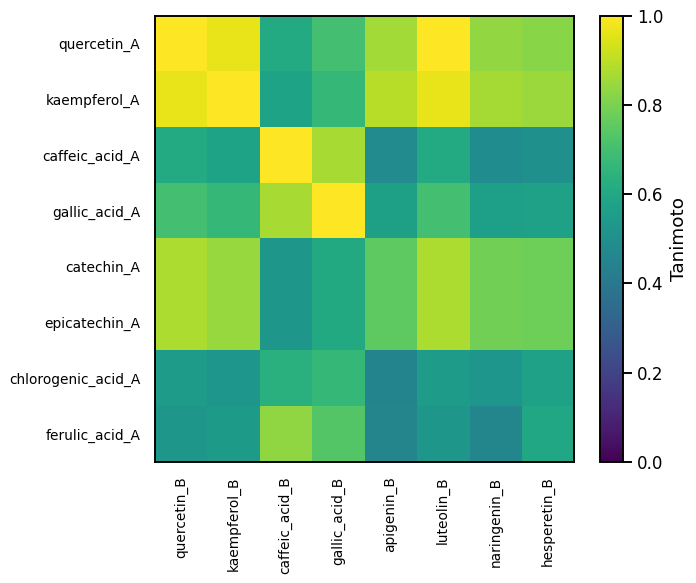

In [15]:
# 10A. Cross-Tanimoto heat-map between fraction A and fraction B (MACCS)
S = pairwise_tanimoto_matrix(d2_proc_maccs["A"]["matrix"],
                             d2_proc_maccs["B"]["matrix"])
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(S, vmin=0, vmax=1, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(d2_proc_maccs["B"]["compound_ids"])))
ax.set_yticks(range(len(d2_proc_maccs["A"]["compound_ids"])))
ax.set_xticklabels(d2_proc_maccs["B"]["compound_ids"], rotation=90, fontsize=9)
ax.set_yticklabels(d2_proc_maccs["A"]["compound_ids"], fontsize=9)
plt.colorbar(im, label="Tanimoto")
plt.tight_layout()
plt.show()


> **Figure. Cross-fraction structural similarity in Dataset 2 (plant-extract metabolites; MACCS keys).** Heat-map of the pairwise Tanimoto similarity between every metabolite recorded in fraction A (rows) and every metabolite recorded in fraction B (columns) of the plant extract. Similarity is computed from 166-bit MACCS structural keys; colour encodes the Tanimoto coefficient from 0 (no shared keys; dark blue) to 1 (identical key sets; yellow). Dataset 2 is a structure/composition-only dataset (no bioactivity): it lists which compounds occur in which chromatographic fraction, and some metabolites are common to both fractions. Bright off-diagonal cells therefore flag metabolites that, although tabulated under different fractions, are structurally (near-)identical. Axis ticks are the compound identifiers.

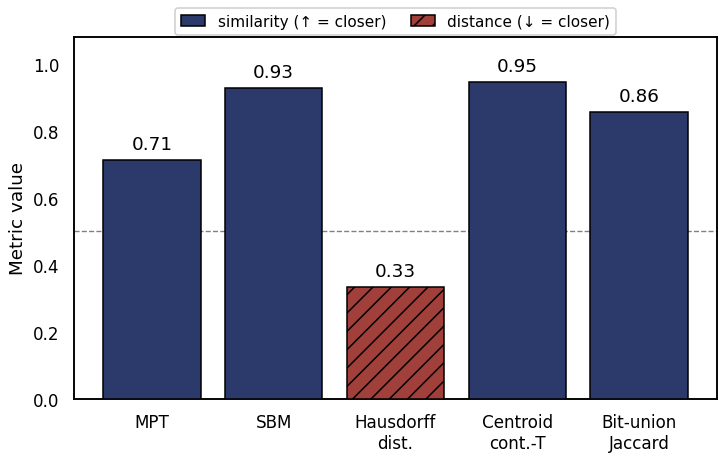

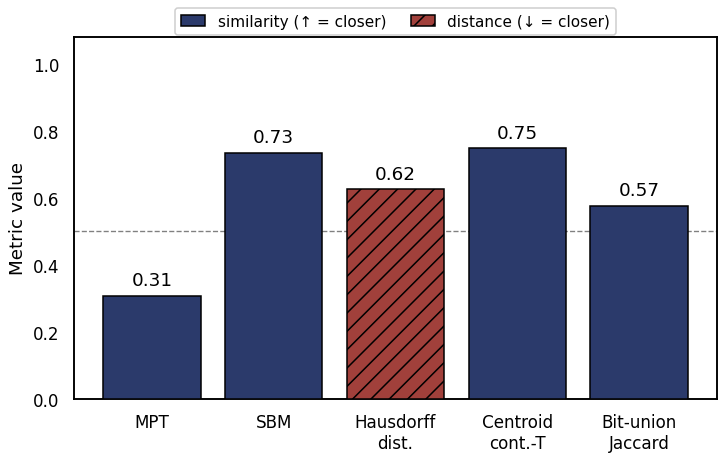

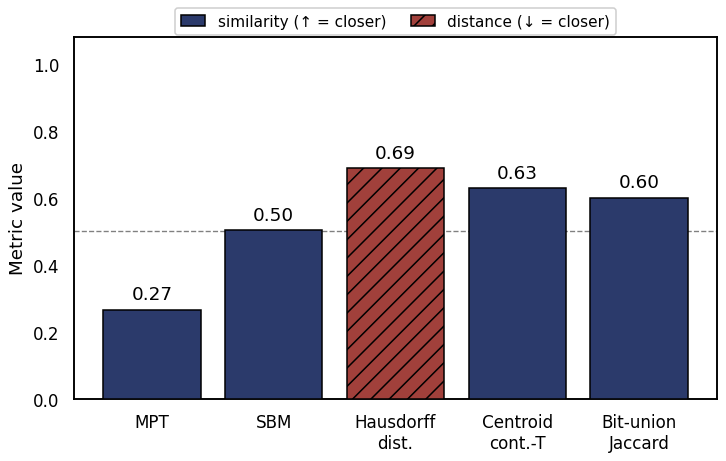

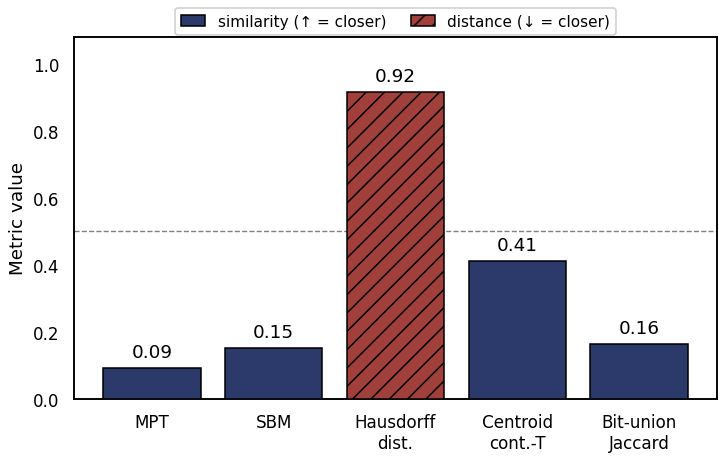

In [16]:
# === 10B. Set-vs-set metric bar-plot: one panel per dataset x fingerprint ===
# Individual bar plot of the five set-level metrics for EACH fingerprint
# (MACCS and ECFP4) of Datasets 2 and 3.  Similarity metrics are drawn in
# navy; the single distance metric (Hausdorff) is drawn in brick-red with
# diagonal hatching so its opposite "lower = closer" reading is unmistakable.
# Same fonts / no-grid style as the rest of the notebook (homogeneous look).
from matplotlib.patches import Patch

_BAR_METRICS = ["mean_pairwise_T", "symmetric_best_match_T", "hausdorff_T_distance",
                "centroid_continuous_T", "bit_union_jaccard"]
_BAR_LABELS  = ["MPT", "SBM", "Hausdorff\ndist.", "Centroid\ncont.-T", "Bit-union\nJaccard"]
_BAR_ISDIST  = [False, False, True, False, False]      # Hausdorff is a distance
_COL_SIM, _COL_DIST = "#2b3a6b", "#a1403b"             # navy / brick-red

def plot_setvs_metric_bars(df_all, fp_label, ds_tag, save=True):
    """One bar plot of the five set-vs-set metrics for a single fingerprint."""
    row  = df_all[df_all["fingerprint"] == fp_label][_BAR_METRICS].iloc[0]
    vals = [float(row[m]) for m in _BAR_METRICS]
    cols = [_COL_DIST if d else _COL_SIM for d in _BAR_ISDIST]

    fig, ax = plt.subplots(figsize=(6.8, 4.4))
    bars = ax.bar(range(len(_BAR_METRICS)), vals, color=cols,
                  edgecolor="black", linewidth=1.0, zorder=3)
    for b, isd in zip(bars, _BAR_ISDIST):
        if isd:
            b.set_hatch("//")
    for x, v in enumerate(vals):
        ax.text(x, v + 0.02, f"{v:.2f}", ha="center", va="bottom", fontsize=12)

    ax.axhline(0.5, color="grey", lw=0.9, ls="--", zorder=1)
    ax.set_xticks(range(len(_BAR_METRICS)))
    ax.set_xticklabels(_BAR_LABELS, fontsize=11)
    ax.set_ylim(0, 1.08)
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_ylabel("Metric value")
    ax.legend(handles=[
        Patch(facecolor=_COL_SIM,  edgecolor="black", label="similarity (↑ = closer)"),
        Patch(facecolor=_COL_DIST, edgecolor="black", hatch="//",
              label="distance (↓ = closer)"),
    ], loc="lower center", bbox_to_anchor=(0.5, 1.005), ncol=2, fontsize=10,
              frameon=True, framealpha=0.95, columnspacing=1.6,
              handlelength=1.6, borderaxespad=0.0)

    fig.tight_layout()
    if save:
        stem = f"fig_{ds_tag}_metric_bars_{fp_label}"
        fig.savefig(FIG_DIR / f"{stem}.png", dpi=FIG_DPI, bbox_inches="tight")
        fig.savefig(FIG_DIR / f"{stem}.pdf", bbox_inches="tight")
        fig._hr_exported = True
    plt.show()

# Dataset 2 (fractions A vs B) -- one plot per fingerprint
plot_setvs_metric_bars(d2_all, "MACCS", "D2")
plot_setvs_metric_bars(d2_all, "ECFP4", "D2")
# Dataset 3 (mixtures C vs D) -- one plot per fingerprint
plot_setvs_metric_bars(d3_all, "MACCS", "D3")
plot_setvs_metric_bars(d3_all, "ECFP4", "D3")


> **Figure. Set-versus-set similarity-metric profile (one panel per fingerprint).** Five set-level metrics computed between the two groups of the dataset (Dataset 2: plant-extract fractions A vs B; Dataset 3: mixtures C vs D), shown as an individual bar plot for each molecular fingerprint — MACCS (166-bit structural keys) and ECFP4 (Morgan, radius 2, folded to 2048 bits). Metrics: **MPT** = mean pairwise Tanimoto; **SBM** = symmetric best-match Tanimoto; **Hausdorff dist.** = Hausdorff–Tanimoto distance; **Centroid cont.-T** = centroid continuous-Tanimoto; **Bit-union Jaccard** = Jaccard overlap of the groups' bit-union fingerprints. Navy bars are similarity metrics (higher = the two groups are more alike); the hatched brick-red bar is the Hausdorff *distance* (lower = more alike). All values lie in 0–1; the dashed line at 0.5 is a visual reference.

In [17]:
# 10C. Render one example scaffold series so we can eyeball the chemistry.
#
# This cell uses RDKit's MolDraw2DSVG path, which produces SVG output
# in pure C++ and does NOT require libXrender / Cairo system libs.
# If `Draw` failed to import at the top of the notebook (e.g. because
# libXrender is missing), the cell prints a clear message and skips
# itself - the rest of the analysis is unaffected.
from IPython.display import SVG

if not _DRAW_OK:
    print("Skipped: rdkit.Chem.Draw is not importable in this environment.")
    print(f"Reason : {_DRAW_ERROR}")
    print("Fix    : sudo apt-get install -y libxrender1 libxext6 libsm6 libxcb1")
else:
    from rdkit.Chem.Draw import rdMolDraw2D

    group_smiles = list(d1_scaffold_maccs.keys())[0]              # first scaffold
    member_ids   = d1_scaffold_maccs[group_smiles]["compound_ids"]
    mols         = [df1a.loc[df1a.compound_id == cid, "mol"].iloc[0]
                    for cid in member_ids]

    mols_per_row = min(5, len(mols))
    n_rows       = (len(mols) + mols_per_row - 1) // mols_per_row
    sub_w, sub_h = 220, 200

    drawer = rdMolDraw2D.MolDraw2DSVG(
        sub_w * mols_per_row,
        sub_h * n_rows,
        sub_w, sub_h,
    )
    drawer.drawOptions().legendFontSize = 14
    drawer.DrawMolecules(mols, legends=member_ids)
    drawer.FinishDrawing()
    svg_text = drawer.GetDrawingText()

    display(SVG(svg_text))

    # Persist this structure panel: vector SVG always, plus a high-res
    # PNG when cairosvg is available.  Both land in the shared FIG_DIR.
    _svg_path = FIG_DIR / "scaffold_example_series.svg"
    _svg_path.write_text(svg_text, encoding="utf-8")
    _saved = [str(_svg_path)]
    try:
        import cairosvg
        _png_path = FIG_DIR / "scaffold_example_series.png"
        cairosvg.svg2png(bytestring=svg_text.encode("utf-8"),
                         write_to=str(_png_path), dpi=FIG_DPI)
        _saved.append(str(_png_path))
    except Exception:
        pass  # SVG is already saved; PNG is optional
    print("Saved:", "   ".join(_saved))


Skipped: rdkit.Chem.Draw is not importable in this environment.
Reason : libXrender.so.1: cannot open shared object file: No such file or directory
Fix    : sudo apt-get install -y libxrender1 libxext6 libsm6 libxcb1


### 10D — Dataset 1: full set-vs-set metric profile between Murcko scaffolds

Cell 10B visualised the *single* group-vs-group comparison available for
Datasets 2 and 3 (`A` vs `B`, `C` vs `D`) as a grouped bar chart.  Dataset 1
is structurally different: with five Bemis–Murcko scaffolds it yields
$\binom{5}{2}=10$ unordered scaffold-vs-scaffold comparisons *per fingerprint*
(the `d1_all` table built in §6).  Ten pairs times five metrics is too dense
for one bar chart to stay legible, so the profile is rendered instead as a
panel of **symmetric scaffold × scaffold heat-maps — one per metric**.

This layout is the most compact and the most directly comparable: every
off-diagonal cell is exactly one entry of `d1_all`, and reading the same cell
across the five panels recovers the complete five-number *profile* of that
scaffold pair — the central methodological point of §5 that no single scalar
should be reported in isolation.

* Panels **(a), (b), (d), (e)** are similarities (higher = more similar,
  `viridis` colour map).
* Panel **(c)** is the Hausdorff–Tanimoto *distance* (lower = closer); it uses
  a distinct `rocket` colour map and is labelled accordingly so the
  similarity/distance mix cannot be misread.
* The leading **diagonal is masked** (grey): a group compared with itself is
  degenerate (self-SBM = self-bit-union = self-centroid = 1, self-Hausdorff =
  0) and would only compress the colour scale.
* Panel **(f)** reports the **intra-scaffold homogeneity** of each group (mean
  Tanimoto over its own upper triangle, whiskers = min–max; the `intra_d1`
  table of §7).  This panel is required for interpretation: a between-scaffold
  value is only meaningful *relative to* how internally homogeneous each
  scaffold series is (§7–§8) — no two groups can be more similar to each other
  than each is to itself.

In keeping with the manuscript, **ECFP4 is the primary representation** and the
MACCS rendering is its supplementary counterpart; MACCS is expected to give
systematically higher and more compressed values because its 167-bit key space
inflates baseline similarity (§2).  Both figures are also written to
`figures/` as 300-dpi PNG and vector PDF for direct inclusion in the
manuscript/supplement.

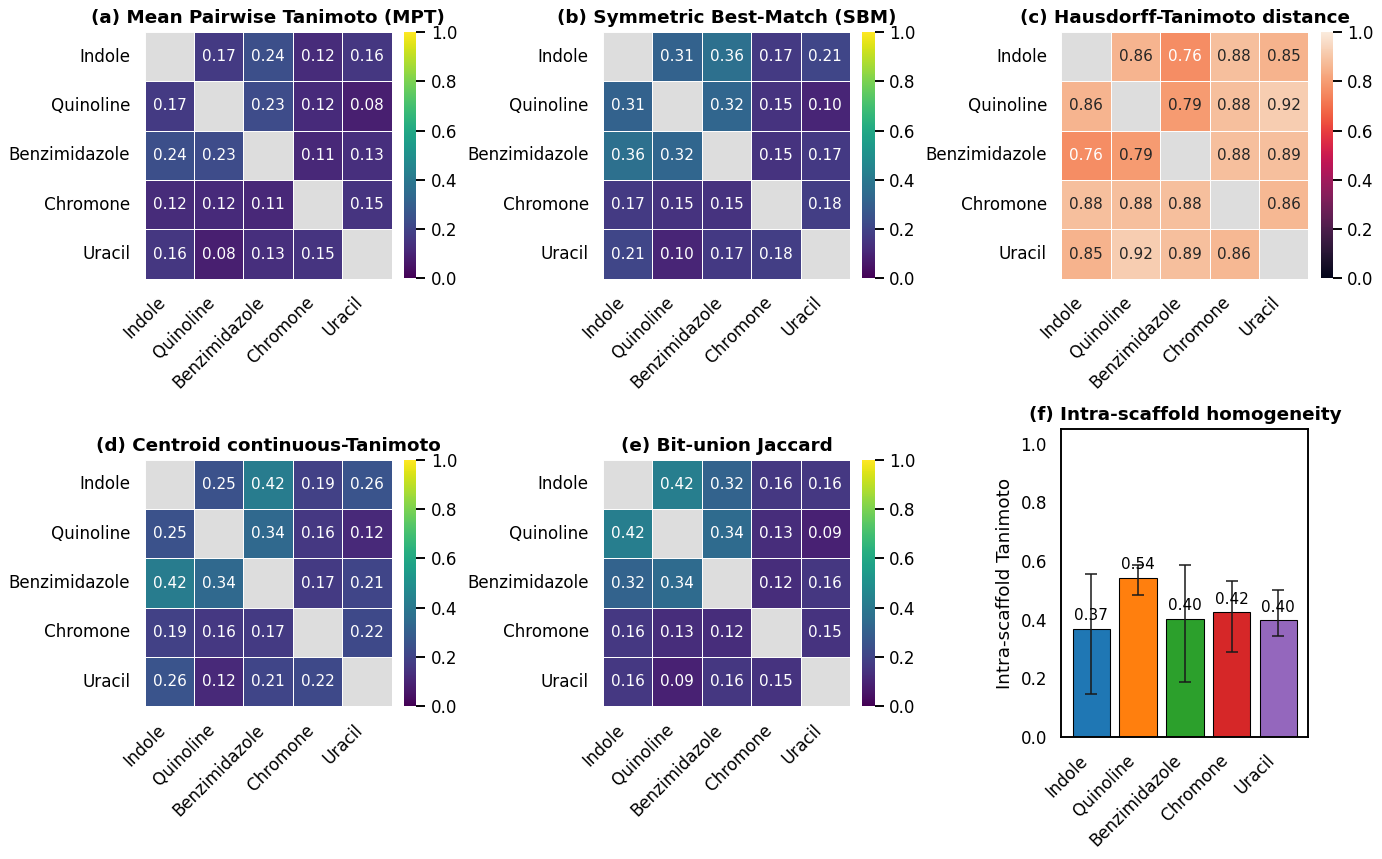

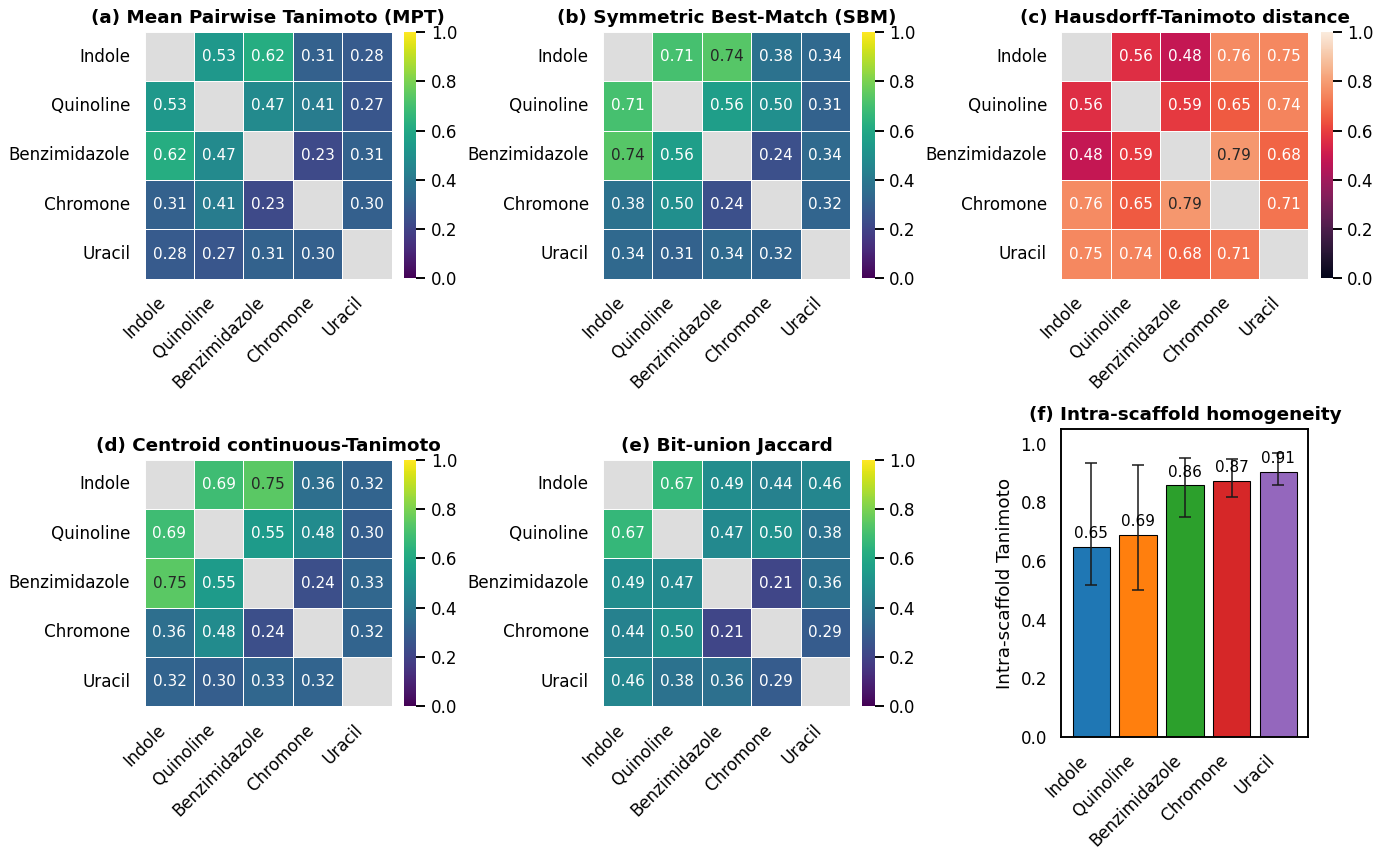

In [18]:
# === 10D. Dataset 1 set-vs-set metric profile: scaffold x scaffold heat-maps ===
# Renders the full `d1_all` similarity profile (5 metrics x 10 scaffold pairs)
# as one multi-panel figure per fingerprint, plus an intra-scaffold homogeneity
# reference panel built from `intra_d1`.  ECFP4 = main text; MACCS = supplement.
from pathlib import Path as _Path

# Publication figures are written next to the notebook (same folder used in 12.4).
_FIGDIR_10D = FIG_DIR  # unified export folder (created in the configuration cell)

# Human-readable scaffold labels, derived from the dominant compound-ID prefix
# of each Murcko scaffold (the analysis itself never relies on the IDs).
_SCAF_NICE = {"IND": "Indole", "QUI": "Quinoline", "BZI": "Benzimidazole",
              "CHR": "Chromone", "URA": "Uracil"}
_tmp = df1a.assign(_prefix=df1a["compound_id"].str.split("-").str[0])
SCAFFOLD_ORDER, SCAFFOLD_LABEL = [], {}
for _scaf, _sub in _tmp.groupby("scaffold", sort=False):
    SCAFFOLD_ORDER.append(_scaf)
    SCAFFOLD_LABEL[_scaf] = _SCAF_NICE.get(_sub["_prefix"].mode().iloc[0], _scaf)

# (metric column, panel title, kind) — kind drives colormap & legend wording.
_D1_METRICS = [
    ("mean_pairwise_T",        "Mean Pairwise Tanimoto (MPT)",    "similarity"),
    ("symmetric_best_match_T", "Symmetric Best-Match (SBM)",      "similarity"),
    ("hausdorff_T_distance",   "Hausdorff-Tanimoto distance",     "distance"),
    ("centroid_continuous_T",  "Centroid continuous-Tanimoto",    "similarity"),
    ("bit_union_jaccard",      "Bit-union Jaccard",               "similarity"),
]

def _d1_metric_matrix(df_fp, metric, order):
    """Symmetric n x n matrix of one metric over all scaffold pairs (diag = NaN)."""
    idx = {k: i for i, k in enumerate(order)}
    M = np.full((len(order), len(order)), np.nan)
    for _, r in df_fp.iterrows():
        i, j = idx[r["group_A"]], idx[r["group_B"]]
        M[i, j] = M[j, i] = r[metric]
    return M

def plot_dataset1_metric_profile(d1_all, intra_d1, fp_label, save=True):
    """Multi-panel scaffold x scaffold heat-maps of the five set-vs-set metrics
    for Dataset 1, plus an intra-scaffold homogeneity panel.

    Parameters
    ----------
    d1_all : DataFrame from section 6 (five metric columns + group_A/group_B).
    intra_d1 : DataFrame from section 7 (intra-set mean/min/max Tanimoto / group).
    fp_label : "ECFP4" (main text) or "MACCS" (supplement).
    """
    df_fp  = d1_all[d1_all["fingerprint"] == fp_label]
    intra  = intra_d1[intra_d1["fingerprint"] == fp_label].set_index("group")
    labels = [SCAFFOLD_LABEL[k] for k in SCAFFOLD_ORDER]

    fig = plt.figure(figsize=(12.5, 7.8), constrained_layout=True)
    gs  = fig.add_gridspec(2, 3)
    axes = [fig.add_subplot(gs[i // 3, i % 3]) for i in range(6)]

    for ax, (mkey, mtitle, kind), letter in zip(axes[:5], _D1_METRICS, "abcde"):
        M = _d1_metric_matrix(df_fp, mkey, SCAFFOLD_ORDER)
        sns.heatmap(M, ax=ax, cmap=("viridis" if kind == "similarity" else "rocket"),
                    vmin=0, vmax=1, square=True, annot=True, fmt=".2f",
                    annot_kws={"size": 10}, linewidths=0.6, linecolor="white",
                    cbar_kws={"shrink": 0.8}, xticklabels=labels, yticklabels=labels)
        for d in range(len(labels)):                       # mask degenerate diagonal
            ax.add_patch(plt.Rectangle((d, d), 1, 1, color="#dddddd",
                                       ec="white", lw=0.6, zorder=2))
        note = "" if kind == "similarity" else ""
        ax.set_title(f"({letter}) {mtitle}{note}", fontsize=12)
        ax.tick_params(axis="x", rotation=45); ax.tick_params(axis="y", rotation=0)
        for t in ax.get_xticklabels():
            t.set_ha("right")

    # (f) intra-scaffold homogeneity — the baseline that makes (a)-(e) interpretable
    axf  = axes[5]
    mean = np.array([intra.loc[k, "mean_T"] if k in intra.index else np.nan
                     for k in SCAFFOLD_ORDER], float)
    lo   = mean - np.array([intra.loc[k, "min_T"] if k in intra.index else np.nan
                            for k in SCAFFOLD_ORDER], float)
    hi   = np.array([intra.loc[k, "max_T"] if k in intra.index else np.nan
                     for k in SCAFFOLD_ORDER], float) - mean
    xs   = np.arange(len(SCAFFOLD_ORDER))
    axf.bar(xs, mean, color=sns.color_palette("tab10", len(SCAFFOLD_ORDER)),
            edgecolor="black", linewidth=0.7,
            yerr=[np.nan_to_num(lo), np.nan_to_num(hi)], capsize=4,
            error_kw={"elinewidth": 1.0})
    for x, m in zip(xs, mean):
        if not np.isnan(m):
            axf.text(x, m + 0.02, f"{m:.2f}", ha="center", va="bottom", fontsize=10)
    axf.set_xticks(xs); axf.set_xticklabels(labels, rotation=45, ha="right")
    axf.set_ylim(0, 1.05); axf.set_ylabel("Intra-scaffold Tanimoto")
    axf.set_title("(f) Intra-scaffold homogeneity",
                  fontsize=12)

    if save:
        stem = "fig_D1_metrics_ECFP4" if fp_label == "ECFP4" else "figS_D1_metrics_MACCS"
        fig.savefig(_FIGDIR_10D / f"{stem}.png", dpi=FIG_DPI, bbox_inches="tight")
        fig.savefig(_FIGDIR_10D / f"{stem}.pdf", bbox_inches="tight")
        fig._hr_exported = True  # curated names already written; skip auto-export
    plt.show()

# ECFP4 first (main text), then MACCS (supplementary).
plot_dataset1_metric_profile(d1_all, intra_d1, "ECFP4")
plot_dataset1_metric_profile(d1_all, intra_d1, "MACCS")

> **Figure. Scaffold-by-scaffold set-versus-set similarity profile of Dataset 1.** Dataset 1 consists of five congeneric series defined by their Bemis–Murcko scaffold: indole (IND), quinoline (QUI), benzimidazole (BZI), chromone (CHR) and uracil (URA). Panels **(a–e)** show, for each pair of scaffold series, one set-level metric: (a) mean pairwise Tanimoto (MPT), (b) symmetric best-match Tanimoto (SBM), (c) Hausdorff–Tanimoto *distance* (lower = closer), (d) centroid continuous-Tanimoto and (e) bit-union Jaccard. In each matrix the rows and columns are the five scaffold series; the degenerate diagonal is masked in grey. Colour scales span 0–1 (similarity metrics: *viridis*; the distance metric: *rocket*), and every cell is annotated with its value. Panel **(f)** gives the intra-scaffold homogeneity baseline that makes (a–e) interpretable: bars are the mean within-series Tanimoto and the whiskers span the observed min–max. The figure is generated twice — with **ECFP4** (main text) and with **MACCS** (supplementary).

## 11. What to keep, what to throw away

* Keep the **5-metric profile** when discussing how similar two sets
  of compounds are.  Reporting a single number invites methodological
  disputes that the profile dissolves.
* Always pair set-vs-set scores with **intra-set diagnostics** -
  otherwise high scores can simply mean both sets are internally
  trivial.
* Always report **both** MACCS and ECFP4.  Agreement increases
  confidence; disagreement is itself useful information (it usually
  flags either coarse substructure overlap with very different
  detailed environments, or vice versa).
* The notebook is fully **self-contained, reproducible, and seeded**;
  re-running it on the same RDKit version must give bit-for-bit
  identical results.

# Part II — Extended data-science analysis

The remaining sections build a comprehensive **exploratory analysis**
on top of the foundations laid above.  Each new section is independent
of the others, so you can run or skip them in any order.

## 12. Per-dataset exploratory data analysis

Each of the three datasets tells a different story, so it deserves
its own panel of diagnostic plots.  The plots we build are not
chosen at random — each one targets a specific question a data
scientist would ask of an SAR / chemical-diversity table:

| Plot | Question it answers |
|---|---|
| pIC50 histogram + KDE *(activity datasets only — here Dataset 1)* | Is activity normally distributed? Multi-modal? |
| pIC50 by group (boxplot) *(activity datasets only — here Dataset 1)* | Does the grouping variable correlate with potency? |
| Bits-per-fingerprint histogram | Are some compounds much more "decorated" than others? Indicator of size bias. |
| Intra-dataset Tanimoto heatmap | Where are the structural clusters? Compound ordering matters here. |
| Hierarchical dendrogram | What is the natural cluster hierarchy? Does it match the grouping label? |
| Intra-group vs inter-group similarity violin | Are the groups *actually* more compact than random? Effect size of grouping. |
| Scaffold frequency bar (D1 only) | How balanced is the scaffold series? |

Common helper functions are defined first, then each dataset gets a
single multi-panel figure.

In [19]:
import seaborn as sns
import warnings
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

# Silence seaborn future-warnings about palette/hue ergonomics so the
# notebook output stays focused on the analysis.  These are cosmetic
# and do not affect the rendered figures.
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")
# UMAP also issues a benign UserWarning when the dataset is so small
# that the gradient descent converges in fewer than the default 200
# epochs.  This does not affect correctness on our test datasets.
warnings.filterwarnings("ignore", category=UserWarning, module="umap.*")
# sklearn's t-SNE warns when it converts uint8 fingerprints to bool
# for the Jaccard distance computation -- this is exactly what we
# want it to do.
try:
    from sklearn.exceptions import DataConversionWarning
    warnings.filterwarnings("ignore", category=DataConversionWarning)
except ImportError:
    pass

# Re-apply the publication style here: seaborn's set_theme would
# otherwise reset the text colours to grey.
apply_publication_style()

def fp_stack(df: pd.DataFrame, fp_col: str) -> np.ndarray:
    """Stack the binary fingerprints of a dataframe into a numpy matrix."""
    return np.vstack(df[fp_col].apply(fp_to_numpy).values) \
        if df[fp_col].dtype == object and len(df) > 0 else \
        np.zeros((0, 0), dtype=np.uint8)

# Pre-compute numpy versions of all fingerprints (we used to do this on the fly).
for _df in (df1a, df2a, df3a):
    _df["maccs_np"] = _df["maccs_fp"].apply(fp_to_numpy)
    _df["ecfp4_np"] = _df["ecfp4_fp"].apply(fp_to_numpy)

def get_matrix(df, fp_kind):
    col = "maccs_np" if fp_kind == "MACCS" else "ecfp4_np"
    return np.vstack(df[col].values)

def reorder_by_clustering(S):
    """Return a row/column permutation that exposes the cluster
    structure of similarity matrix *S* (1 - S used as distance)."""
    D = 1.0 - S
    # Force the diagonal to exactly zero (within float tolerance)
    np.fill_diagonal(D, 0.0)
    # Symmetrise to remove any numerical drift
    D = (D + D.T) / 2
    cond = squareform(D, checks=False)
    Z = linkage(cond, method="average")
    return dendrogram(Z, no_plot=True)["leaves"], Z


### 12.1 — Dataset 1 (scaffold series)

Because Dataset 1 was *built* around five Murcko scaffolds, we expect
the intra-scaffold Tanimoto values to be visibly higher than the
inter-scaffold ones.  If they are not, our hypothetical SMILES are
not as clean as we thought.

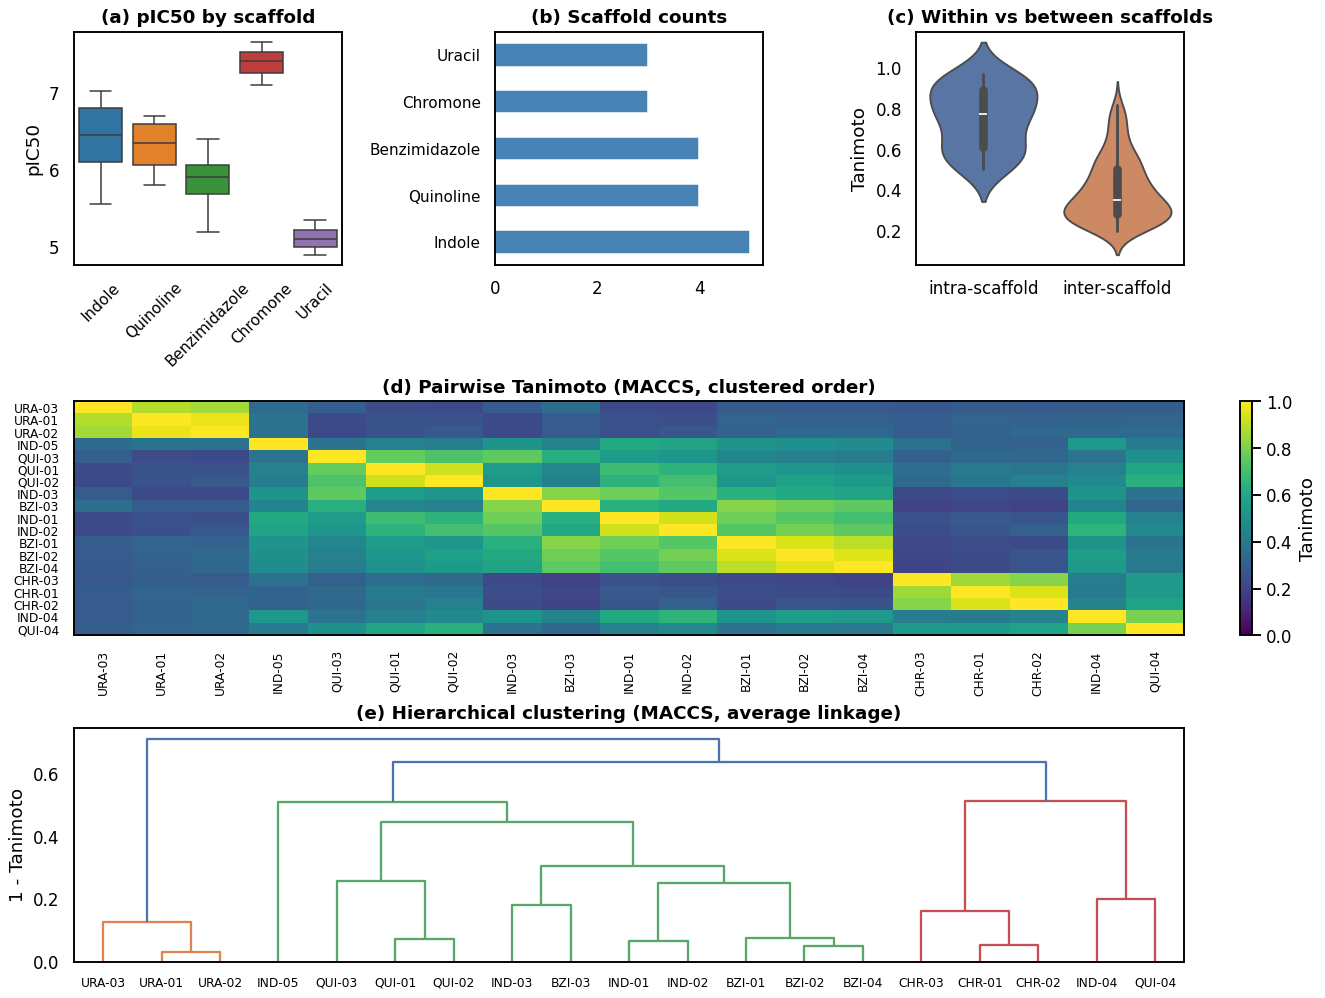

[MACCS] mean intra-scaffold Tanimoto = 0.754
[MACCS] mean inter-scaffold Tanimoto = 0.397


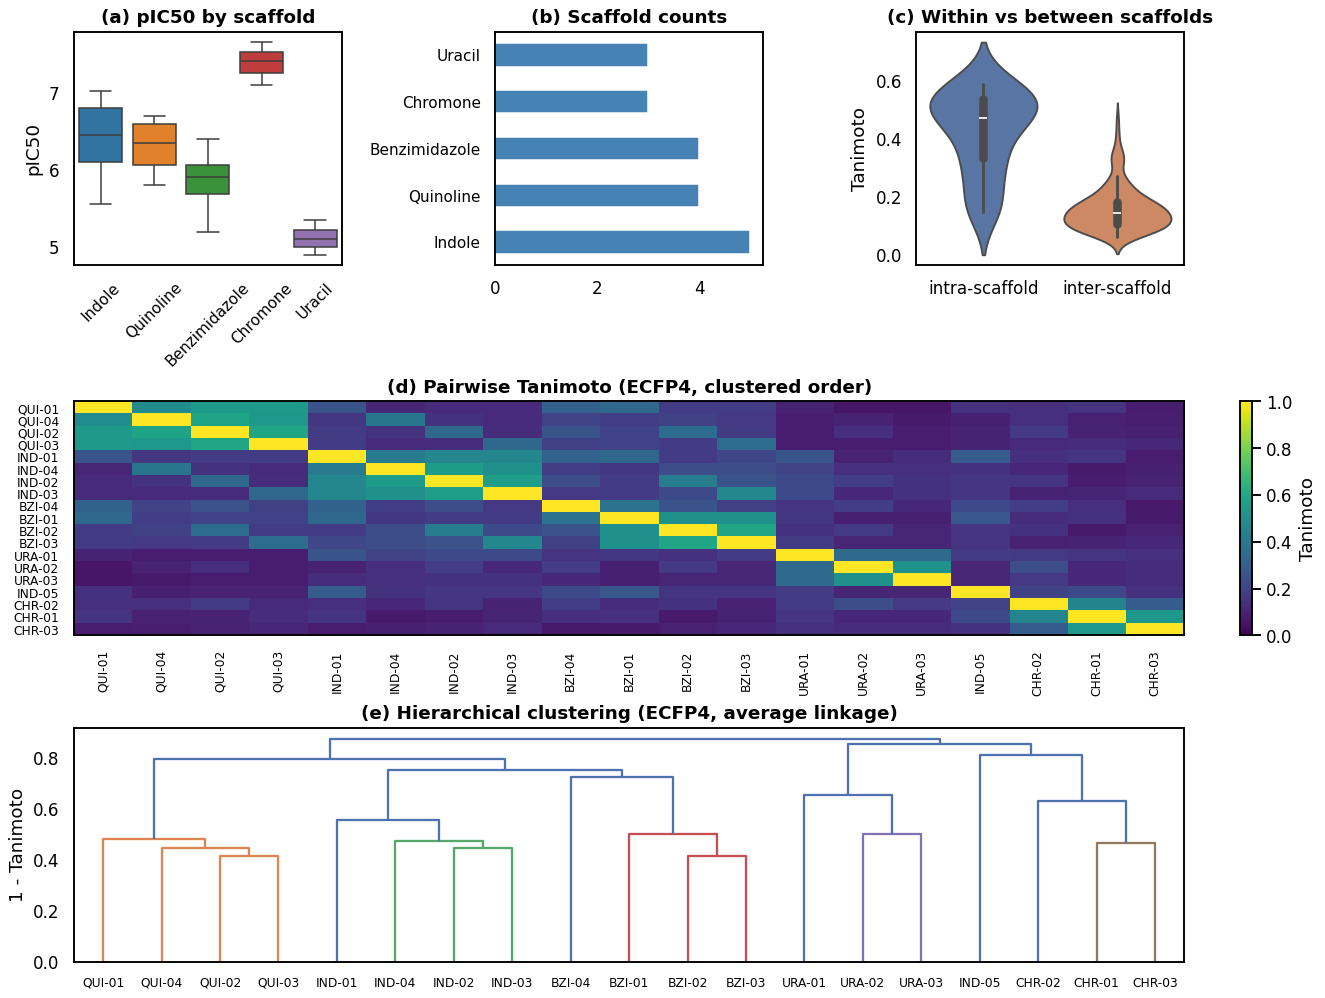

[ECFP4] mean intra-scaffold Tanimoto = 0.423
[ECFP4] mean inter-scaffold Tanimoto = 0.159


In [20]:
def scaffold_label_series(df):
    """Readable scaffold labels (from the dominant compound-id prefix) so that
    axis ticks and legends never display the raw scaffold SMILES string."""
    _names = {"IND": "Indole", "QUI": "Quinoline", "BZI": "Benzimidazole",
              "CHR": "Chromone", "URA": "Uracil"}
    pref = df["compound_id"].astype(str).str.extract(r"^([A-Za-z]+)")[0]
    mapping, k = {}, 0
    for scaf in pd.unique(df["scaffold"]):
        m = (df["scaffold"] == scaf)
        p = pref[m].mode()
        p = (p.iloc[0] if len(p) else "")
        if p in _names:
            mapping[scaf] = _names[p]
        elif p and p.isalpha() and len(p) <= 5:
            mapping[scaf] = p.upper()
        else:
            k += 1
            mapping[scaf] = f"Sc{k}"
    return df["scaffold"].map(mapping)


def eda_dataset1(df, fp_kind="ECFP4"):
    """Multi-panel EDA for a dataset organised by Murcko scaffold.

    If the dataframe has no usable ``pIC50`` column the activity panel
    is dropped automatically and the remaining panels are re-laid-out, so
    the function also works for structure-only inputs.
    """
    X = get_matrix(df, fp_kind)
    S = pairwise_tanimoto_matrix(X, X)
    order, Z = reorder_by_clustering(S)
    df = df.copy()
    df["_scaf_disp"] = scaffold_label_series(df)

    has_pic50 = ("pIC50" in df.columns) and df["pIC50"].notna().any()

    # Intra/inter-scaffold Tanimoto (violin panel + printed effect size)
    grp = df["scaffold"].values
    intra, inter = [], []
    for i in range(len(grp)):
        for j in range(i + 1, len(grp)):
            (intra if grp[i] == grp[j] else inter).append(S[i, j])

    from string import ascii_lowercase
    _lab = iter(ascii_lowercase)
    nxt = lambda: f"({next(_lab)})"

    # ---- individual panel painters -------------------------------------
    def p_pic50_box(ax):
        sns.boxplot(data=df, x="_scaf_disp", y="pIC50", ax=ax,
                    hue="_scaf_disp", palette="tab10", legend=False)
        ax.tick_params(axis="x", rotation=45, labelsize=10)
        ax.set_title(f"{nxt()} pIC50 by scaffold")
        ax.set_xlabel("")

    def p_counts(ax):
        df["_scaf_disp"].value_counts().plot(kind="barh", ax=ax, color="steelblue")
        ax.set_title(f"{nxt()} Scaffold counts")
        ax.set_ylabel("")
        ax.tick_params(axis="y", labelsize=10)

    def p_heatmap(ax):
        S_re = S[np.ix_(order, order)]
        ids = [df["compound_id"].iloc[i] for i in order]
        im = ax.imshow(S_re, vmin=0, vmax=1, cmap="viridis", aspect="auto")
        ax.set_xticks(range(len(ids))); ax.set_yticks(range(len(ids)))
        ax.set_xticklabels(ids, rotation=90, fontsize=8)
        ax.set_yticklabels(ids, fontsize=8)
        ax.set_title(f"{nxt()} Pairwise Tanimoto ({fp_kind}, clustered order)")
        plt.colorbar(im, ax=ax, fraction=0.04, label="Tanimoto")

    def p_violin(ax):
        sns.violinplot(data=[intra, inter], ax=ax, inner="box")
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["intra-scaffold", "inter-scaffold"])
        ax.set_title(f"{nxt()} Within vs between scaffolds")
        ax.set_ylabel("Tanimoto")

    def p_dendro(ax):
        dendrogram(Z, labels=df["compound_id"].values, ax=ax, leaf_font_size=8,
                   color_threshold=0.55)
        ax.set_title(f"{nxt()} Hierarchical clustering ({fp_kind}, average linkage)")
        ax.set_ylabel("1 - Tanimoto")

    # ---- assemble figure (layout depends on availability of pIC50) -----
    if has_pic50:
        fig = plt.figure(figsize=(12, 9), constrained_layout=True)
        gs = fig.add_gridspec(3, 3)
        p_pic50_box(fig.add_subplot(gs[0, 0]))
        p_counts(fig.add_subplot(gs[0, 1]))
        p_violin(fig.add_subplot(gs[0, 2]))
        p_heatmap(fig.add_subplot(gs[1, :]))
        p_dendro(fig.add_subplot(gs[2, :]))
    else:
        fig = plt.figure(figsize=(12, 9.5), constrained_layout=True)
        gs = fig.add_gridspec(3, 2)
        p_counts(fig.add_subplot(gs[0, 0]))
        p_violin(fig.add_subplot(gs[0, 1]))
        p_heatmap(fig.add_subplot(gs[1, :]))
        p_dendro(fig.add_subplot(gs[2, :]))

    plt.show()

    print(f"[{fp_kind}] mean intra-scaffold Tanimoto = {np.mean(intra):.3f}")
    print(f"[{fp_kind}] mean inter-scaffold Tanimoto = {np.mean(inter):.3f}")

eda_dataset1(df1a, "MACCS")
eda_dataset1(df1a, "ECFP4")


> **Figure. Exploratory structural analysis of Dataset 1, organised by Bemis–Murcko scaffold.** Dataset 1 is a set of synthetic compounds grouped into five scaffold series (indole, quinoline, benzimidazole, chromone, uracil) with measured potency (pIC50). Panels: **(a)** distribution of pIC50 by scaffold; **(b)** number of compounds per scaffold; **(c)** violin plot comparing the distribution of pairwise Tanimoto similarities *within* scaffolds (intra) versus *between* scaffolds (inter); **(d)** the full pairwise Tanimoto similarity matrix, with rows/columns reordered by average-linkage hierarchical clustering so structurally similar compounds are adjacent (colour = Tanimoto, 0–1); **(e)** the corresponding dendrogram (distance = 1 − Tanimoto). The figure is produced for both fingerprints (MACCS and ECFP4); the panel headers state which one. The mean intra- and inter-scaffold Tanimoto values are printed below the figure.

### 12.2 — Dataset 2 (plant fractions A vs B with overlap)

Because Dataset 2 was built with **deliberate molecule overlap** between
A and B, the within-fraction Tanimoto distribution should not differ
dramatically from the between-fraction distribution.  The diagnostic
that surfaces this is the "compound recurrence" view below.

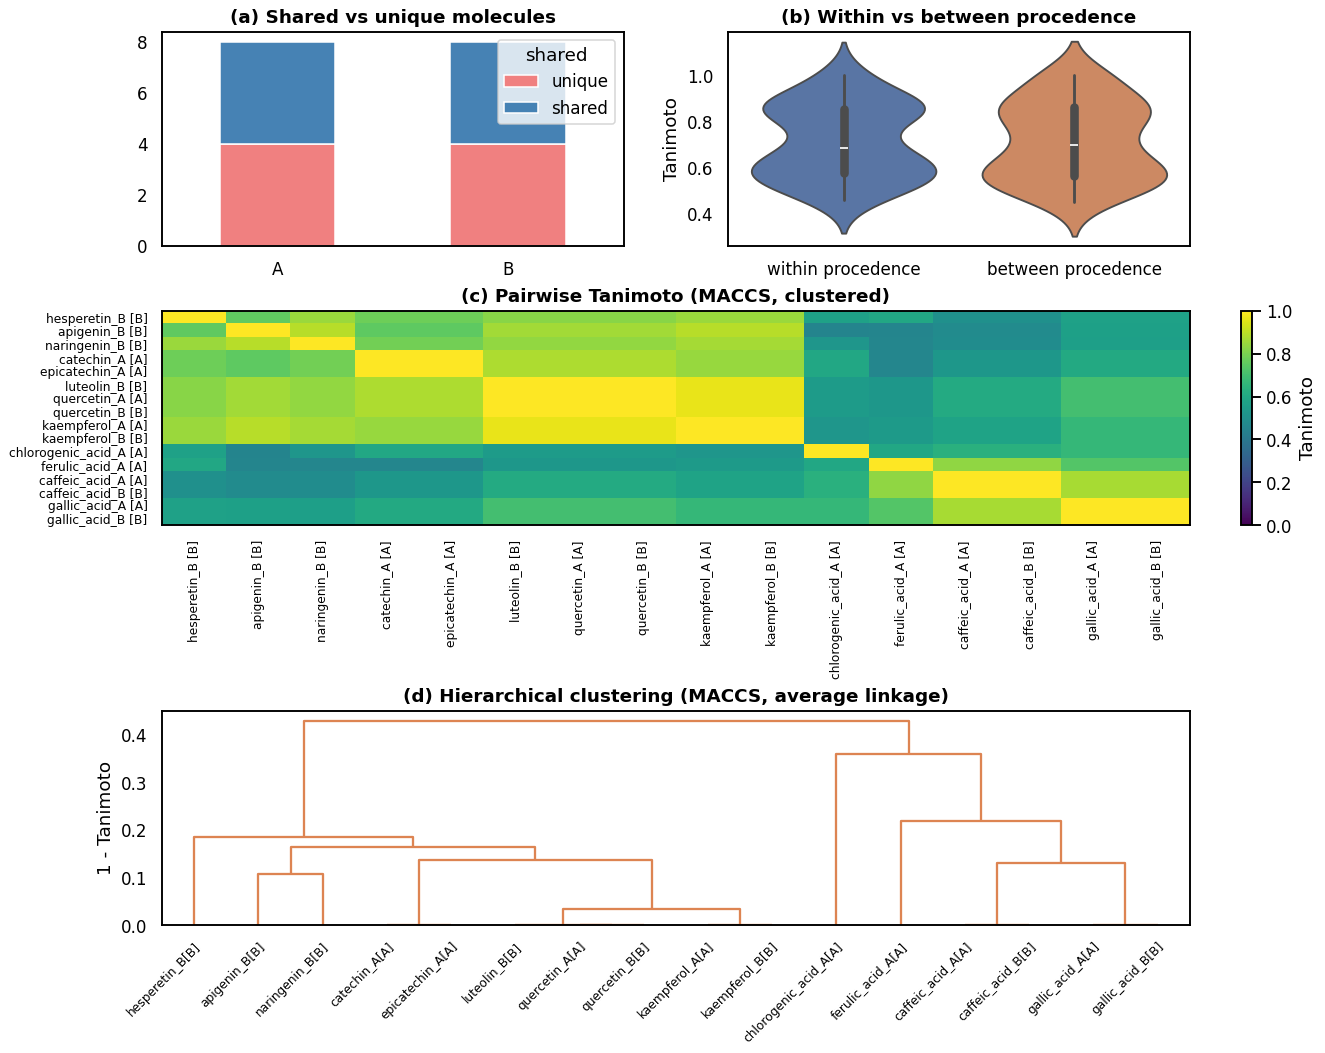

[MACCS] mean within-procedence Tanimoto = 0.711
[MACCS] mean between-procedence Tanimoto = 0.713


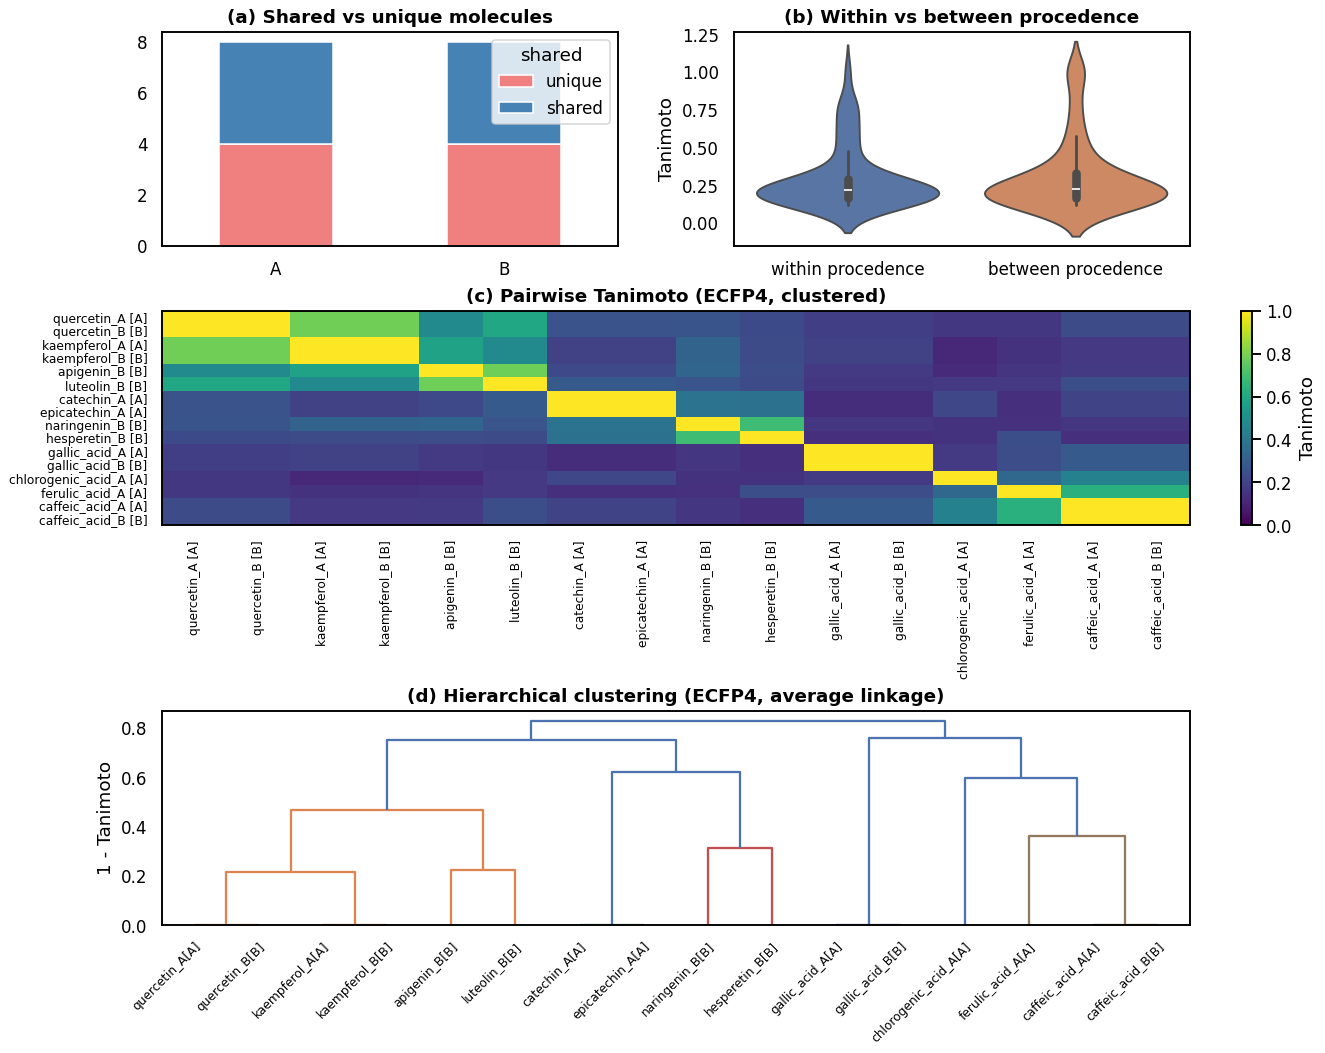

[ECFP4] mean within-procedence Tanimoto = 0.293
[ECFP4] mean between-procedence Tanimoto = 0.307


In [21]:
def eda_procedence_dataset(df, fp_kind="ECFP4", title=""):
    """Multi-panel EDA for a dataset organised by ``procedence``.

    Datasets 2 and 3 carry no activity column, so the two pIC50 panels are
    included only when a usable ``pIC50`` column is present; the grid is
    re-laid-out automatically otherwise.
    """
    X = get_matrix(df, fp_kind)
    S = pairwise_tanimoto_matrix(X, X)
    order, Z = reorder_by_clustering(S)

    has_pic50 = ("pIC50" in df.columns) and df["pIC50"].notna().any()

    # Detect canonical SMILES shared between procedence groups
    counts_by_smiles = (df.groupby("canonical_smiles")["procedence"]
                          .nunique().reset_index(name="n_groups"))
    shared_smiles = set(counts_by_smiles.loc[counts_by_smiles["n_groups"] > 1,
                                             "canonical_smiles"])
    df = df.assign(shared=df["canonical_smiles"].isin(shared_smiles))

    # Intra/inter-procedence Tanimoto (violin panel + printed effect size)
    grp = df["procedence"].values
    intra, inter = [], []
    for i in range(len(grp)):
        for j in range(i + 1, len(grp)):
            (intra if grp[i] == grp[j] else inter).append(S[i, j])

    from string import ascii_lowercase
    _lab = iter(ascii_lowercase)
    nxt = lambda: f"({next(_lab)})"

    def p_pic50_hist(ax):
        sns.histplot(data=df, x="pIC50", hue="procedence", multiple="layer",
                     bins=8, ax=ax, palette="Set1")
        ax.set_title(f"{nxt()} pIC50 by procedence")

    def p_pic50_box(ax):
        sns.boxplot(data=df, x="procedence", y="pIC50", ax=ax,
                    hue="procedence", palette="Set1", legend=False)
        sns.stripplot(data=df, x="procedence", y="pIC50", ax=ax, color="black",
                      size=4, alpha=0.6)
        ax.set_title(f"{nxt()} pIC50 by procedence")

    def p_shared_unique(ax):
        summary = (df.groupby(["procedence", "shared"]).size()
                   .unstack(fill_value=0)
                   .rename(columns={False: "unique", True: "shared"}))
        for col in ("unique", "shared"):
            if col not in summary.columns:
                summary[col] = 0
        summary = summary[["unique", "shared"]]
        summary.plot(kind="bar", stacked=True, ax=ax,
                     color=["lightcoral", "steelblue"])
        ax.set_title(f"{nxt()} Shared vs unique molecules")
        ax.tick_params(axis="x", rotation=0)
        ax.set_xlabel("")

    def p_heatmap(ax):
        S_re = S[np.ix_(order, order)]
        ids = [df["compound_id"].iloc[i] for i in order]
        procs = [df["procedence"].iloc[i] for i in order]
        label = [f"{cid} [{p}]" for cid, p in zip(ids, procs)]
        im = ax.imshow(S_re, vmin=0, vmax=1, cmap="viridis", aspect="auto")
        ax.set_xticks(range(len(ids))); ax.set_yticks(range(len(ids)))
        ax.set_xticklabels(label, rotation=90, fontsize=8)
        ax.set_yticklabels(label, fontsize=8)
        ax.set_title(f"{nxt()} Pairwise Tanimoto ({fp_kind}, clustered)")
        plt.colorbar(im, ax=ax, fraction=0.04, label="Tanimoto")

    def p_violin(ax):
        sns.violinplot(data=[intra, inter], ax=ax, inner="box")
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["within procedence", "between procedence"])
        ax.set_ylabel("Tanimoto")
        ax.set_title(f"{nxt()} Within vs between procedence")

    def p_dendro(ax):
        dendrogram(Z,
                   labels=[f"{c}[{p}]" for c, p in zip(df.compound_id, df.procedence)],
                   ax=ax, leaf_font_size=8, leaf_rotation=45,
                   color_threshold=0.55)
        ax.set_title(f"{nxt()} Hierarchical clustering ({fp_kind}, average linkage)")
        ax.set_ylabel("1 - Tanimoto")
        for _lbl in ax.get_xticklabels():      # 45-degree leaf labels (avoid overlap)
            _lbl.set_rotation(45)
            _lbl.set_ha("right")
            _lbl.set_rotation_mode("anchor")

    if has_pic50:
        fig = plt.figure(figsize=(12, 9), constrained_layout=True)
        gs = fig.add_gridspec(3, 3)
        p_pic50_hist(fig.add_subplot(gs[0, 0]))
        p_pic50_box(fig.add_subplot(gs[0, 1]))
        p_shared_unique(fig.add_subplot(gs[0, 2]))
        p_heatmap(fig.add_subplot(gs[1, :]))
        p_violin(fig.add_subplot(gs[2, 0]))
        p_dendro(fig.add_subplot(gs[2, 1:]))
    else:
        fig = plt.figure(figsize=(12, 9.5), constrained_layout=True)
        gs = fig.add_gridspec(3, 2)
        p_shared_unique(fig.add_subplot(gs[0, 0]))
        p_violin(fig.add_subplot(gs[0, 1]))
        p_heatmap(fig.add_subplot(gs[1, :]))
        p_dendro(fig.add_subplot(gs[2, :]))

    plt.show()
    print(f"[{fp_kind}] mean within-procedence Tanimoto = {np.mean(intra):.3f}")
    print(f"[{fp_kind}] mean between-procedence Tanimoto = {np.mean(inter):.3f}")

eda_procedence_dataset(df2a, "MACCS", title="Dataset 2 (plant fractions A vs B)")
eda_procedence_dataset(df2a, "ECFP4", title="Dataset 2 (plant fractions A vs B)")


> **Figure. Exploratory structural analysis of Dataset 2 (plant-extract fractions A vs B).** Dataset 2 records which metabolites occur in fraction A and which in fraction B; some metabolites are shared between fractions and there is no bioactivity label. Panels: **(a)** number of metabolites unique to a fraction versus shared between fractions; **(b)** violin plot of pairwise Tanimoto similarities *within* the same fraction versus *between* fractions; **(c)** clustered pairwise Tanimoto matrix (each tick is `compound [fraction]`; colour = Tanimoto, 0–1); **(d)** average-linkage dendrogram (distance = 1 − Tanimoto). Generated for both fingerprints (MACCS and ECFP4), indicated in the panel headers.

### 12.3 — Dataset 3 (disjoint mixtures C vs D)

Dataset 3 was built so that C and D share *no* molecules.  We expect
the within-procedence Tanimoto distribution to be *higher* than the
between-procedence one, even though both groups are internally diverse
mixtures of arbitrary structures.

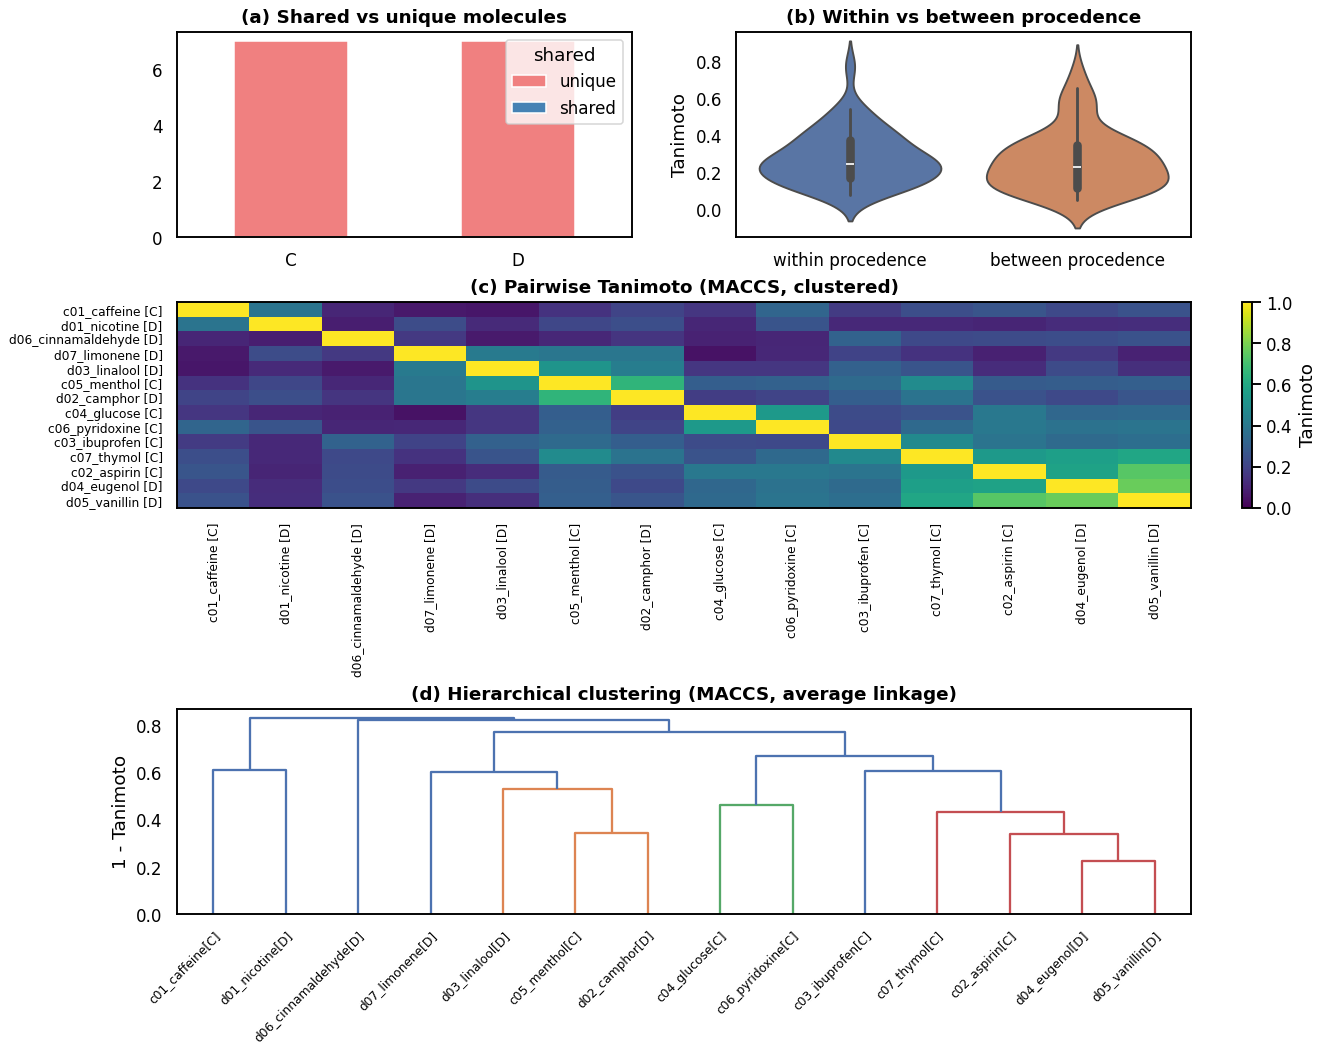

[MACCS] mean within-procedence Tanimoto = 0.280
[MACCS] mean between-procedence Tanimoto = 0.265


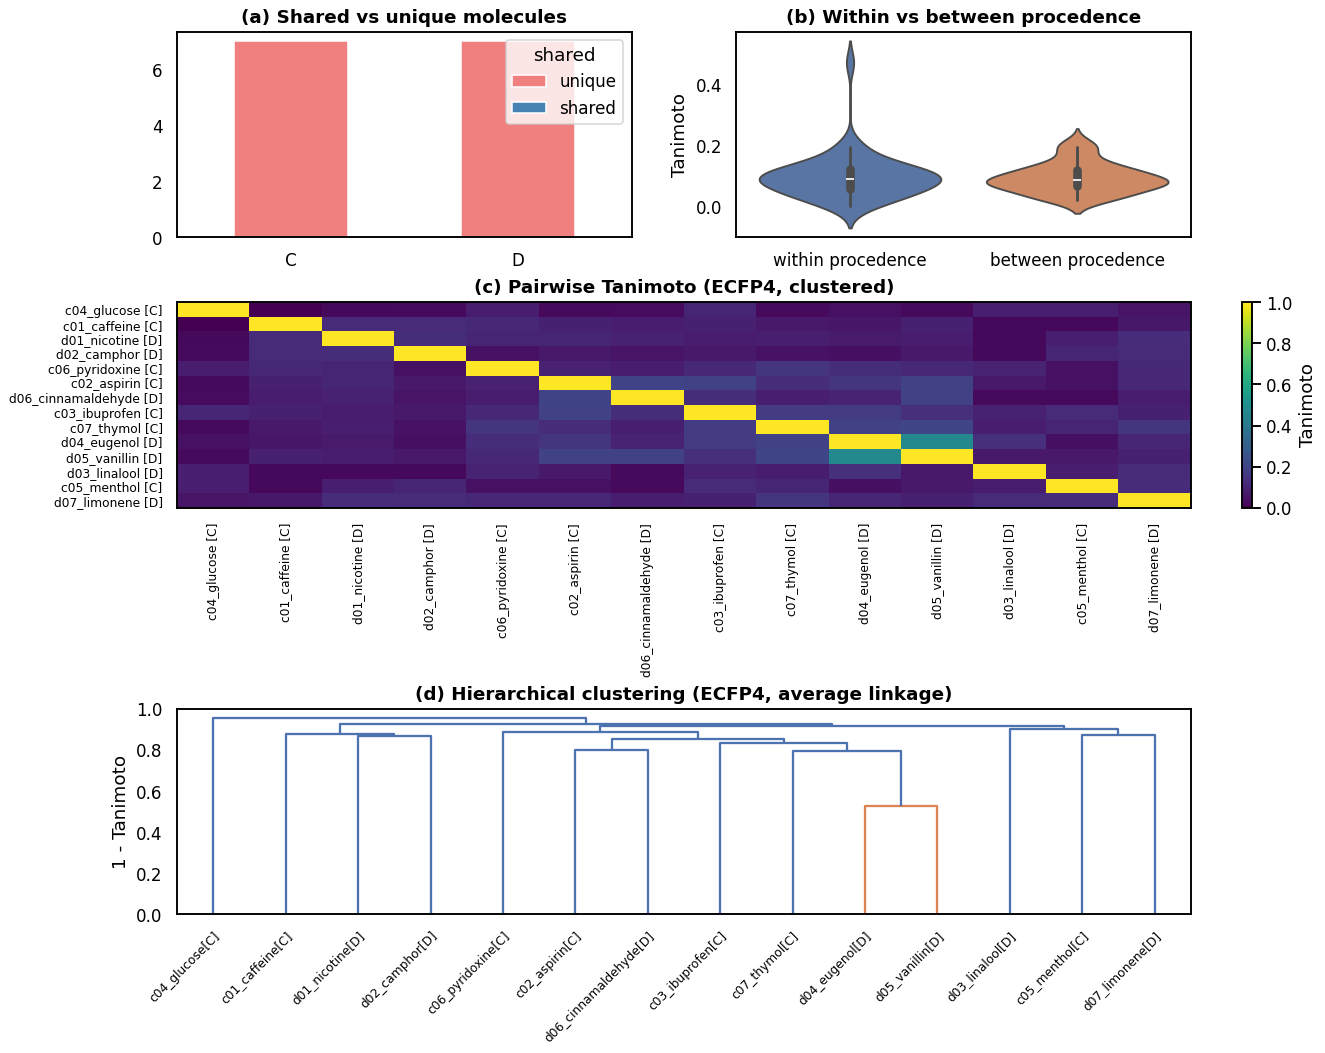

[ECFP4] mean within-procedence Tanimoto = 0.097
[ECFP4] mean between-procedence Tanimoto = 0.093


In [22]:
eda_procedence_dataset(df3a, "MACCS", title="Dataset 3 (mixtures C vs D)")
eda_procedence_dataset(df3a, "ECFP4", title="Dataset 3 (mixtures C vs D)")


> **Figure. Exploratory structural analysis of Dataset 3 (mixtures C vs D).** Dataset 3 contains two disjoint mixtures, C and D, that share no compounds and carry no bioactivity label. Panels follow the Dataset 2 figure: **(a)** unique-vs-shared composition (here every compound is unique by construction), **(b)** within- vs between-mixture Tanimoto similarity (violin), **(c)** clustered pairwise Tanimoto matrix and **(d)** average-linkage dendrogram (distance = 1 − Tanimoto). Generated for both fingerprints (MACCS and ECFP4). The scarcity of high off-diagonal similarity confirms that the two mixtures occupy largely separate regions of chemical space.

### 12.4 — Chemical-structure galleries by group / scaffold / category

The figures below render the actual 2-D structures of every compound,
**grouped and colour-coded** by the organising principle of each dataset:

* **Dataset 1** — grouped by **Bemis–Murcko scaffold** (indole, quinoline,
  benzimidazole, chromone, uracil).  The shared scaffold is highlighted on
  every analogue so the common core is immediately visible.
* **Dataset 2** — grouped by **fraction membership**: metabolites common to
  both fractions (A ∩ B), those unique to fraction A, and those unique to
  fraction B.  (Shared metabolites are drawn once.)
* **Dataset 3** — grouped by **mixture procedence** (C vs D), which are
  fully disjoint.

Each figure is displayed inline and written to the ``figures/`` folder as a
vector **SVG** (plus a 300-dpi **PNG** when a rasteriser is available), ready
for direct inclusion in the manuscript.  Rendering uses RDKit's pure-C++ SVG
backend, so — like the example in §10C — it does **not** require Cairo /
libXrender.

In [23]:
# === Publication-quality structure galleries, grouped & colour-coded ===
from pathlib import Path
from xml.sax.saxutils import escape as _xml_escape
from IPython.display import SVG, display

# Manuscript-ready figures are written next to the notebook.
FIGDIR = Path("figures")
FIGDIR.mkdir(exist_ok=True)

# Optional SVG -> PNG rasteriser (SVG is always saved; PNG only if available).
try:
    import cairosvg as _cairosvg
    _RASTER_OK = True
except Exception:
    _cairosvg, _RASTER_OK = None, False


def _hex_to_rdkit_rgb(hex_color, strength=0.55):
    """'#rrggbb' -> RDKit highlight RGB (floats 0-1), lightened toward white
    so atom/bond labels stay legible over the highlight."""
    h = hex_color.lstrip("#")
    r, g, b = (int(h[i:i + 2], 16) / 255.0 for i in (0, 2, 4))
    mix = 1.0 - strength
    return (r + (1 - r) * mix, g + (1 - g) * mix, b + (1 - b) * mix)


def _scaffold_highlight(mol):
    """(atom_ids, bond_ids) of the Bemis-Murcko scaffold inside *mol*."""
    try:
        scaf = MurckoScaffold.GetScaffoldForMol(mol)
        if scaf is None or scaf.GetNumAtoms() == 0:
            return [], []
        match = set(mol.GetSubstructMatch(scaf))
        if not match:
            return [], []
        bonds = [b.GetIdx() for b in mol.GetBonds()
                 if b.GetBeginAtomIdx() in match and b.GetEndAtomIdx() in match]
        return list(match), bonds
    except Exception:
        return [], []


def _clean_label(cid):
    """Tidy a compound_id for use as a figure legend."""
    import re
    s = re.sub(r"_(A|B)$", "", str(cid))     # drop fraction suffix (_A/_B)
    s = re.sub(r"^[cd]\d{1,3}_", "", s)       # drop mixture prefix (cNN_/dNN_)
    return s.replace("_", " ")


def _group_grid_svg(mols, legends, highlight_color=None, highlight_scaffold=False,
                    mols_per_row=4, cell_w=230, cell_h=200):
    """Draw one group of molecules to an SVG string via RDKit's SVG backend.
    Returns (svg_text, width_px, height_px)."""
    from rdkit.Chem.Draw import rdMolDraw2D   # imported lazily (no Cairo needed)
    n = len(mols)
    n_cols = max(1, min(mols_per_row, n))
    n_rows = (n + n_cols - 1) // n_cols
    w, h = cell_w * n_cols, cell_h * n_rows

    drawer = rdMolDraw2D.MolDraw2DSVG(w, h, cell_w, cell_h)
    opt = drawer.drawOptions()
    opt.legendFontSize = 18
    opt.padding = 0.10

    if highlight_scaffold and highlight_color is not None:
        rgb = _hex_to_rdkit_rgb(highlight_color)
        hi_atoms, hi_bonds, hi_acol, hi_bcol = [], [], [], []
        for m in mols:
            a, b = _scaffold_highlight(m)
            hi_atoms.append(a); hi_bonds.append(b)
            hi_acol.append({i: rgb for i in a})
            hi_bcol.append({i: rgb for i in b})
        drawer.DrawMolecules(mols, legends=legends,
                             highlightAtoms=hi_atoms, highlightBonds=hi_bonds,
                             highlightAtomColors=hi_acol, highlightBondColors=hi_bcol)
    else:
        drawer.DrawMolecules(mols, legends=legends)
    drawer.FinishDrawing()
    return drawer.GetDrawingText(), w, h


def _strip_svg_wrapper(svg_text):
    """Return the inner markup of an <svg>...</svg> document (no prolog/tag)."""
    start = svg_text.index(">", svg_text.index("<svg")) + 1
    end = svg_text.rindex("</svg>")
    return svg_text[start:end]


def draw_dataset_structures(df, group_col, *, title, filename,
                            group_order=None, group_names=None,
                            group_sublabels=None,
                            palette_name="Set1", highlight_scaffold=False,
                            dedup_smiles=False, mols_per_row=4,
                            cell_w=230, cell_h=200, header_h=48):
    """Render every structure in *df*, grouped & colour-coded by *group_col*,
    into a single composited SVG figure (shown inline and saved to FIGDIR).

    group_col          : column to group / colour by ('scaffold', 'procedence', 'category', ...).
    group_order        : optional explicit ordering of the group keys.
    group_names        : optional {group_key: human-readable banner title}.
    highlight_scaffold : highlight each molecule's Murcko scaffold (Dataset 1).
    dedup_smiles       : keep one row per canonical SMILES per group
                         (so shared metabolites are not drawn twice).
    """
    if not _DRAW_OK:
        print("Skipped: rdkit.Chem.Draw is not importable in this environment.")
        print(f"Reason : {_DRAW_ERROR}")
        print("Fix    : sudo apt-get install -y libxrender1 libxext6 libsm6 libxcb1")
        return None

    work = df.copy()
    if dedup_smiles:
        work = work.drop_duplicates(subset=[group_col, "canonical_smiles"])

    keys = group_order or list(dict.fromkeys(work[group_col]))
    palette = sns.color_palette(palette_name, n_colors=max(3, len(keys))).as_hex()
    color_of = {k: palette[i] for i, k in enumerate(keys)}

    # Render each group panel and remember its size.
    panels, max_w = [], cell_w * mols_per_row
    for k in keys:
        sub = work[work[group_col] == k]
        if len(sub) == 0:
            continue
        svg, w, h = _group_grid_svg(
            list(sub["mol"]), [_clean_label(c) for c in sub["compound_id"]],
            highlight_color=color_of[k], highlight_scaffold=highlight_scaffold,
            mols_per_row=mols_per_row, cell_w=cell_w, cell_h=cell_h)
        panels.append(dict(key=k, banner=(group_names or {}).get(k, str(k)),
                           sublabel=(group_sublabels or {}).get(k, str(k)),
                           n=len(sub), color=color_of[k], svg=svg, w=w, h=h))

    # Compose one tall SVG: [title] then per group [coloured header][grid card].
    pad, title_h = 14, 10
    total_w = max_w + 2 * pad
    total_h = title_h + sum(header_h + p["h"] + pad for p in panels) + pad
    FONT = "DejaVu Sans, Helvetica, Arial, sans-serif"

    parts = [
        f'<svg xmlns="http://www.w3.org/2000/svg" '
        f'xmlns:svg="http://www.w3.org/2000/svg" '
        f'xmlns:xlink="http://www.w3.org/1999/xlink" '
        f'xmlns:rdkit="http://www.rdkit.org/xml" '
        f'width="{total_w}" height="{total_h}" viewBox="0 0 {total_w} {total_h}">',
        f'<rect width="{total_w}" height="{total_h}" fill="white"/>',
    ]

    y = title_h
    for p in panels:
        col = p["color"]
        parts.append(f'<rect x="{pad}" y="{y}" width="{max_w}" height="{header_h}" '
                     f'fill="{col}" fill-opacity="0.16" stroke="{col}" '
                     f'stroke-width="1.5" rx="6"/>')
        parts.append(f'<rect x="{pad}" y="{y}" width="7" height="{header_h}" '
                     f'fill="{col}" rx="3"/>')
        parts.append(f'<text x="{pad+16}" y="{y+20}" font-family="{FONT}" '
                     f'font-size="15.5" font-weight="bold" fill="black">'
                     f'{_xml_escape(p["banner"])}  (n={p["n"]})</text>')
        if p["sublabel"]:
            parts.append(f'<text x="{pad+16}" y="{y+38}" font-family="{FONT}" '
                         f'font-size="12" fill="#444">'
                         f'{_xml_escape(str(p["sublabel"]))}</text>')
        x_off = pad + (max_w - p["w"]) / 2.0
        parts.append(f'<g transform="translate({x_off:.1f},{y+header_h})">')
        parts.append(_strip_svg_wrapper(p["svg"]))
        parts.append("</g>")
        y += header_h + p["h"] + pad

    parts.append("</svg>")
    svg_doc = "\n".join(parts)

    # Save (SVG always; PNG if cairosvg present) and display inline.
    svg_path = FIGDIR / f"{filename}.svg"
    svg_path.write_text(svg_doc, encoding="utf-8")
    saved = [str(svg_path)]
    if _RASTER_OK:
        png_path = FIGDIR / f"{filename}.png"
        _cairosvg.svg2png(bytestring=svg_doc.encode("utf-8"),
                          write_to=str(png_path), output_width=int(total_w * 2))
        saved.append(str(png_path))

    display(SVG(svg_doc))
    print("Saved:", "   ".join(saved))
    if not _RASTER_OK:
        print("(PNG not written: `pip install cairosvg` for a raster copy; "
              "the SVG is vector and publication-grade.)")
    return svg_doc

In [24]:
# Dataset 1 — structures grouped by Bemis-Murcko scaffold (scaffold highlighted)
_scaf_names = {"IND": "Indole series", "QUI": "Quinoline series",
               "BZI": "Benzimidazole series", "CHR": "Chromone series",
               "URA": "Uracil series"}
# Derive a readable banner for each scaffold from the dominant compound-ID prefix.
_d1 = df1a.copy()
_d1["_prefix"] = _d1["compound_id"].str.split("-").str[0]
_scaf_abbrev = {"IND": "IND – indole scaffold", "QUI": "QUI – quinoline scaffold",
                "BZI": "BZI – benzimidazole scaffold", "CHR": "CHR – chromone scaffold",
                "URA": "URA – uracil scaffold"}
_scaf_order, _scaf_banner, _scaf_sublabel = [], {}, {}
for scaf, sub in _d1.groupby("scaffold", sort=False):
    pref = sub["_prefix"].mode().iloc[0]
    _scaf_order.append(scaf)
    _scaf_banner[scaf] = _scaf_names.get(pref, f"Scaffold ({pref})")
    _scaf_sublabel[scaf] = _scaf_abbrev.get(pref, pref)

draw_dataset_structures(
    _d1, group_col="scaffold",
    title="Dataset 1 - compounds grouped by Bemis-Murcko scaffold",
    filename="dataset1_structures_by_scaffold",
    group_order=_scaf_order, group_names=_scaf_banner,
    group_sublabels=_scaf_sublabel,
    palette_name="tab10", highlight_scaffold=True, mols_per_row=5,
)

Skipped: rdkit.Chem.Draw is not importable in this environment.
Reason : libXrender.so.1: cannot open shared object file: No such file or directory
Fix    : sudo apt-get install -y libxrender1 libxext6 libsm6 libxcb1


> **Figure. Structures of the Dataset 1 compounds, grouped by Bemis–Murcko scaffold.** Each coloured panel collects the compounds of one scaffold series — IND (indole), QUI (quinoline), BZI (benzimidazole), CHR (chromone) and URA (uracil). The panel header gives the series name, its short abbreviation and the number of compounds (*n*), and the shared Murcko scaffold is highlighted on every structure. The label beneath each structure is the compound identifier. Scaffold groups are identified by name/abbreviation rather than by their SMILES string for readability.

In [25]:
# Dataset 2 — structures grouped by fraction membership (shared / A-only / B-only)
# Classify each unique canonical SMILES by the set of fractions it occurs in.
_fr = (df2a.groupby("canonical_smiles")["procedence"]
            .agg(lambda s: frozenset(s)).to_dict())

def _d2_category(row):
    fset = _fr[row["canonical_smiles"]]
    if len(fset) > 1:
        return "Shared (A & B)"
    return "Fraction A only" if "A" in fset else "Fraction B only"

_d2 = df2a.copy()
_d2["category"] = _d2.apply(_d2_category, axis=1)

draw_dataset_structures(
    _d2, group_col="category",
    title="Dataset 2 - plant-extract metabolites grouped by fraction membership",
    filename="dataset2_structures_by_category",
    group_order=["Shared (A & B)", "Fraction A only", "Fraction B only"],
    group_sublabels={"Shared (A & B)": "", "Fraction A only": "", "Fraction B only": ""},
    palette_name="Set1", dedup_smiles=True, mols_per_row=4,
)

Skipped: rdkit.Chem.Draw is not importable in this environment.
Reason : libXrender.so.1: cannot open shared object file: No such file or directory
Fix    : sudo apt-get install -y libxrender1 libxext6 libsm6 libxcb1


> **Figure. Structures of the Dataset 2 metabolites, grouped by fraction membership.** Panels group the plant-extract metabolites by where they were detected: shared between fractions A and B, fraction A only, or fraction B only (the count *n* is given in each header). One structure is shown per unique compound. This compositional view complements the similarity analyses by showing the actual metabolite structures behind the shared/unique counts.

In [26]:
# Dataset 3 — structures grouped by mixture procedence (C vs D, disjoint)
draw_dataset_structures(
    df3a, group_col="procedence",
    title="Dataset 3 - mixture components grouped by procedence (C vs D)",
    filename="dataset3_structures_by_procedence",
    group_order=["C", "D"], group_names={"C": "Mixture C", "D": "Mixture D"},
    group_sublabels={"C": "", "D": ""},
    palette_name="Set1", mols_per_row=4,
)

Skipped: rdkit.Chem.Draw is not importable in this environment.
Reason : libXrender.so.1: cannot open shared object file: No such file or directory
Fix    : sudo apt-get install -y libxrender1 libxext6 libsm6 libxcb1


> **Figure. Structures of the Dataset 3 components, grouped by mixture.** Panels show the components of mixture C and of mixture D (count *n* in each header); the two mixtures are disjoint (no shared compounds). The structures illustrate the chemical diversity underlying the between-mixture similarity analysis.

## 13. Choosing a dimensionality-reduction method for chemical space

We need to project the 167- or 2048-bit fingerprints into 2-D so the
**three datasets can be visualised together** on one plane.  Three
methods are commonly used in cheminformatics:

| Method | How it works | Pros | Cons |
|---|---|---|---|
| **PCA** | Linear projection onto axes of maximum variance | Deterministic, fast, interpretable; explained-variance ratio is meaningful | Assumes Euclidean / Gaussian structure; sparse binary fingerprints violate both assumptions; usually <40% variance captured by 2 PCs on 2048-bit ECFP4 |
| **t-SNE** | Stochastic neighbour embedding | Strong local-structure preservation | Very sensitive to perplexity, unstable when *n* is small (perplexity must be < *n*/3), global distances are not meaningful |
| **UMAP** | Manifold approximation + topological optimisation | Preserves both local and global structure better than t-SNE; accepts **Jaccard / Tanimoto metric natively**; works on small *n*; deterministic given a seed | Stochastic in the absence of a seed; result depends on `n_neighbors` and `min_dist` |

### Decision: UMAP with `metric='jaccard'`

The deciding argument is **the metric**.  Our fingerprints are binary
vectors; the natural notion of similarity between binary vectors is
Jaccard / Tanimoto, *not* Euclidean.  UMAP is the only one of the
three that operates **directly in the original Tanimoto-distance
space** without first projecting into a Euclidean approximation,
which is critical when working with extended-connectivity
fingerprints whose bits are not orthogonal.

For comparison, the next code cell runs all three methods on the
combined dataset so the user can see the difference for themselves.

In [27]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

# Build a combined dataframe so we can plot all three datasets together.
all_df = pd.concat([
    df1a.assign(source="D1", group_label=scaffold_label_series(df1a)),
    df2a.assign(source="D2", group_label=df2a["procedence"]),
    df3a.assign(source="D3", group_label=df3a["procedence"]),
], ignore_index=True)

X_all_maccs = get_matrix(all_df, "MACCS")
X_all_ecfp  = get_matrix(all_df, "ECFP4")
print("Combined dataset shape:", all_df.shape)

# Reasonable UMAP hyperparameters for small datasets:
#   n_neighbors small (here = min(15, n//4)) so local structure dominates
#   min_dist moderate (0.25) so clusters don't collapse to points
N_NEIGHBORS = max(2, min(15, len(all_df) // 4))
MIN_DIST    = 0.25

def run_umap(X, metric="jaccard", seed=RANDOM_SEED):
    return umap.UMAP(n_neighbors=N_NEIGHBORS, min_dist=MIN_DIST,
                     metric=metric, random_state=seed,
                     n_components=2).fit_transform(X)

def run_pca(X, seed=RANDOM_SEED):
    pca = PCA(n_components=2, random_state=seed)
    Z = pca.fit_transform(X.astype(float))
    return Z, pca.explained_variance_ratio_

def run_tsne(X, metric="jaccard", seed=RANDOM_SEED):
    # Perplexity rule of thumb: between 5 and min(30, (n-1)/3)
    perp = max(5, min(30, (X.shape[0] - 1) // 3))
    return TSNE(n_components=2, perplexity=perp, random_state=seed,
                metric=metric, init="random",
                learning_rate="auto").fit_transform(X.astype(float))

Z_umap_ecfp  = run_umap(X_all_ecfp,  "jaccard")
Z_umap_maccs = run_umap(X_all_maccs, "jaccard")
Z_pca_ecfp, evr_ecfp = run_pca(X_all_ecfp)
Z_tsne_ecfp = run_tsne(X_all_ecfp, "jaccard")

print(f"PCA on ECFP4 explained variance (2 PCs): "
      f"{evr_ecfp[0]:.2%}, {evr_ecfp[1]:.2%}, total {evr_ecfp.sum():.2%}")


Combined dataset shape: (49, 13)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


PCA on ECFP4 explained variance (2 PCs): 14.98%, 8.86%, total 23.83%


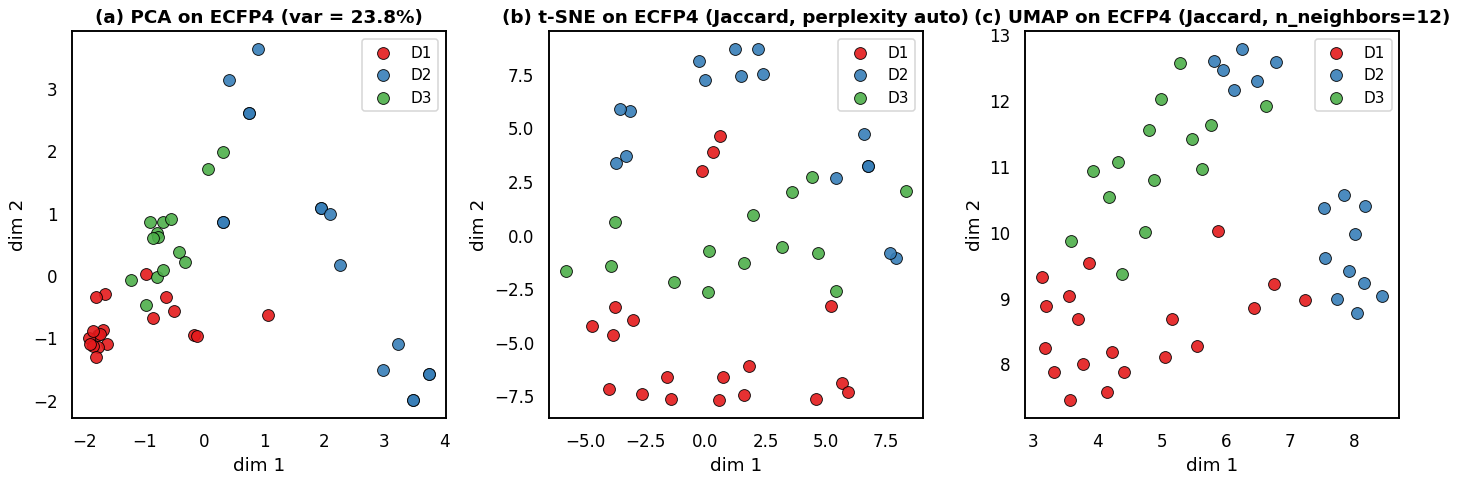

In [28]:
# Visual comparison: same data, three projection methods.
src_colors = {"D1": "#E41A1C", "D2": "#377EB8", "D3": "#4DAF4A"}

fig, axes = plt.subplots(1, 3, figsize=(13, 4.6))
for ax, Z, title in zip(
    axes,
    [Z_pca_ecfp, Z_tsne_ecfp, Z_umap_ecfp],
    [f"(a) PCA on ECFP4 (var = {evr_ecfp.sum():.1%})",
     "(b) t-SNE on ECFP4 (Jaccard, perplexity auto)",
     f"(c) UMAP on ECFP4 (Jaccard, n_neighbors={N_NEIGHBORS})"],
):
    for src, c in src_colors.items():
        m = (all_df["source"] == src).values
        ax.scatter(Z[m, 0], Z[m, 1], s=60, c=c, edgecolor="black",
                   linewidth=0.6, label=src, alpha=0.9)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("dim 1"); ax.set_ylabel("dim 2")
    ax.legend(fontsize=10, frameon=True)
plt.tight_layout()
plt.show()


> **Figure. Two-dimensional projections of the combined chemical space (Datasets 1–3; ECFP4).** All compounds from the three datasets are embedded from their ECFP4 fingerprints with three dimensionality-reduction methods: **(a)** PCA (linear; the fraction of total variance captured by the two components is given in the panel), **(b)** t-SNE (Jaccard distance, perplexity chosen automatically) and **(c)** UMAP (Jaccard distance; the number of neighbours is given in the panel). Each point is one compound, coloured by source dataset (D1, D2, D3). The three methods are shown side by side because each preserves a different aspect of the high-dimensional structure (global variance for PCA; local neighbourhoods for t-SNE/UMAP).

## 14. Chemical-space network across all datasets

For the final visualisation we combine:

1.  **One UMAP embedding** of all compounds from D1 + D2 + D3, so that
    every node has a fixed 2-D position that is comparable across
    panels.
2.  **One panel per fingerprint** (MACCS, ECFP4).  Each panel uses the
    *same* UMAP layout but draws edges based on its own pairwise
    Tanimoto matrix.  This makes the visual comparison between
    fingerprints honest — only the connectivity differs between
    panels, not the node positions.
3.  **Edges are drawn for compound pairs with Tanimoto >= threshold**
    (default 0.4 for ECFP4, 0.65 for MACCS — different thresholds
    because the two fingerprints have very different value ranges).
4.  **Edge colour encodes similarity** on a white -> black gradient
    (`Greys` colormap): pairs with low Tanimoto fade into the
    background, pairs with high Tanimoto are drawn in solid black.
5.  **Edge width** is also scaled to similarity for additional
    emphasis.

### Why a threshold?

Without one, every pair contributes an edge — that's
`n*(n-1)/2 = 49*48/2 = 1176` edges in our case, which produces an
illegible black square.  Setting a sensible threshold is the standard
practice for compound-similarity networks (see e.g. Maggiora 2014;
Yongye et al. 2012).  The thresholds chosen here are *defaults* and
can be tuned via the `tanimoto_thresholds` argument.

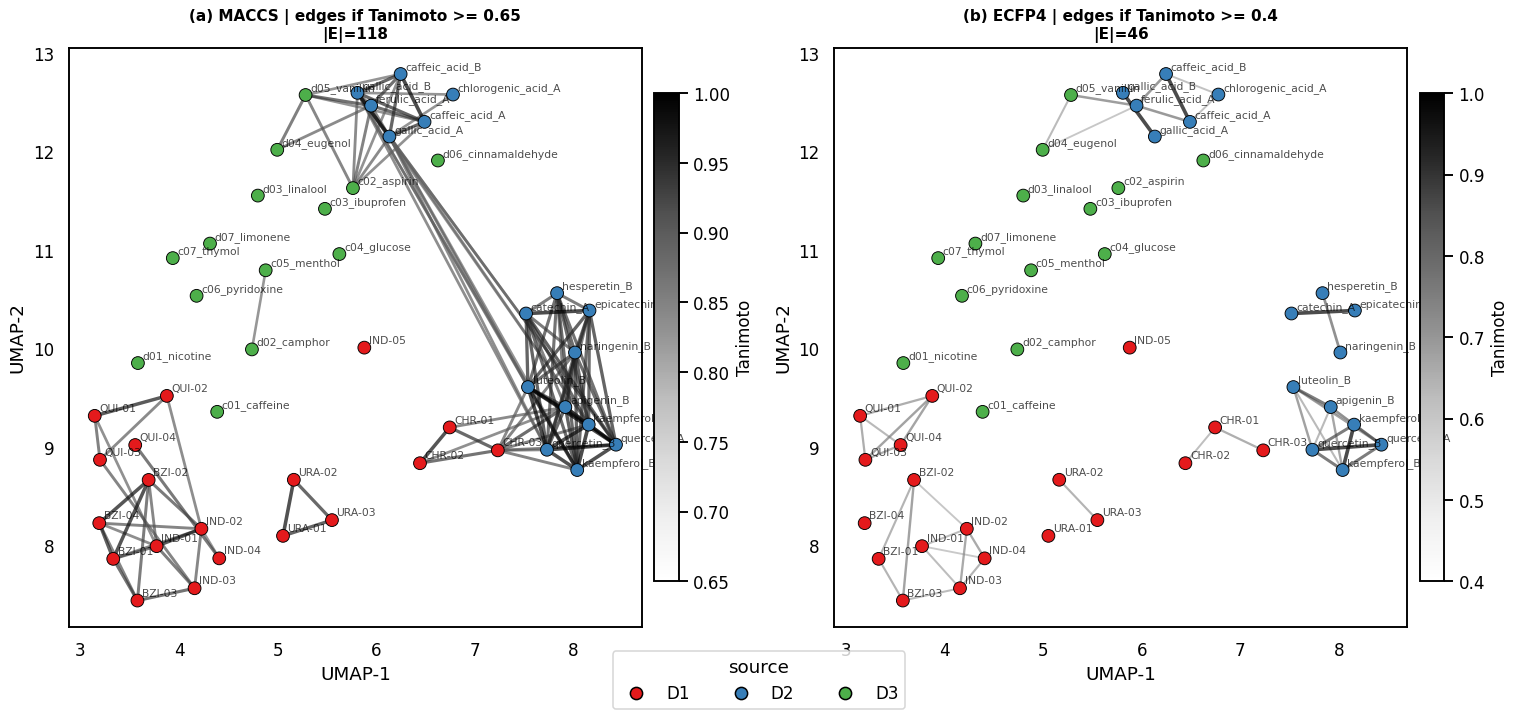

In [29]:
import networkx as nx
from matplotlib.lines import Line2D
from matplotlib import colormaps

def chemical_space_network(
    df,
    embedding,
    tanimoto_thresholds=None,
    fingerprints=("MACCS", "ECFP4"),
    node_color_by="source",
    title="Chemical-space network",
    figsize=None,
):
    """Multi-panel chemical-space network.

    Parameters
    ----------
    df : DataFrame with columns at minimum ['compound_id', node_color_by]
         and pre-computed 'maccs_np' / 'ecfp4_np' fingerprint arrays.
    embedding : (n, 2) ndarray of 2-D coordinates for every row of df.
    tanimoto_thresholds : dict {'MACCS': float, 'ECFP4': float}.
                          Edges with similarity >= threshold are drawn.
    fingerprints : tuple of fingerprint labels (one panel per label).
    node_color_by : str, dataframe column used to colour the nodes.
    """
    if tanimoto_thresholds is None:
        tanimoto_thresholds = {"MACCS": 0.65, "ECFP4": 0.40}

    if figsize is None:
        figsize = (7 * len(fingerprints), 6.5)

    fig, axes = plt.subplots(1, len(fingerprints), figsize=figsize,
                             squeeze=False)
    axes = axes[0]

    # Build node colours
    levels = list(dict.fromkeys(df[node_color_by]))   # order-preserving unique
    palette = sns.color_palette("Set1", n_colors=len(levels))
    color_map = dict(zip(levels, palette))
    node_colors = df[node_color_by].map(color_map).values

    grey_cmap = colormaps["Greys"]  # white = 0.0, black = 1.0

    for pi, (ax, fp_kind) in enumerate(zip(axes, fingerprints)):
        X = get_matrix(df, fp_kind)
        S = pairwise_tanimoto_matrix(X, X)
        thr = tanimoto_thresholds[fp_kind]

        # --- Build graph just to collect edges with weight = Tanimoto ---
        G = nx.Graph()
        G.add_nodes_from(range(len(df)))
        for i in range(len(df)):
            for j in range(i + 1, len(df)):
                if S[i, j] >= thr:
                    G.add_edge(i, j, weight=float(S[i, j]))

        # --- Draw edges first (under the nodes) ---
        edges_sorted = sorted(G.edges(data=True), key=lambda e: e[2]["weight"])
        for i, j, d in edges_sorted:
            s = d["weight"]
            ax.plot([embedding[i, 0], embedding[j, 0]],
                    [embedding[i, 1], embedding[j, 1]],
                    color=grey_cmap(s), lw=0.4 + 2.0 * s,
                    alpha=0.7, zorder=1)

        # --- Draw nodes ---
        ax.scatter(embedding[:, 0], embedding[:, 1],
                   c=node_colors, s=70, edgecolor="black",
                   linewidth=0.6, zorder=3)

        # --- Optional labels (only show every other one for readability) ---
        for k, cid in enumerate(df["compound_id"].values):
            ax.annotate(cid, (embedding[k, 0], embedding[k, 1]),
                        fontsize=7, alpha=0.7,
                        xytext=(3, 3), textcoords="offset points",
                        zorder=4)

        ax.set_title(f"({chr(97+pi)}) {fp_kind} | edges if Tanimoto >= {thr}\n"
                     f"|E|={G.number_of_edges()}", fontsize=10)
        ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
        ax.grid(False)

        # Edge colour bar
        sm = plt.cm.ScalarMappable(cmap=grey_cmap,
                                   norm=plt.Normalize(vmin=thr, vmax=1.0))
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, fraction=0.04, pad=0.02)
        cbar.set_label("Tanimoto", fontsize=11)

    # Shared legend for node colours
    handles = [Line2D([0], [0], marker="o", linestyle="",
                      markerfacecolor=color_map[g], markeredgecolor="black",
                      markersize=8, label=str(g)) for g in levels]
    fig.legend(handles=handles, title=node_color_by,
               loc="lower center", ncol=min(len(levels), 6),
               bbox_to_anchor=(0.5, -0.02), frameon=True)
    plt.tight_layout()
    plt.show()
    return G

_ = chemical_space_network(
    all_df, Z_umap_ecfp,
    title=("Chemical-space network across D1 / D2 / D3 "
           "(UMAP layout from ECFP4, edges = pairwise Tanimoto)"),
    node_color_by="source",
)


> **Figure. Chemical-space similarity network of all compounds (Datasets 1–3), coloured by source dataset.** Nodes are compounds placed at their shared UMAP coordinates (computed from ECFP4 with the Jaccard metric). Two nodes are connected when their pairwise Tanimoto similarity reaches the panel threshold: **(a)** MACCS, edges where Tanimoto ≥ 0.65; **(b)** ECFP4, edges where Tanimoto ≥ 0.40. Edge shade and width encode the Tanimoto value (darker/thicker = more similar; see colour bar), and *|E|* is the number of edges drawn. Node colour denotes the source dataset (shared legend). Contrasting the two fingerprints shows how the molecular representation changes which compounds are judged to be neighbours.

### Same layout, coloured by group label

Switching the node colour from *dataset source* to *group label* (the
scaffold for D1, the procedence for D2 / D3) reveals whether the
intra-group structural homogeneity is visible in the embedding.

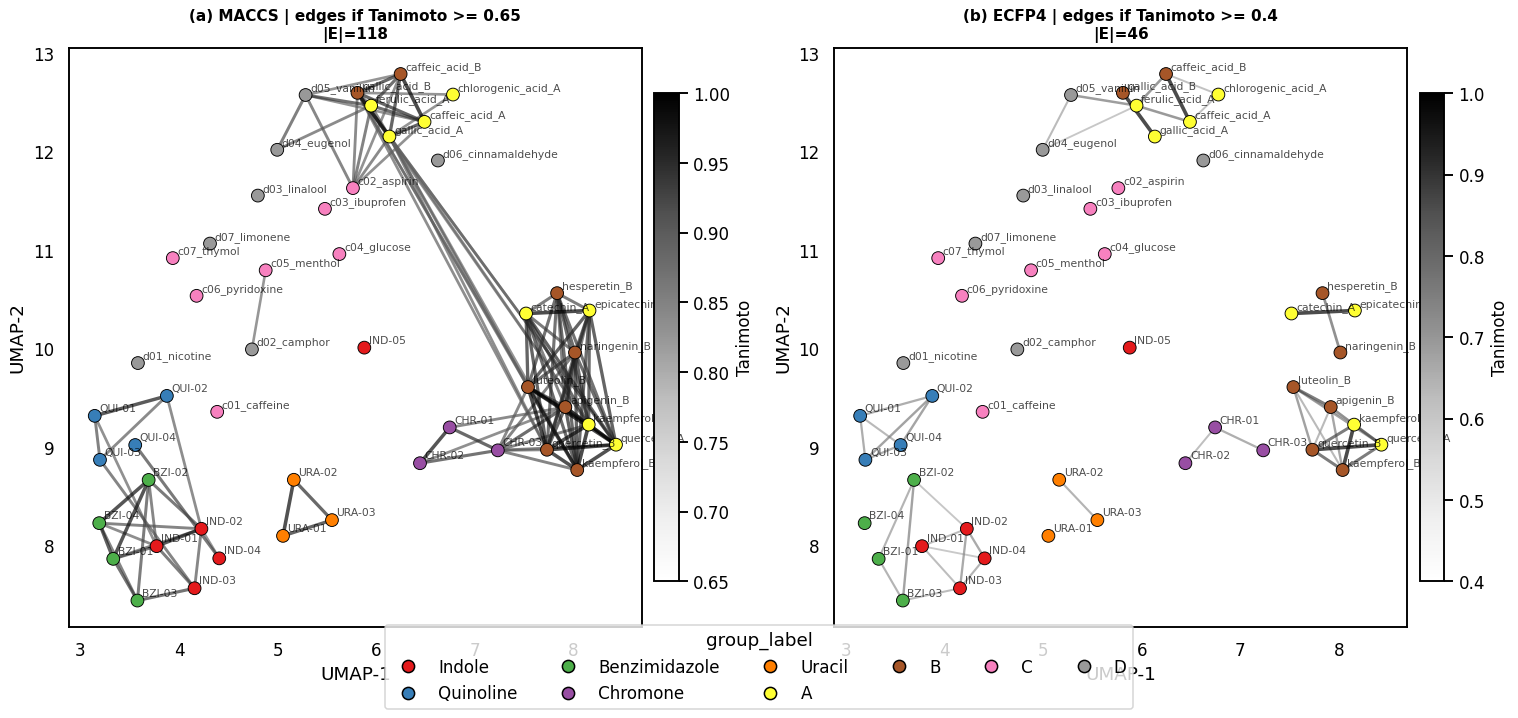

In [30]:
_ = chemical_space_network(
    all_df, Z_umap_ecfp,
    title="Chemical-space network — nodes coloured by group label",
    node_color_by="group_label",
)


> **Figure. Chemical-space similarity network of all compounds (Datasets 1–3), coloured by group label.** Same construction as the previous network figure (UMAP/ECFP4 layout; edges drawn where Tanimoto ≥ the per-panel threshold for **(a)** MACCS and **(b)** ECFP4), but nodes are now coloured by their within-dataset group label — the scaffold series of Dataset 1 and the fraction/mixture procedence of Datasets 2 and 3. This view shows whether the structurally defined groups form cohesive, separable clusters in the combined chemical space.

## 15. Reusable pipeline for any dataset

The function below packages **all** of the extended analysis behind a
single, validated entry point that accepts any user-supplied
dataframe with the minimum schema:

* required columns: `compound_id`, `smiles`
* optional columns: `pIC50`, and any *group* column the user wants to
  inspect (e.g. `scaffold`, `procedence`, `assay`, `series`, ...).

`analyze_dataset(df, group_col=...)` runs the full pipeline and
returns a dictionary with all the computed artefacts so the user
can integrate it into a larger workflow.

In [31]:
def analyze_dataset(
    df,
    group_col=None,
    pic50_col="pIC50",
    fingerprints=("MACCS", "ECFP4"),
    tanimoto_thresholds=None,
    umap_kwargs=None,
    eda=True,
    network=True,
    title="user-supplied dataset",
):
    """Run the full extended analysis on an arbitrary dataframe.

    Parameters
    ----------
    df : pandas.DataFrame
        Must contain at least the columns ``compound_id`` and ``smiles``.
    group_col : str or None
        Column to use as the grouping variable.  If None, scaffold is
        computed and used.
    pic50_col : str
        Column holding the response variable.  Plots are skipped
        gracefully if the column is missing.
    fingerprints : tuple of {"MACCS", "ECFP4"}
        Fingerprint(s) to compute.
    tanimoto_thresholds : dict
        Custom thresholds for the network panels.
    umap_kwargs : dict
        Overrides for the UMAP call.
    eda : bool
        Whether to draw the per-dataset diagnostic figure.
    network : bool
        Whether to draw the chemical-space network.

    Returns
    -------
    dict with keys: "annotated", "matrices", "tanimoto",
                    "embedding", "graph".
    """
    # --- Validate input -----------------------------------------------
    for col in ("compound_id", "smiles"):
        if col not in df.columns:
            raise ValueError(f"Required column missing: {col!r}")
    df = df.copy()

    # --- Annotate -----------------------------------------------------
    ann = annotate(df)
    ann["maccs_np"] = ann["maccs_fp"].apply(fp_to_numpy)
    ann["ecfp4_np"] = ann["ecfp4_fp"].apply(fp_to_numpy)

    # --- Pick or derive the grouping variable -------------------------
    if group_col is None:
        group_col = "scaffold"
    elif group_col not in ann.columns:
        raise ValueError(
            f"group_col {group_col!r} not in dataframe and not auto-derivable")

    # Colour the network by a readable scaffold label (never the raw SMILES).
    net_color_col = group_col
    if group_col == "scaffold":
        ann["scaffold_label"] = scaffold_label_series(ann)
        net_color_col = "scaffold_label"

    # --- Fingerprint matrices and Tanimoto matrices -------------------
    matrices, tanimoto = {}, {}
    for fp in fingerprints:
        X = get_matrix(ann, fp)
        matrices[fp] = X
        tanimoto[fp] = pairwise_tanimoto_matrix(X, X)

    # --- EDA ---------------------------------------------------------
    if eda:
        # Choose the EDA function according to whether the grouping
        # variable is named 'scaffold' (use the D1-style plot) or not
        # (use the D2/D3-style plot).
        if group_col == "scaffold":
            for fp in fingerprints:
                eda_dataset1(ann, fp_kind=fp)
        else:
            for fp in fingerprints:
                eda_procedence_dataset(ann.rename(columns={group_col: "procedence"}),
                                       fp_kind=fp, title=title)

    # --- UMAP embedding ----------------------------------------------
    kw = dict(n_neighbors=max(2, min(15, len(ann) // 4)),
              min_dist=0.25, metric="jaccard",
              random_state=RANDOM_SEED, n_components=2)
    if umap_kwargs:
        kw.update(umap_kwargs)

    # Use the first fingerprint as the "primary" embedding space.
    primary_fp = fingerprints[0]
    Z = umap.UMAP(**kw).fit_transform(matrices[primary_fp])

    # --- Network -----------------------------------------------------
    G = None
    if network:
        G = chemical_space_network(
            ann, Z,
            tanimoto_thresholds=tanimoto_thresholds,
            fingerprints=fingerprints,
            node_color_by=net_color_col,
            title=f"{title} | chemical-space network ({primary_fp} UMAP layout)",
        )

    return {
        "annotated": ann,
        "matrices":  matrices,
        "tanimoto":  tanimoto,
        "embedding": Z,
        "graph":     G,
    }


### Demonstration: run `analyze_dataset` on each dataset

Each call reruns the entire pipeline (annotation, EDA, embedding, network) on a
single dataset, confirming that the wrapper reproduces the section-by-section
results above. These cells are the most computationally intensive in the notebook.


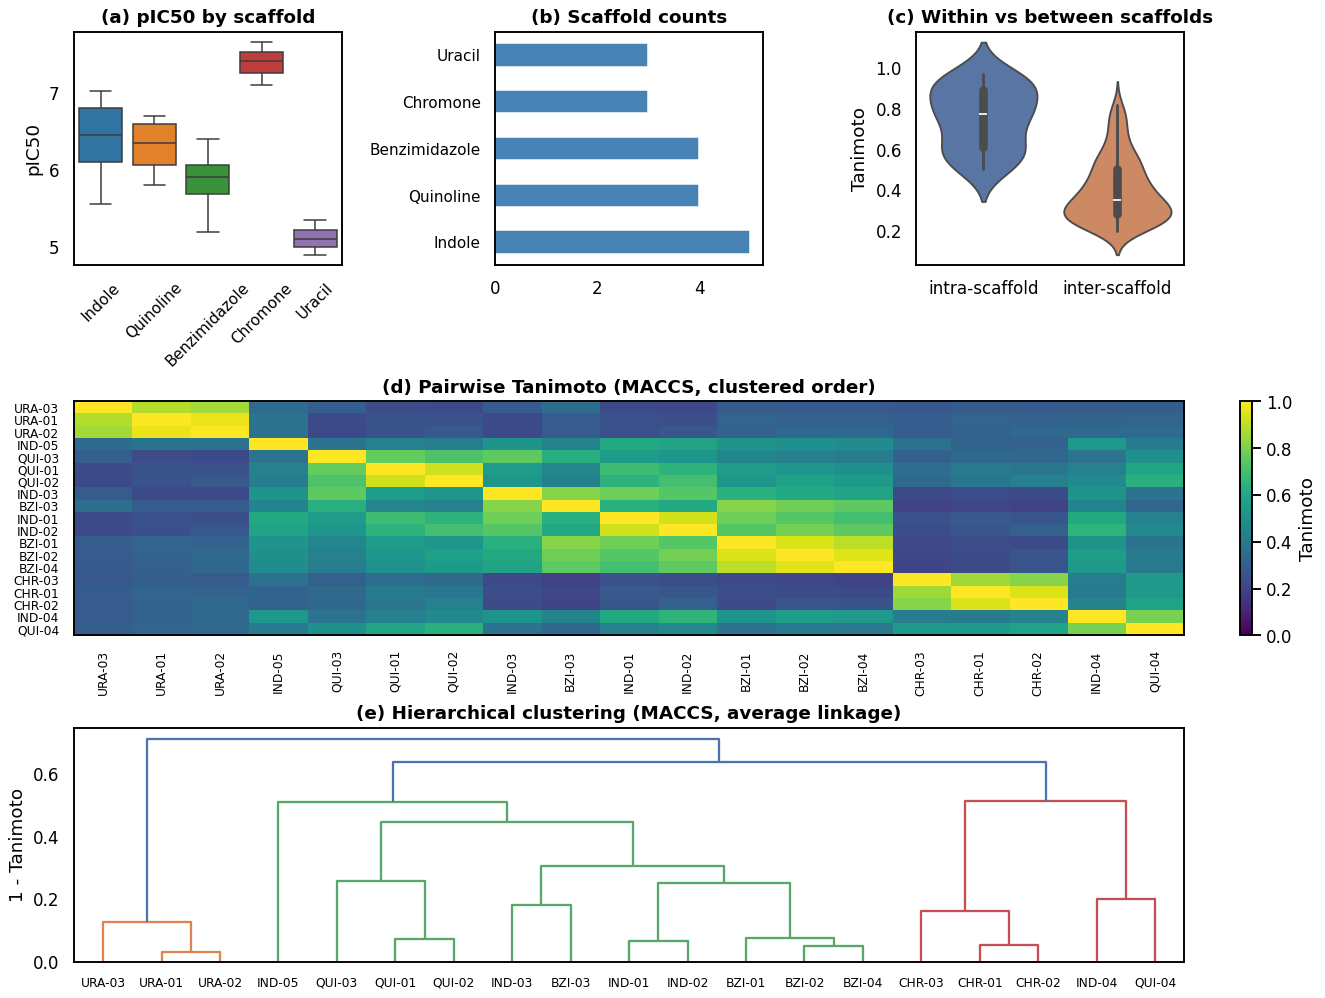

[MACCS] mean intra-scaffold Tanimoto = 0.754
[MACCS] mean inter-scaffold Tanimoto = 0.397


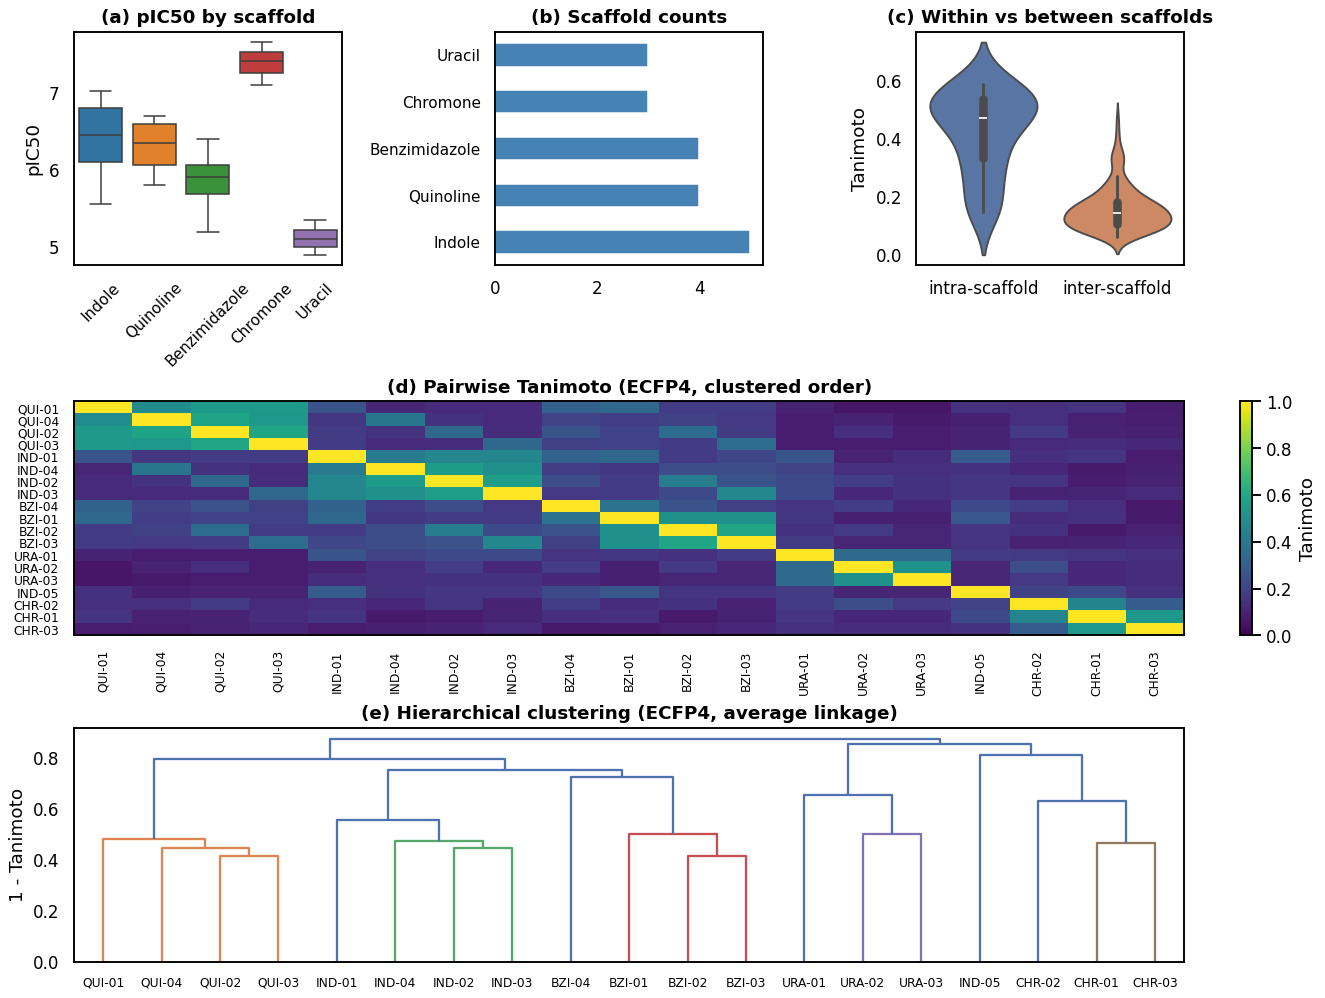

[ECFP4] mean intra-scaffold Tanimoto = 0.423
[ECFP4] mean inter-scaffold Tanimoto = 0.159


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


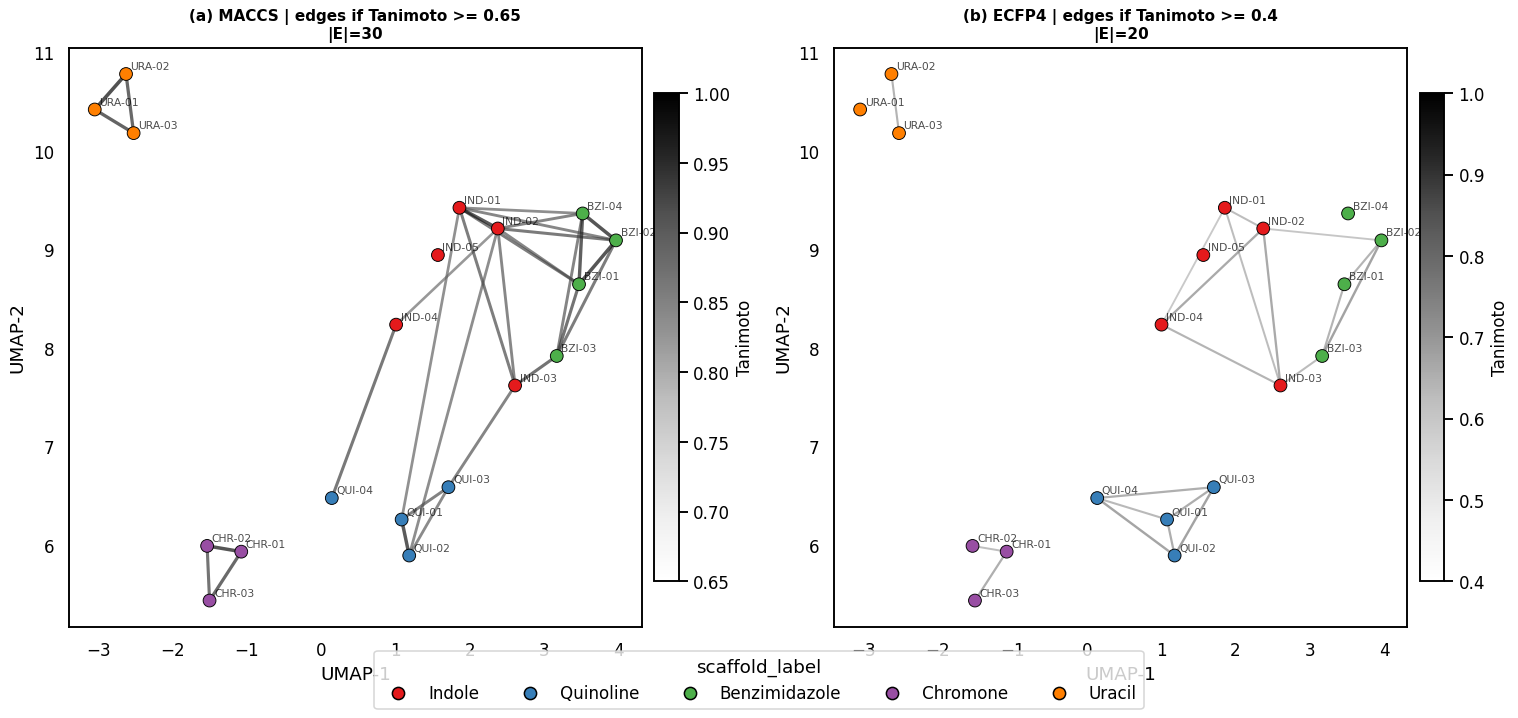

In [32]:
# Dataset 1 — group by scaffold (uses the D1-style EDA plot)
result_d1 = analyze_dataset(
    df1[["compound_id", "smiles", "pIC50"]],
    group_col=None,                          # None -> use Murcko scaffold
    title="Dataset 1 (scaffold series)",
    network=True,
)


> **Figure. General `analyze_dataset` pipeline applied to Dataset 1 (grouped by Murcko scaffold).** Reproduces the Dataset 1 exploratory panels and the chemical-space network through the generic wrapper, for both fingerprints (MACCS and ECFP4). Panel definitions are identical to the Dataset 1 EDA and network figures above.

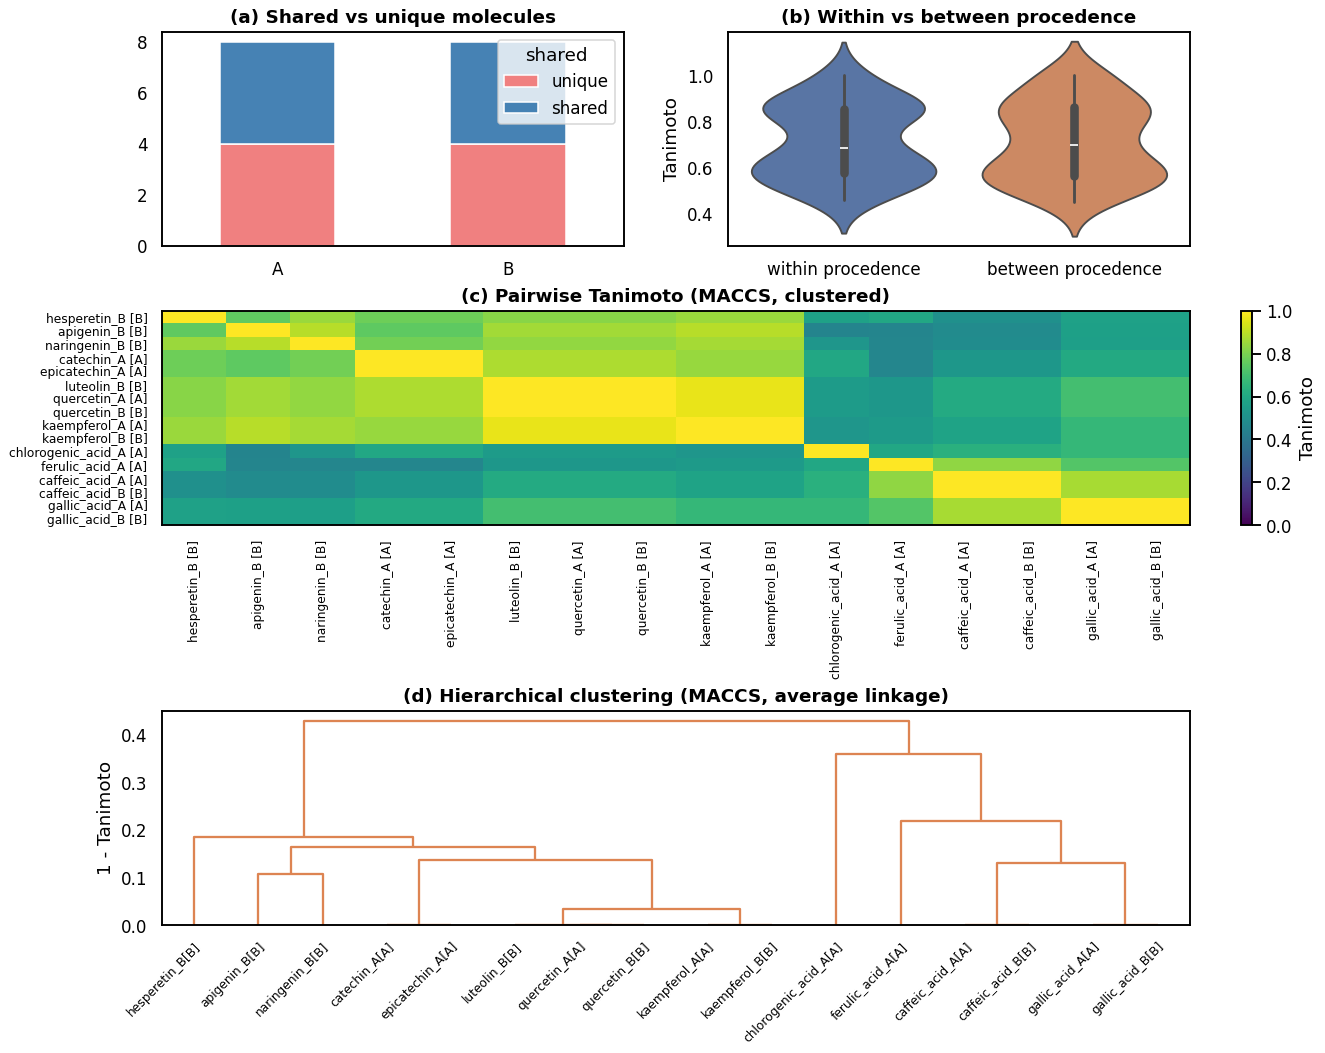

[MACCS] mean within-procedence Tanimoto = 0.711
[MACCS] mean between-procedence Tanimoto = 0.713


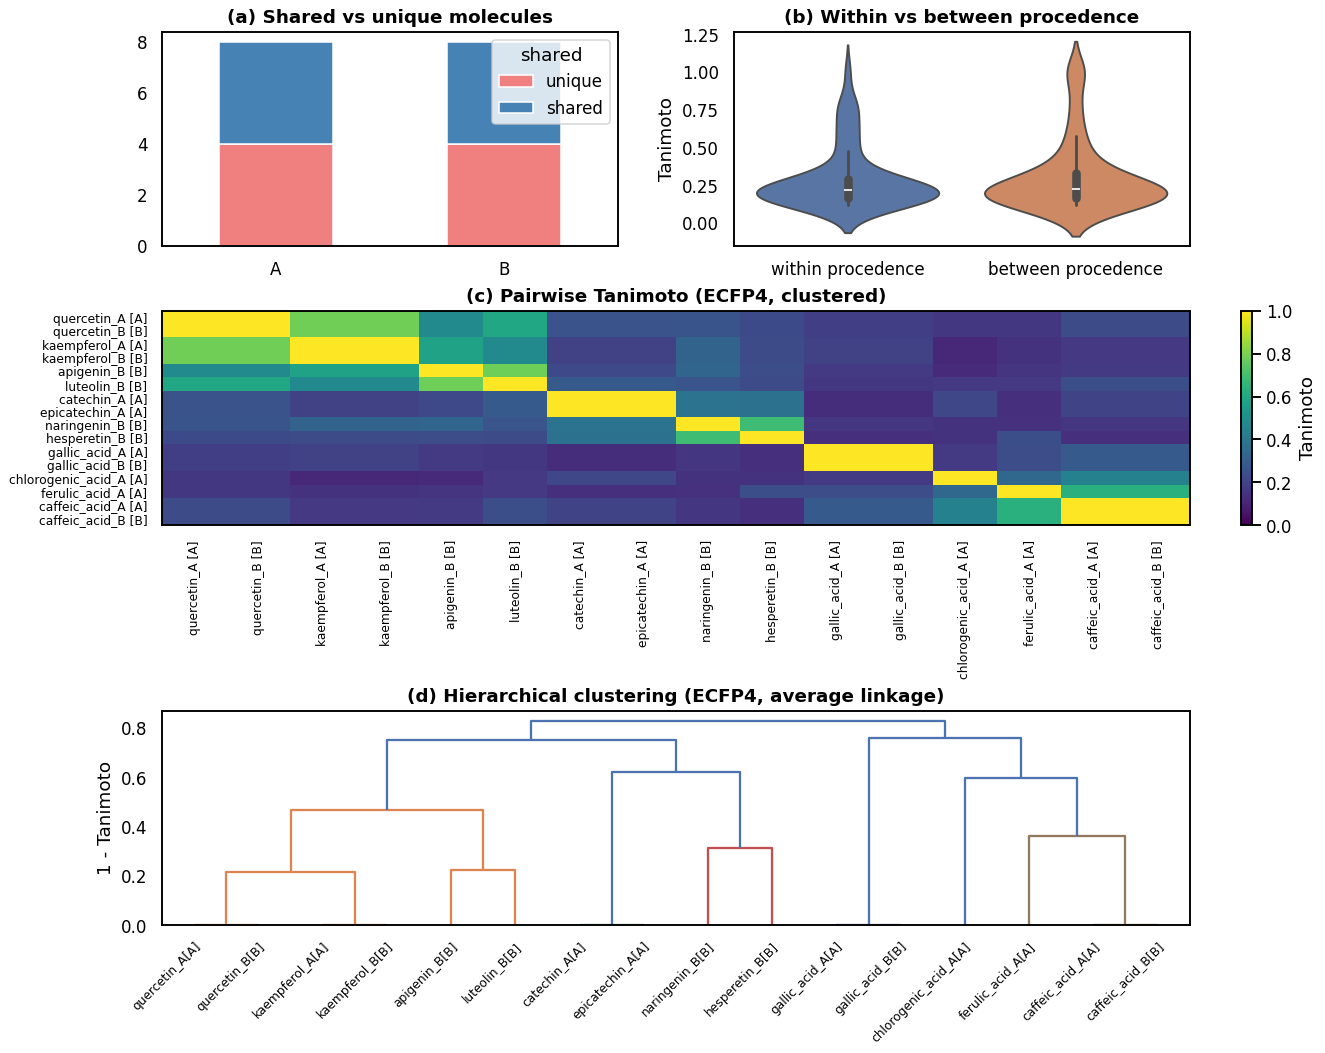

[ECFP4] mean within-procedence Tanimoto = 0.293
[ECFP4] mean between-procedence Tanimoto = 0.307


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


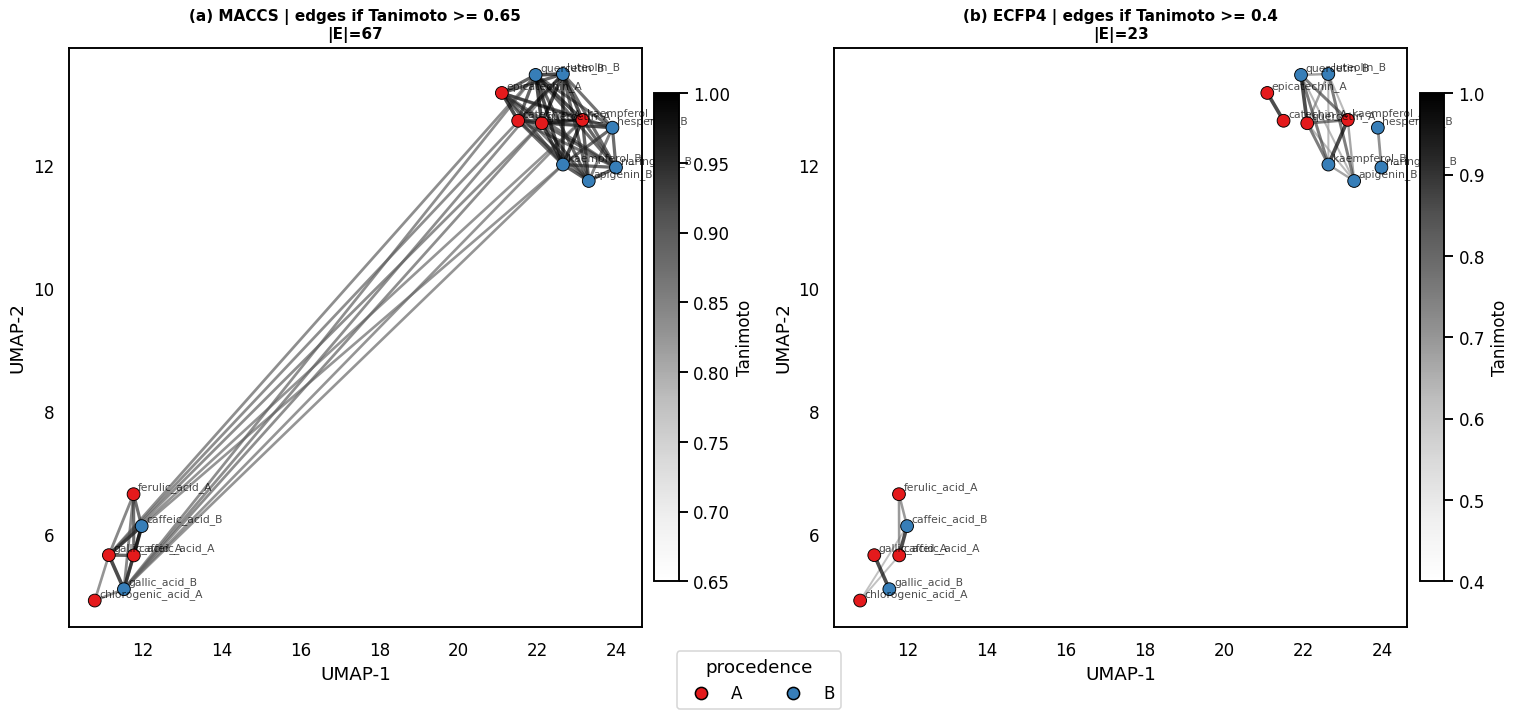

In [33]:
# Dataset 2 — group by procedence (uses the D2/D3-style EDA plot)
result_d2 = analyze_dataset(
    df2[["compound_id", "smiles", "procedence"]],
    group_col="procedence",
    title="Dataset 2 (plant fractions A vs B)",
    network=True,
)

> **Figure. General `analyze_dataset` pipeline applied to Dataset 2 (grouped by fraction/procedence A vs B).** Reproduces the Dataset 2 exploratory panels and the chemical-space network through the generic wrapper, for both fingerprints (MACCS and ECFP4). Panel definitions are identical to the Dataset 2 EDA and network figures above.

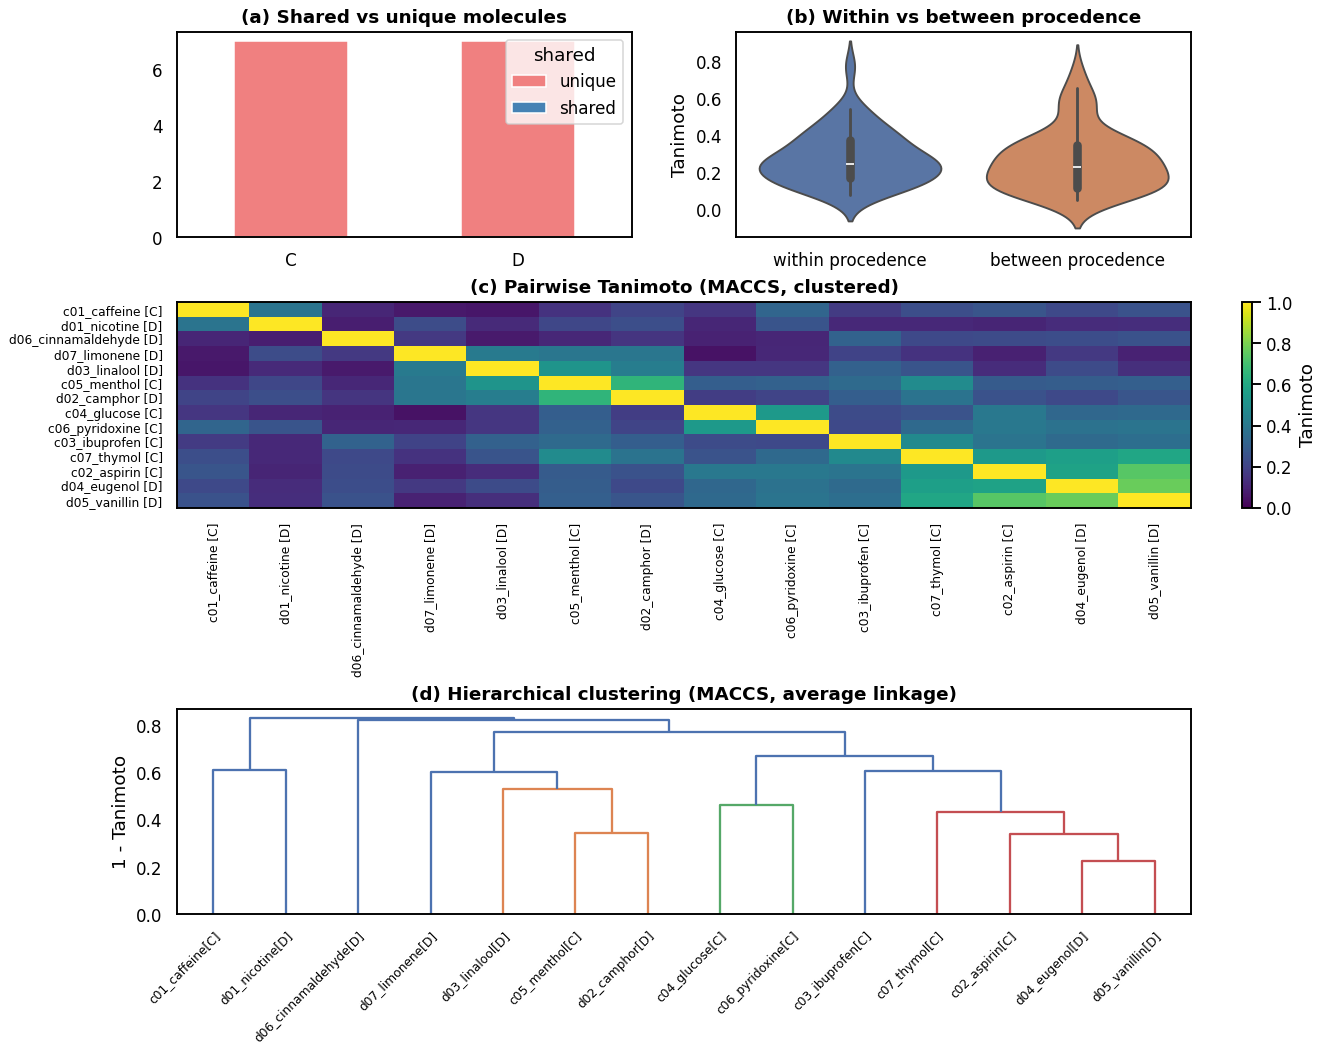

[MACCS] mean within-procedence Tanimoto = 0.280
[MACCS] mean between-procedence Tanimoto = 0.265


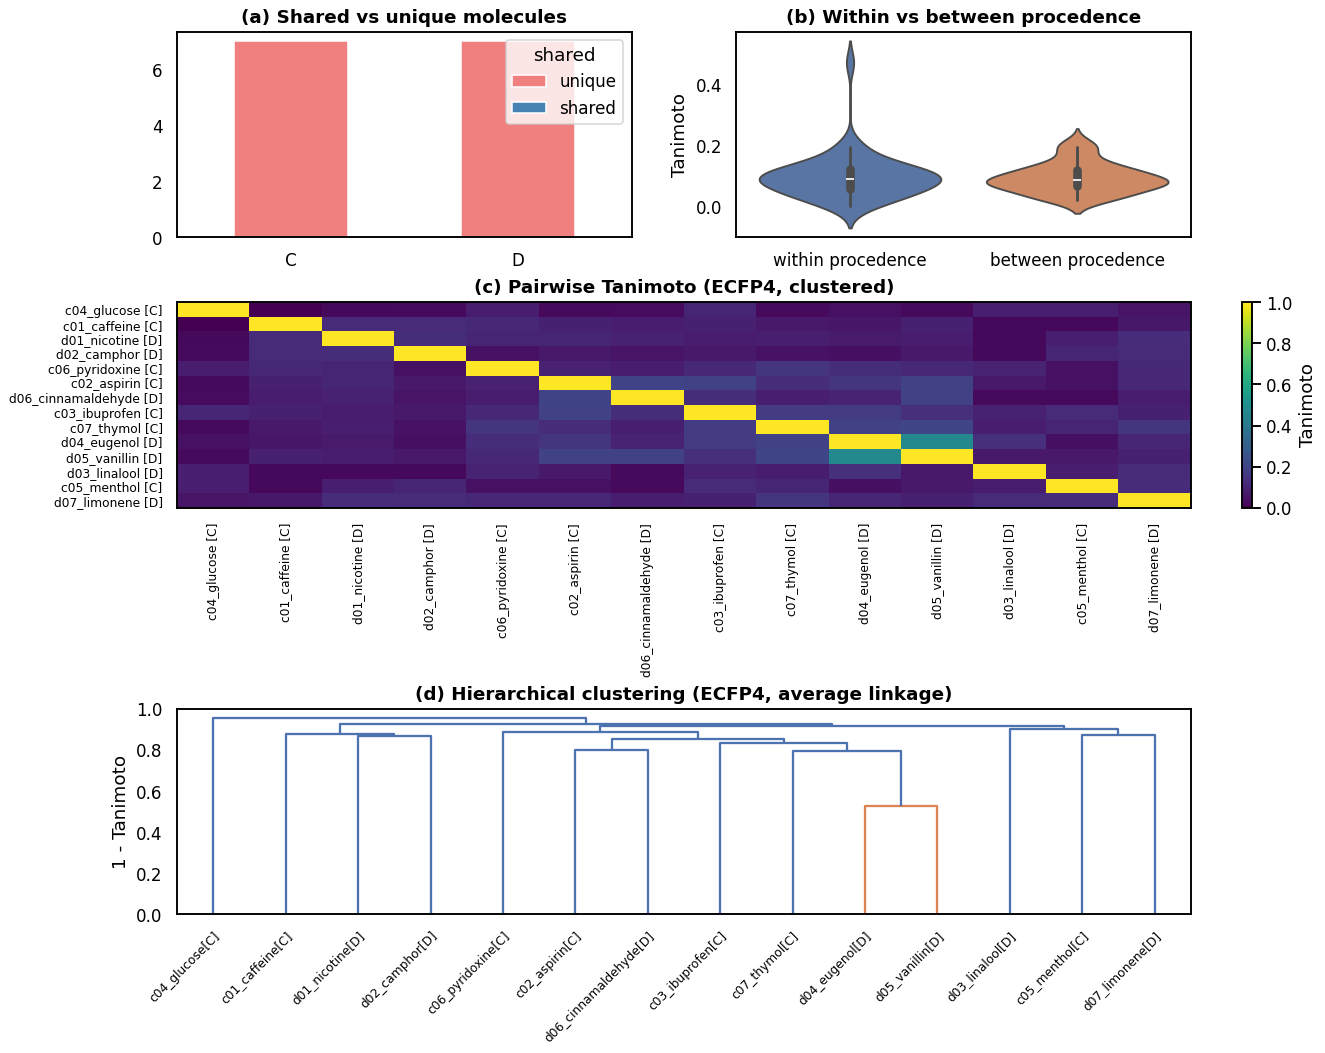

[ECFP4] mean within-procedence Tanimoto = 0.097
[ECFP4] mean between-procedence Tanimoto = 0.093


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


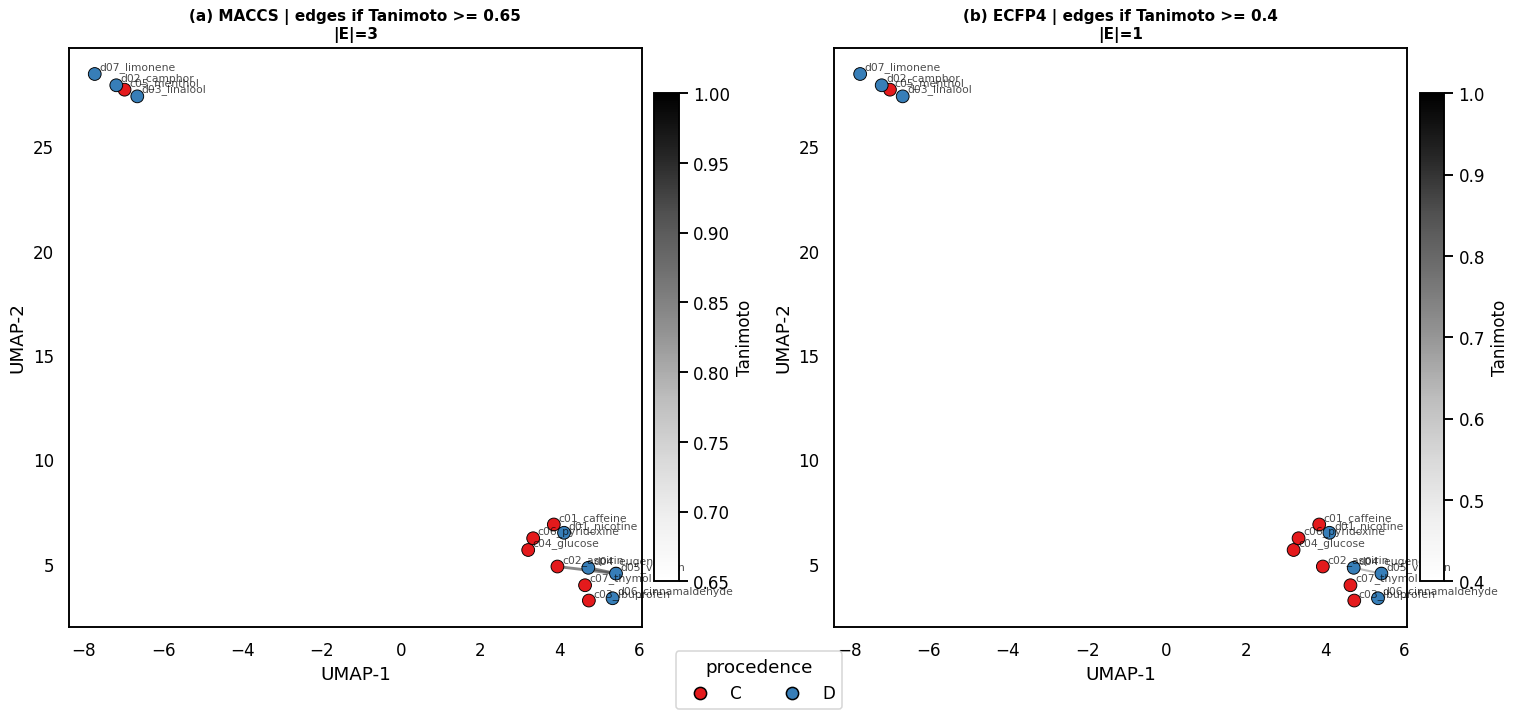

In [34]:
# Dataset 3 — group by procedence
result_d3 = analyze_dataset(
    df3[["compound_id", "smiles", "procedence"]],
    group_col="procedence",
    title="Dataset 3 (mixtures C vs D)",
    network=True,
)

> **Figure. General `analyze_dataset` pipeline applied to Dataset 3 (grouped by mixture/procedence C vs D).** Reproduces the Dataset 3 exploratory panels and the chemical-space network through the generic wrapper, for both fingerprints (MACCS and ECFP4). Panel definitions are identical to the Dataset 3 EDA and network figures above.

## 16. Methodological wrap-up

What we added on top of the original similarity workflow:

1. **Per-dataset EDA** — seven-panel diagnostic figures targeted at
   the question each dataset was designed to answer.
2. **Honest comparison of dimensionality-reduction methods** — PCA,
   t-SNE and UMAP side-by-side, with UMAP+Jaccard chosen for the
   final embedding because it natively handles binary fingerprints.
3. **Chemical-space network** — fixed-layout, multi-panel, edges
   coloured on a white-to-black gradient that directly encodes the
   pairwise Tanimoto similarity, with edge presence gated by a
   per-fingerprint threshold to keep the figure legible.
4. **Reusable wrapper `analyze_dataset(df, group_col=...)`** that
   accepts any minimally-conformant compound dataframe and reproduces
   the entire pipeline.

### When to override defaults

* **`n_neighbors`** (UMAP):  set to ~15% of *n* for small datasets;
  for large datasets (n > 1000) bump to 30-50 to avoid overly local
  embeddings.
* **`min_dist`** (UMAP):  decrease to 0.05 for tight clusters,
  increase to 0.5 for a more even spread.
* **`tanimoto_thresholds`** (network):  set per fingerprint.  As a
  rule of thumb, MACCS values are 0.2-0.4 higher than ECFP4 for the
  *same* pair, so use distinct thresholds for the two panels.
* **`metric`** (UMAP):  keep ``jaccard`` for binary fingerprints;
  switch to ``euclidean`` only if you feed in physico-chemical
  descriptor vectors instead.